## A function that takes the UDAQ VOCs in the Verbose file, selects only the Hawthorne data, sorts by Parameter Code

In [1]:
import os 
import sys 
import re 
import yaml
import inspect 
import numpy as np 
import pandas as pd
import xarray as xr
from collections import defaultdict
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap

from scipy.io import savemat
from collections import OrderedDict

In [4]:
dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'
#define path for Hawthorne data directory
savepath= dirpath + 'Hawthorne_data/'

#UDAQ Files
#Verbose file given by Bart
udaq_voc_filepath = dirpath + 'Hawthorne_data/data/Verbose.csv'

#Mappings for UDAQ species names to variables
mappings_filepath = dirpath + 'Hawthorne_data/mappings/manually_edited/UDAQ_Hawthorne_CRACMM_GEOSCHEM_CB6r5h_mapped_updated_11172025.csv'

In [5]:
#Read UDAQ VOC measurements file
df_data = pd.read_csv(udaq_voc_filepath) 
#Get only the data at Hawthorne
df_udaq_hawthornedates_usos_only = df_data.loc[(df_data['StationSym'] == 'HW')]
#set index to datetimeindex
df_udaq_hawthornedates_usos_only.set_index(['dt'], inplace = True) 
df_udaq_hawthornedates_usos_only.index = pd.to_datetime(df_udaq_hawthornedates_usos_only.index)

#Get only the data during the USOS campaign
df_udaq_hawthornedates_usos_only = df_udaq_hawthornedates_usos_only.sort_index().loc['2024-07-15 00:00:00':'2024-08-18 23:00:00']

#View Parameter code values as only an int (they print with a .0 at the end initially)
df_udaq_hawthornedates_usos_only.Parameter = df_udaq_hawthornedates_usos_only.Parameter.astype(int)
sorted_parameters = sorted(df_udaq_hawthornedates_usos_only.Parameter.unique())

df_pivot_drop_qc = df_udaq_hawthornedates_usos_only.pivot_table(index=df_udaq_hawthornedates_usos_only.index, columns='Parameter', values='Sample Value')
print(df_pivot_drop_qc.columns)
                                                        
#Pivot the data
df_pivot = df_udaq_hawthornedates_usos_only.pivot_table(index=df_udaq_hawthornedates_usos_only.index, columns='Parameter', values='Sample Value', dropna=False)
#Resample to hourly to ensure a continuous time index
new_start_time = pd.Timestamp('2024-07-15 00:00:00')
new_end_time = pd.Timestamp('2024-08-18 23:00:00')
#Create a new datetime index from new_start to the end of existing index with same frequency
new_index = pd.date_range(start=new_start_time, end=new_end_time, freq='1h')
#Reindex the dataframe to include new rows
df_pivot = df_pivot.reindex(new_index)
df_pivot_parameter_sort = df_pivot[sorted(df_pivot.columns)]
df_pivot_parameter_sort = df_pivot_parameter_sort.drop(43102, axis=1)
print(df_pivot_parameter_sort)
# # #make new dataframe with Parameter Code, EPA Species Name, UDAQ_Variable
# # #remove NaNs
# # #Convert DataFrame to MATLAB struct

/tmp/ipykernel_80751/1240020388.py:2: DtypeWarning: Columns (14,22,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df_data = pd.read_csv(udaq_voc_filepath)


Index([43202, 43203, 43204, 43205, 43206, 43212, 43214, 43216, 43217, 43218,
       43220, 43221, 43224, 43226, 43227, 43230, 43231, 43232, 43233, 43235,
       43238, 43242, 43243, 43244, 43245, 43247, 43248, 43249, 43250, 43252,
       43253, 43261, 43262, 43263, 43280, 43284, 43285, 43291, 43502, 43954,
       45109, 45201, 45202, 45203, 45204, 45207, 45208, 45209, 45210, 45211,
       45212, 45213, 45219, 45225],
      dtype='int64', name='Parameter')
Parameter            43141   43202   43203   43204   43205   43206   43212  \
2024-07-15 00:00:00    NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2024-07-15 01:00:00    NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2024-07-15 02:00:00    NaN  5.3078  1.1578  2.7270  0.7728  0.5692  2.3688   
2024-07-15 03:00:00    NaN  5.7297  1.2677  3.5392  1.0170  0.5193  2.8581   
2024-07-15 04:00:00    NaN  5.0654  1.1698  3.5038  1.0126  0.3312  2.8685   
...                    ...     ...     ...     ...     ...     ...     .

In [ ]:
df_mapping_parameters = pd.read_csv(mappings_filepath)
df_mapping_parameters = df_mapping_parameters.drop([0])
#df_mapping_parameters.rename(columns={'Parameter Code':'Parameter'}, inplace=True)

carbon_number = df_mapping_parameters['formula'].str.extract(r'C(\d{1,2})')[0]
carbon_number = carbon_number.fillna(1)
carbon_number = carbon_number.astype(int)

# print(carbon_number)
# print(df_pivot_parameter_sort)

print(df_mapping_parameters.columns)
df_udaq_ppbv = df_pivot_parameter_sort.divide(carbon_number.values, axis=1)

# # Create mapping: {101: 'Temperature', 102: 'Humidity', ...}
param_to_var = df_mapping_parameters.set_index('Parameter Code')['UDAQ_Variable'].to_dict()

# # Rename columns in df_data
df_udaq_vals = df_udaq_ppbv.rename(columns=param_to_var)
df_udaq_vals.columns.name = None

#Get rid of columns that are all NaNs due to data issues
df_udaq_vals = df_udaq_vals.drop(columns = ['nDodecane', 'x2_Methylheptane', 'mDiethylbenzene', 'Styrene'])
#Shift all values by 1 hour to account for the fact that all values are in MST rather than MDT
df_udaq_vals = df_udaq_vals.shift(periods=1)
print(df_udaq_vals)

Index(['Parameter Code', 'EPA Species', 'query_results', 'iupac_name',
       'synonyms', 'cid', 'mw', 'formula', 'inchi', 'inchi_key', 'SMILES',
       'cas_number', 'CompTox Name', 'kOH (cm3/molecule*s)',
       'Vapor Pressure 25C (mmHg)', 'Vapor Pressure 25C (Pa)', 'Cstar',
       'log10Cstar', 'CRACMM Mapping', 'GEOS-Chem Mapping',
       'CB6r5h Mapping - INCORRECT', 'CB6r5h_Mapping_maybe', 'USOS Mapping',
       'UDAQ_Variable'],
      dtype='object')
                      Ethane  Ethylene   Propane  Propylene  Acetylene  \
2024-07-15 00:00:00      NaN       NaN       NaN        NaN        NaN   
2024-07-15 01:00:00      NaN       NaN       NaN        NaN        NaN   
2024-07-15 02:00:00      NaN       NaN       NaN        NaN        NaN   
2024-07-15 03:00:00  2.65390   0.57890  0.909000     0.2576    0.28460   
2024-07-15 04:00:00  2.86485   0.63385  1.179733     0.3390    0.25965   
...                      ...       ...       ...        ...        ...   
2024-08-18 19:00:00

In [7]:
df_udaq_vals.columns.values

for index, item in enumerate(df_udaq_vals.columns.values):
    print(f"Index: {index}, Item: {item}")

Index: 0, Item: Ethane
Index: 1, Item: Ethylene
Index: 2, Item: Propane
Index: 3, Item: Propylene
Index: 4, Item: Acetylene
Index: 5, Item: nButane
Index: 6, Item: Isobutane
Index: 7, Item: trans2Butene
Index: 8, Item: cis2Butene
Index: 9, Item: buta13diene
Index: 10, Item: nPentane
Index: 11, Item: Isopentane
Index: 12, Item: Pent1ene
Index: 13, Item: trans2Pentene
Index: 14, Item: cis2Pentene
Index: 15, Item: x3_Methylpentane
Index: 16, Item: nHexane
Index: 17, Item: nHeptane
Index: 18, Item: nOctane
Index: 19, Item: nNonane
Index: 20, Item: nDecane
Index: 21, Item: Cyclopentane
Index: 22, Item: Isoprene
Index: 23, Item: x22_Dimethylbutane
Index: 24, Item: Hex1ene
Index: 25, Item: x24_Dimethylpentane
Index: 26, Item: Cyclohexane
Index: 27, Item: x3_Methylhexane
Index: 28, Item: x224_Trimethylpentane
Index: 29, Item: x234_Trimethylpentane
Index: 30, Item: x3_Methylheptane
Index: 31, Item: Methylcyclohexane
Index: 32, Item: Methylcyclopentane
Index: 33, Item: x2_Methylhexane
Index: 34,

/tmp/ipykernel_80751/3653182155.py:17: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize = (30,10))


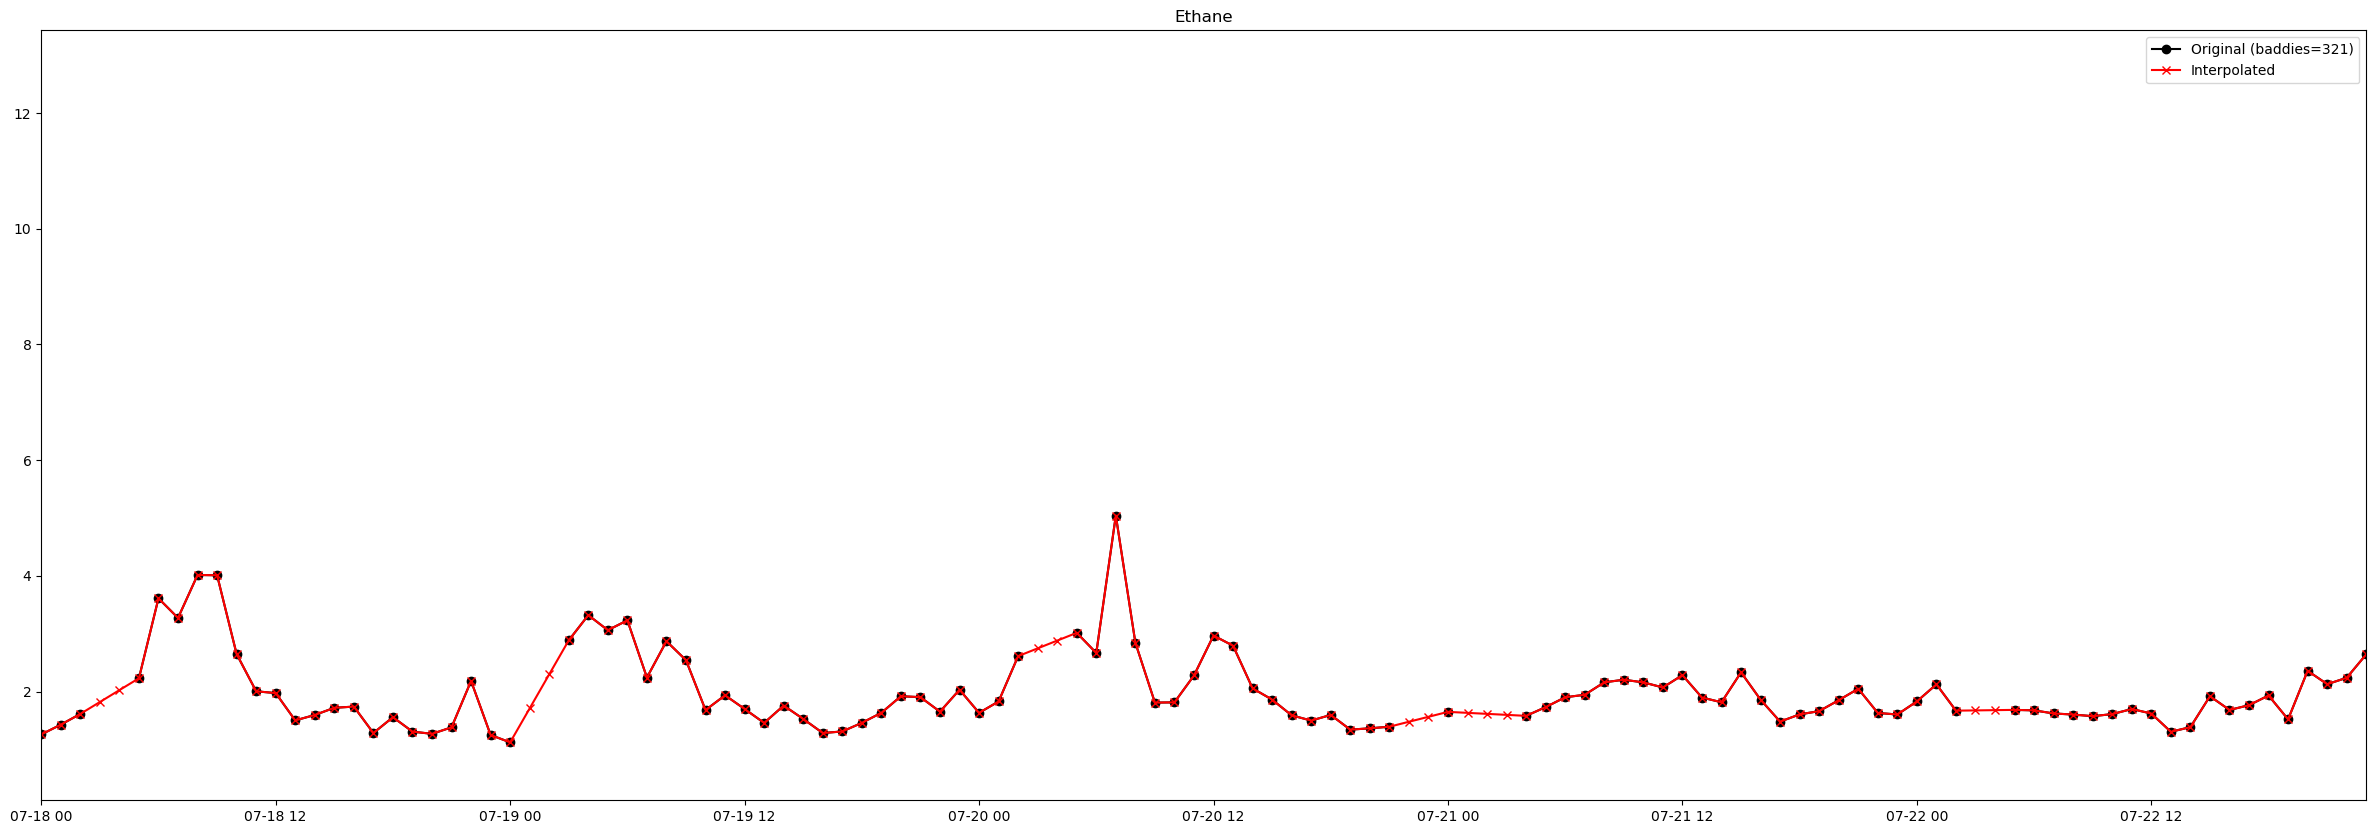

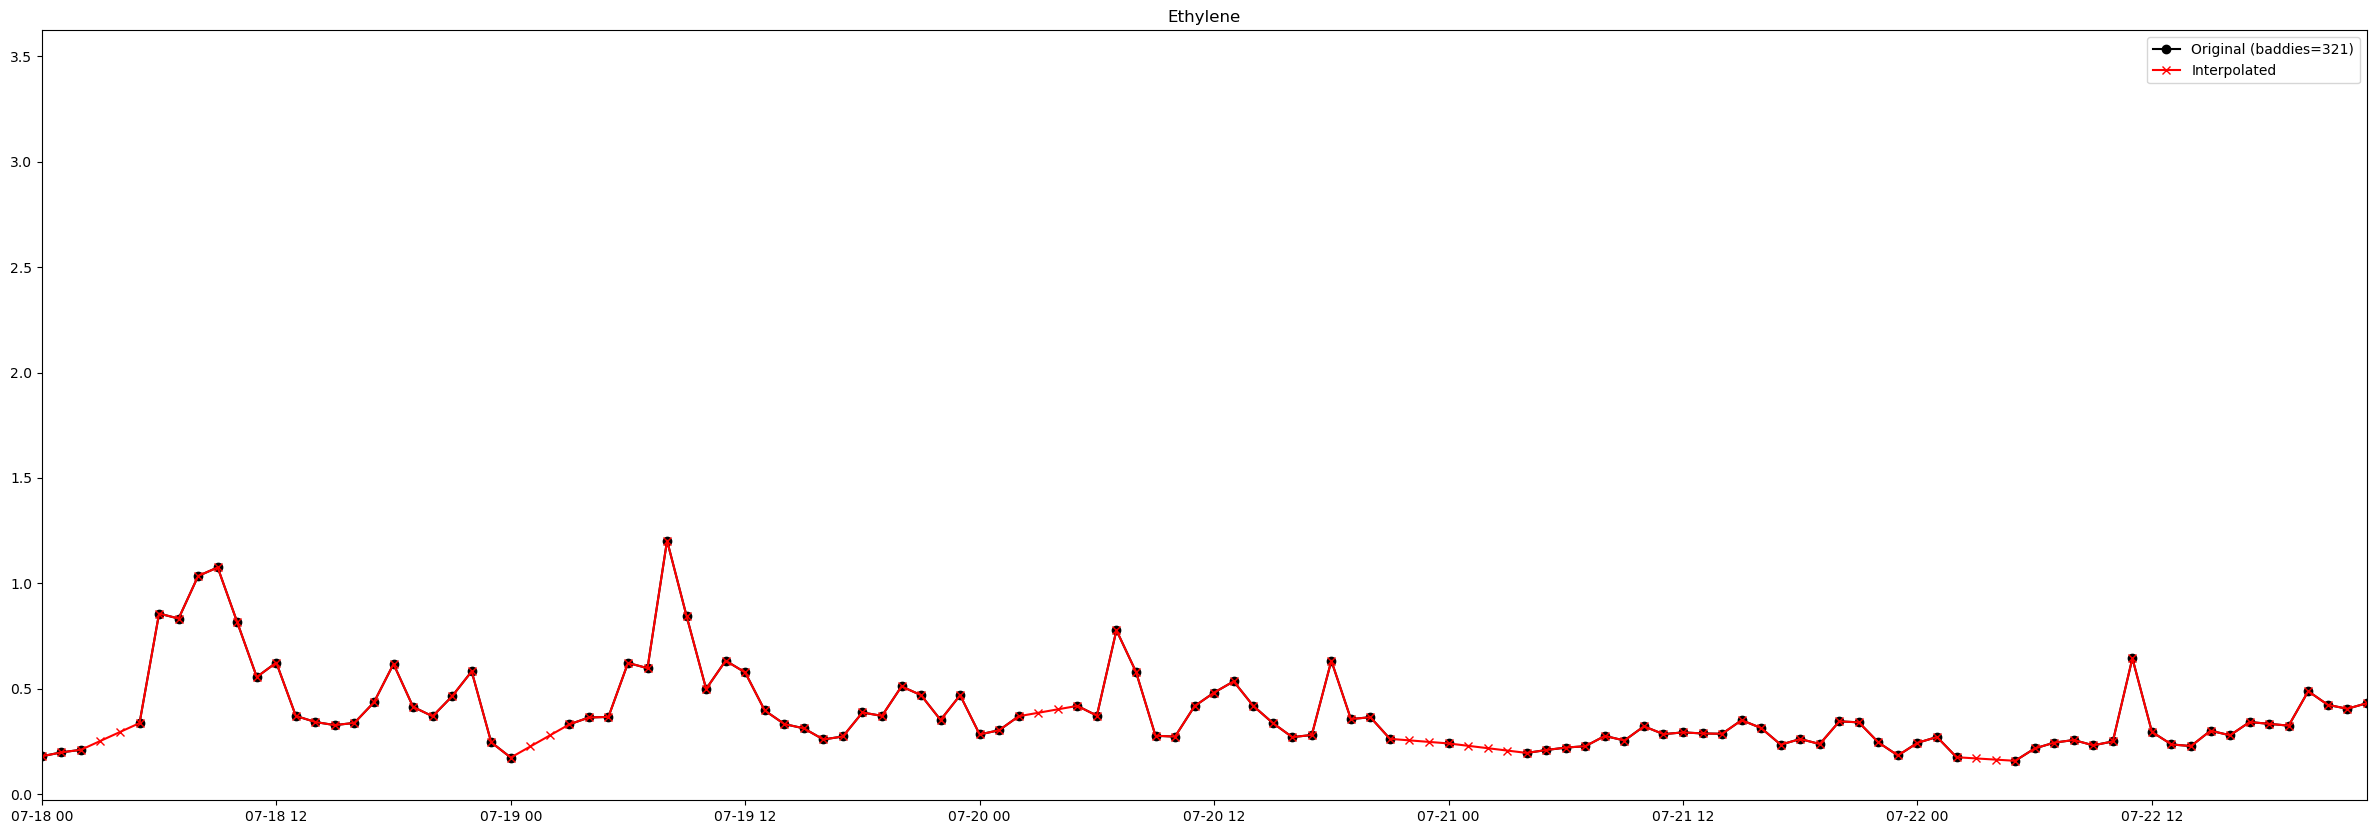

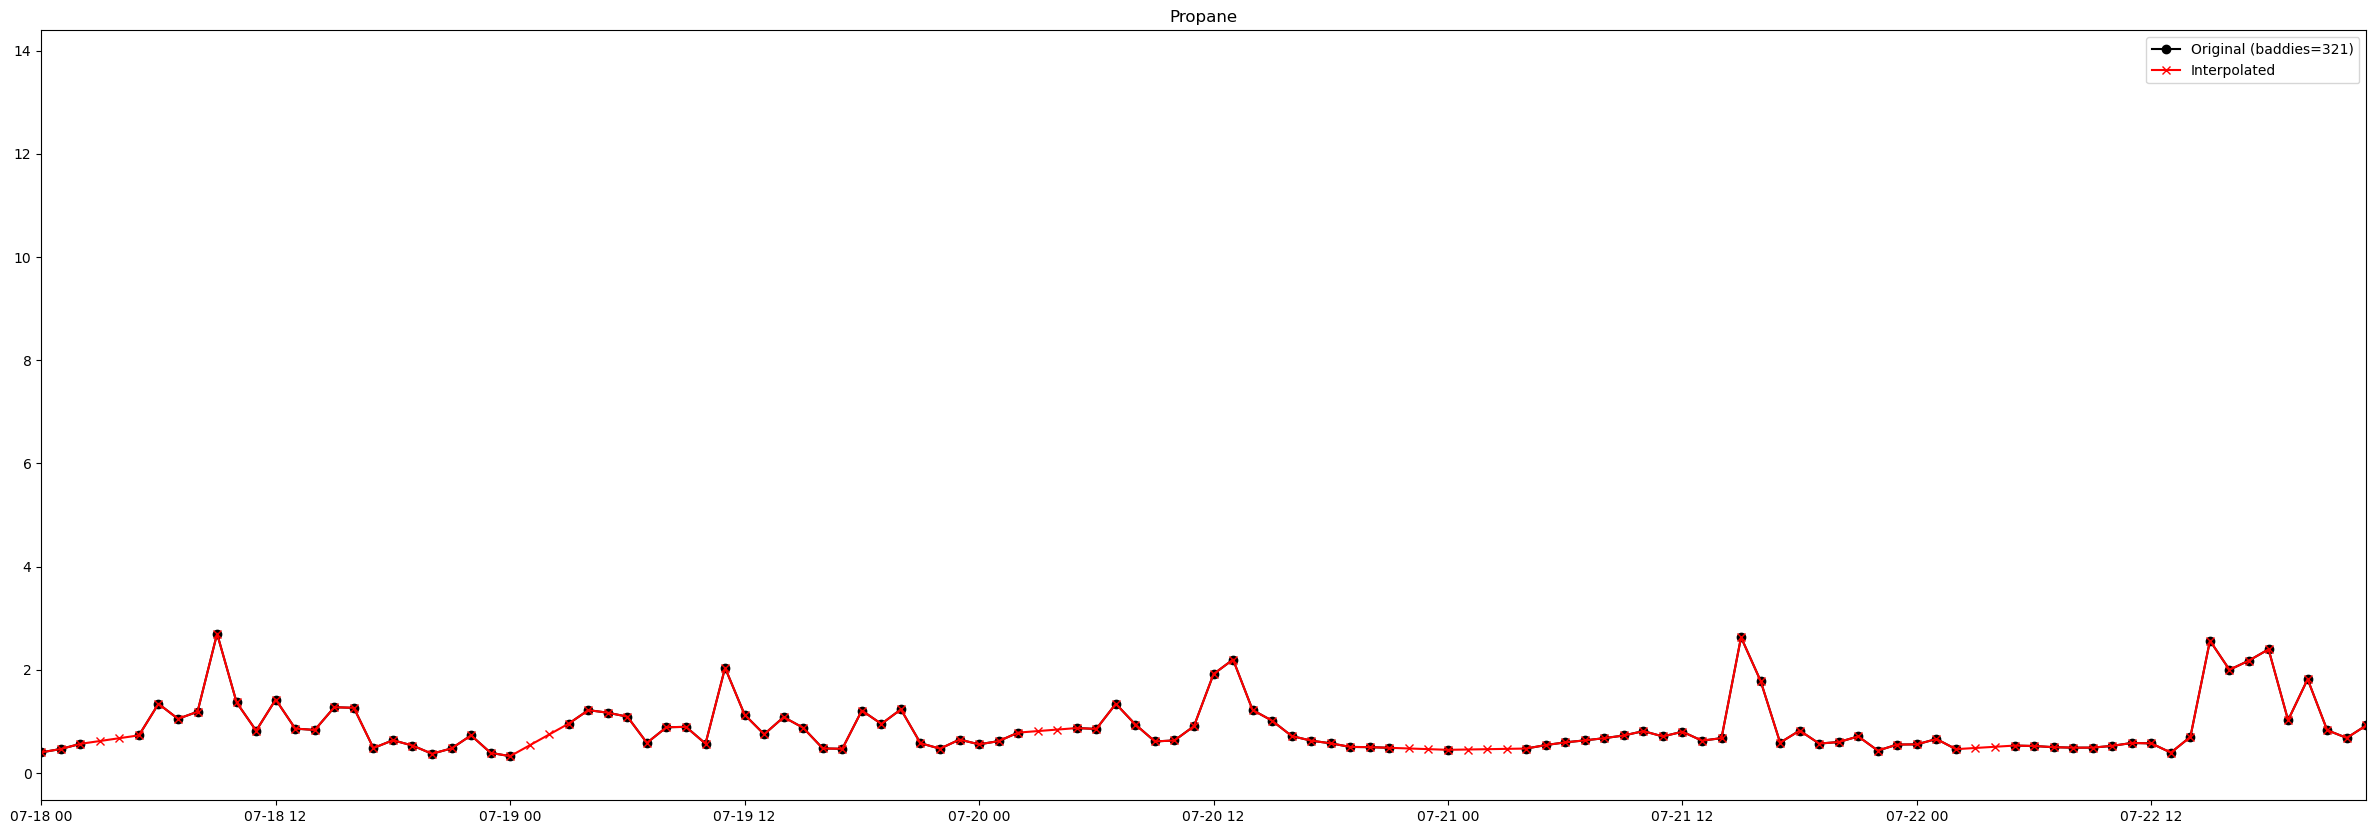

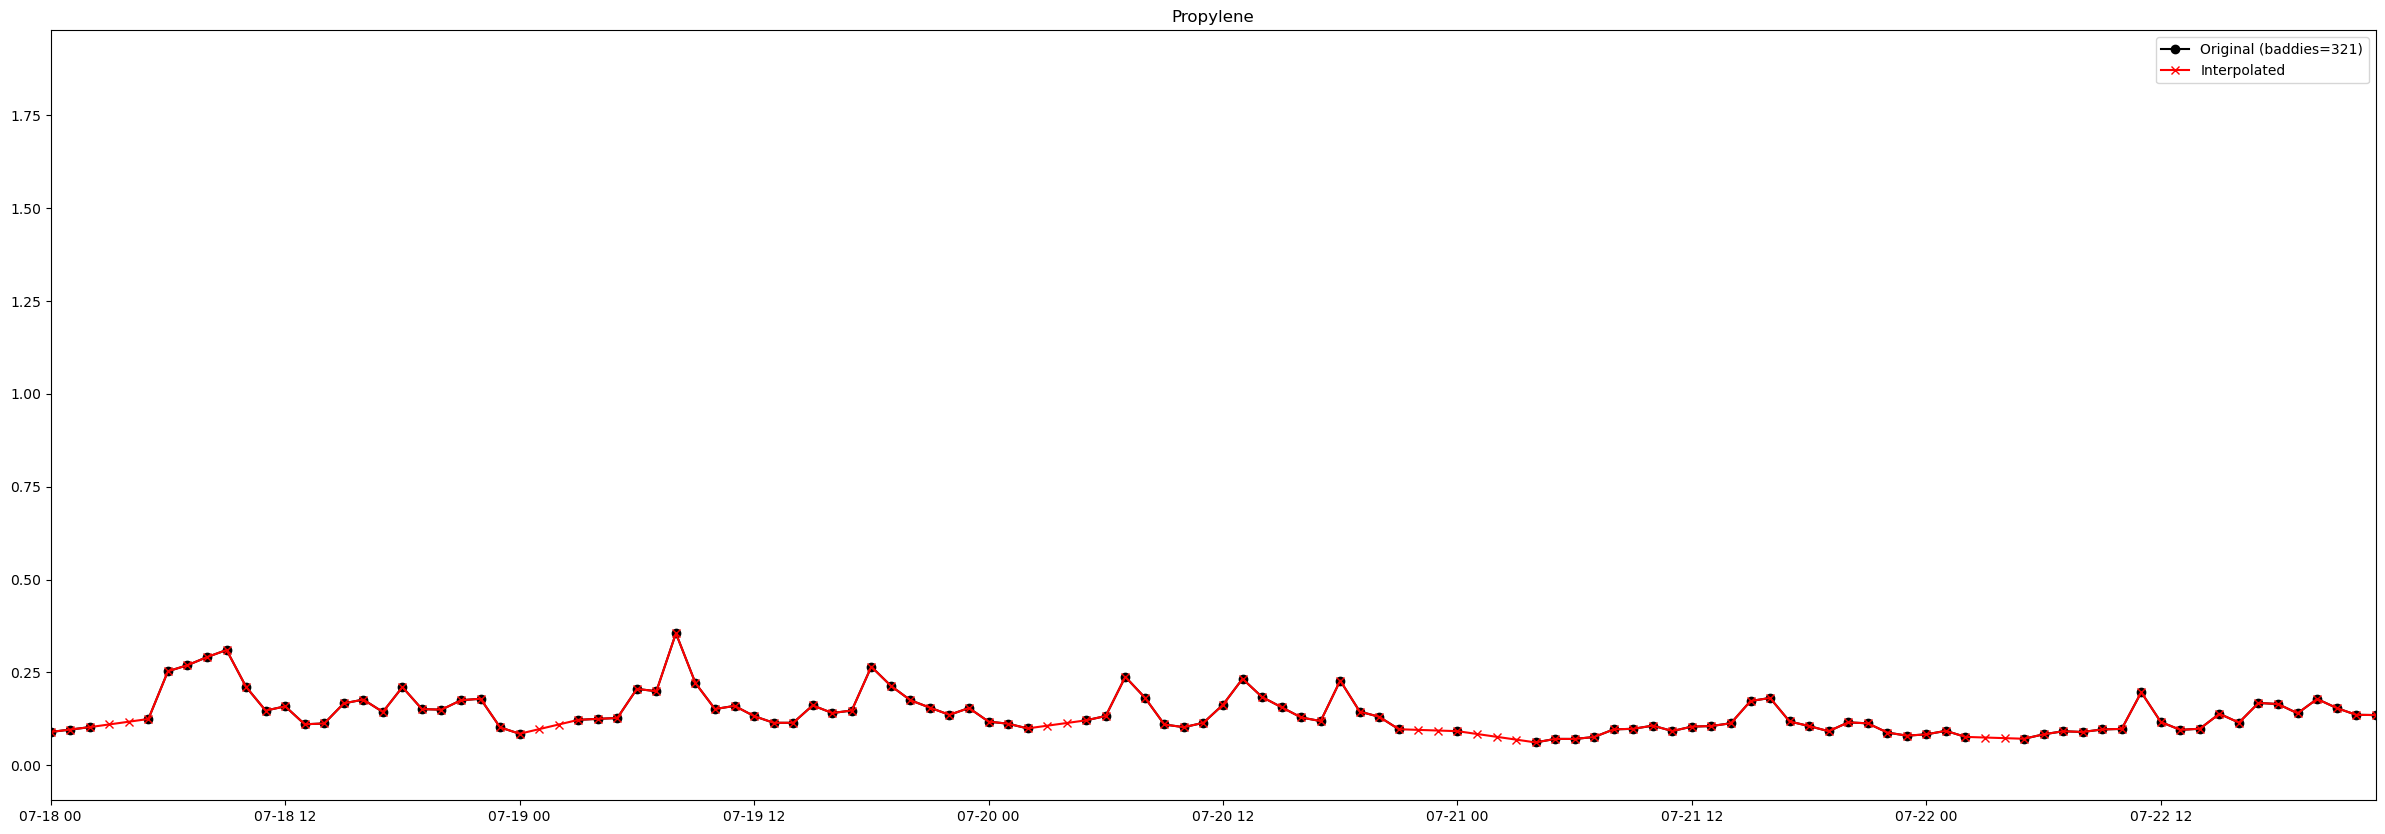

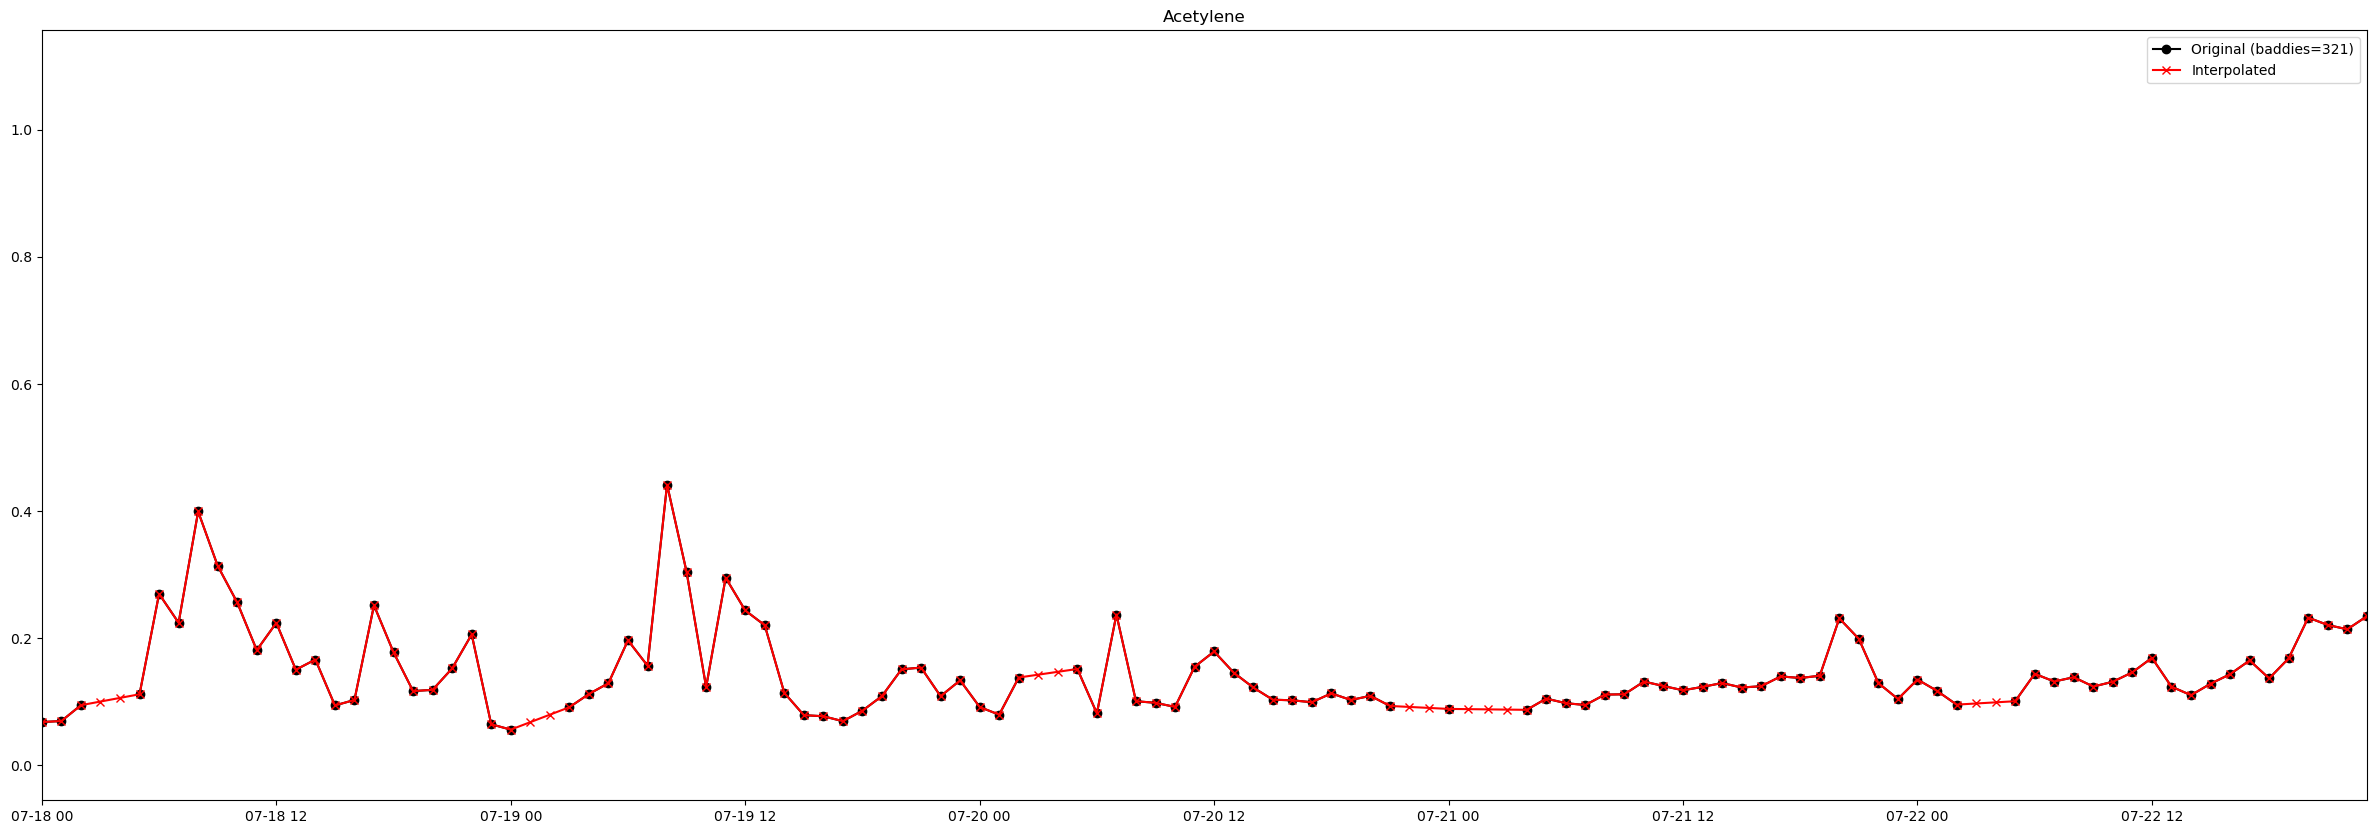

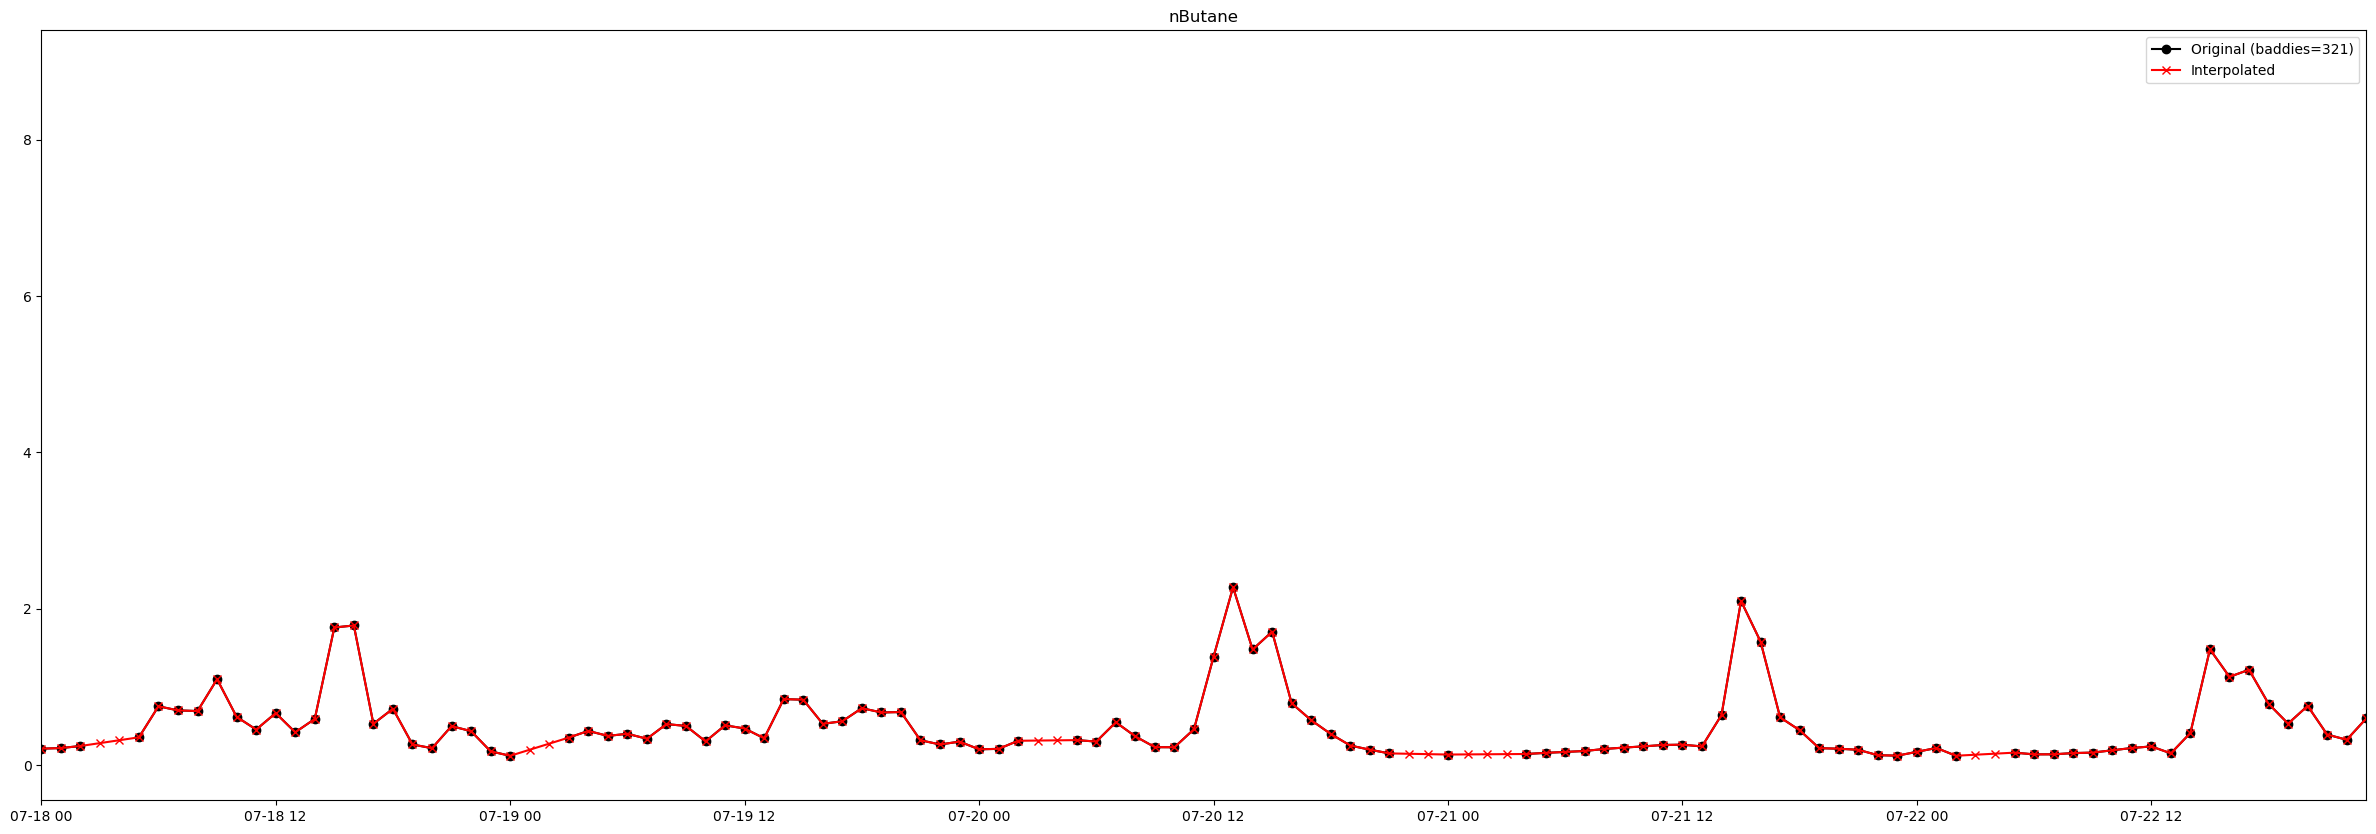

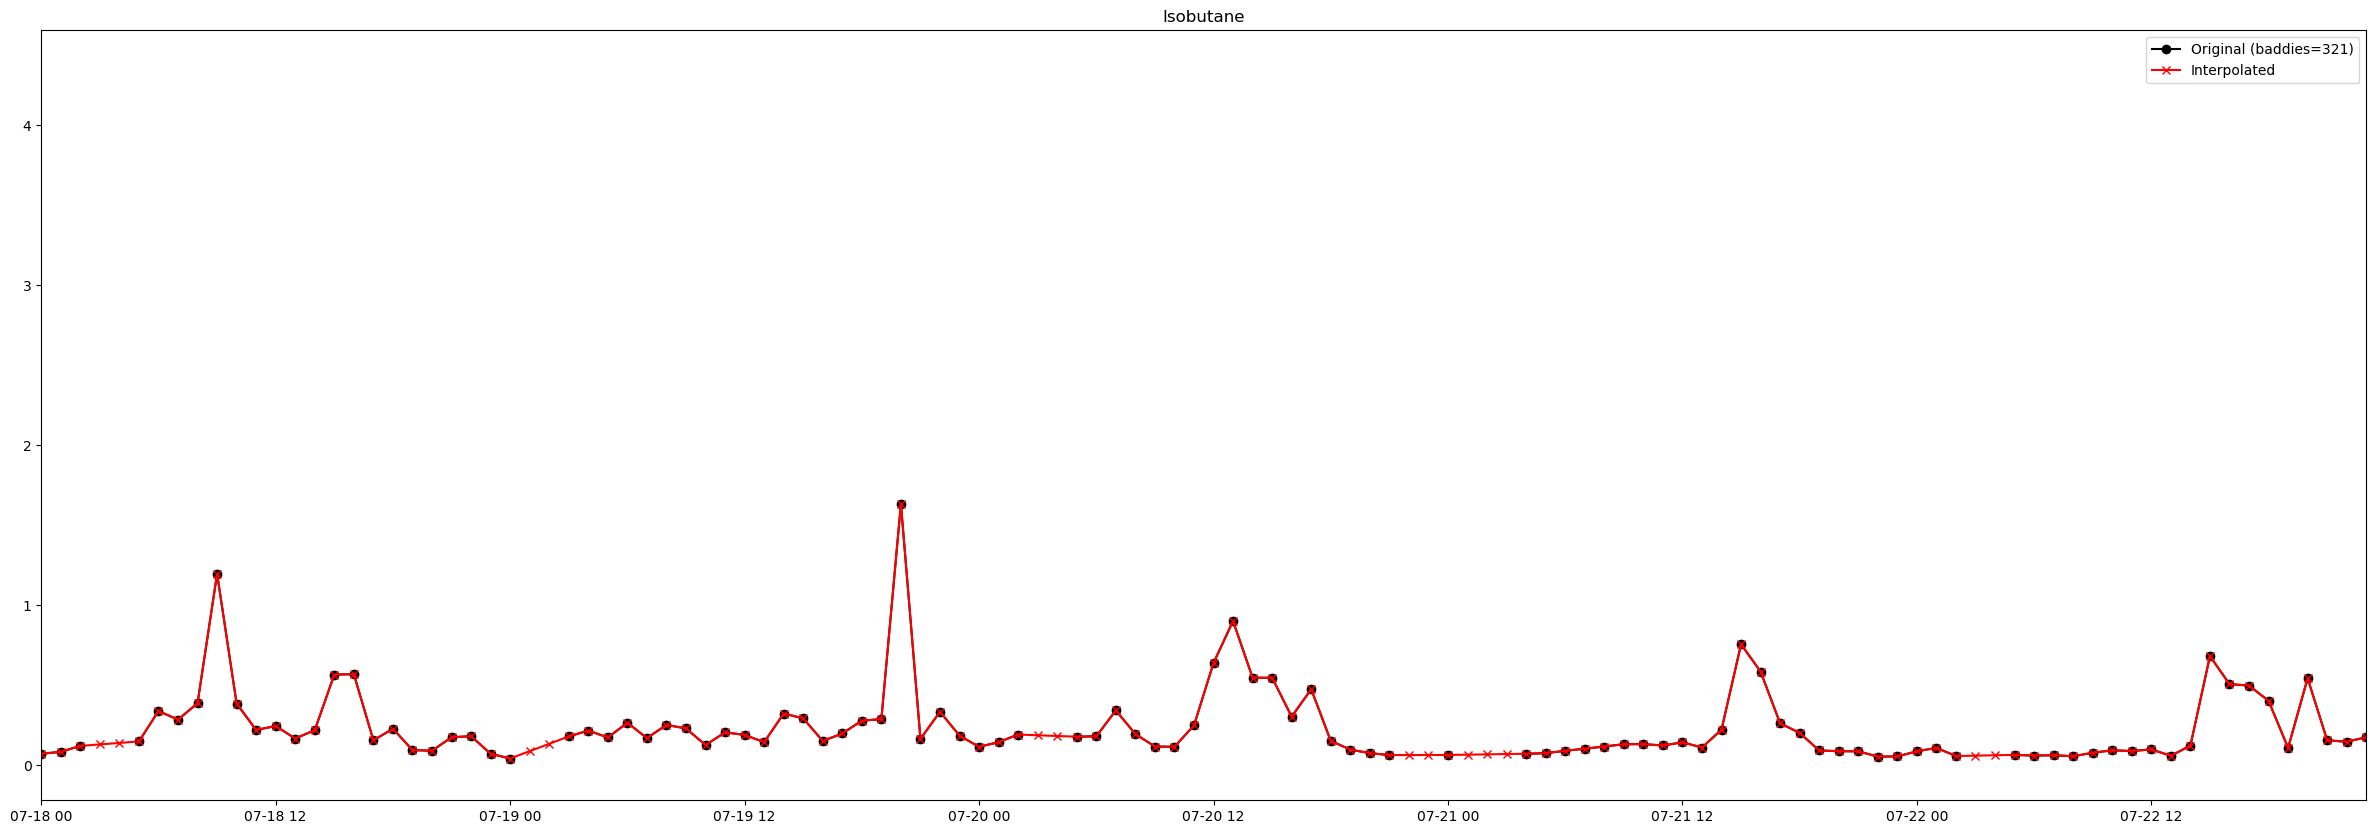

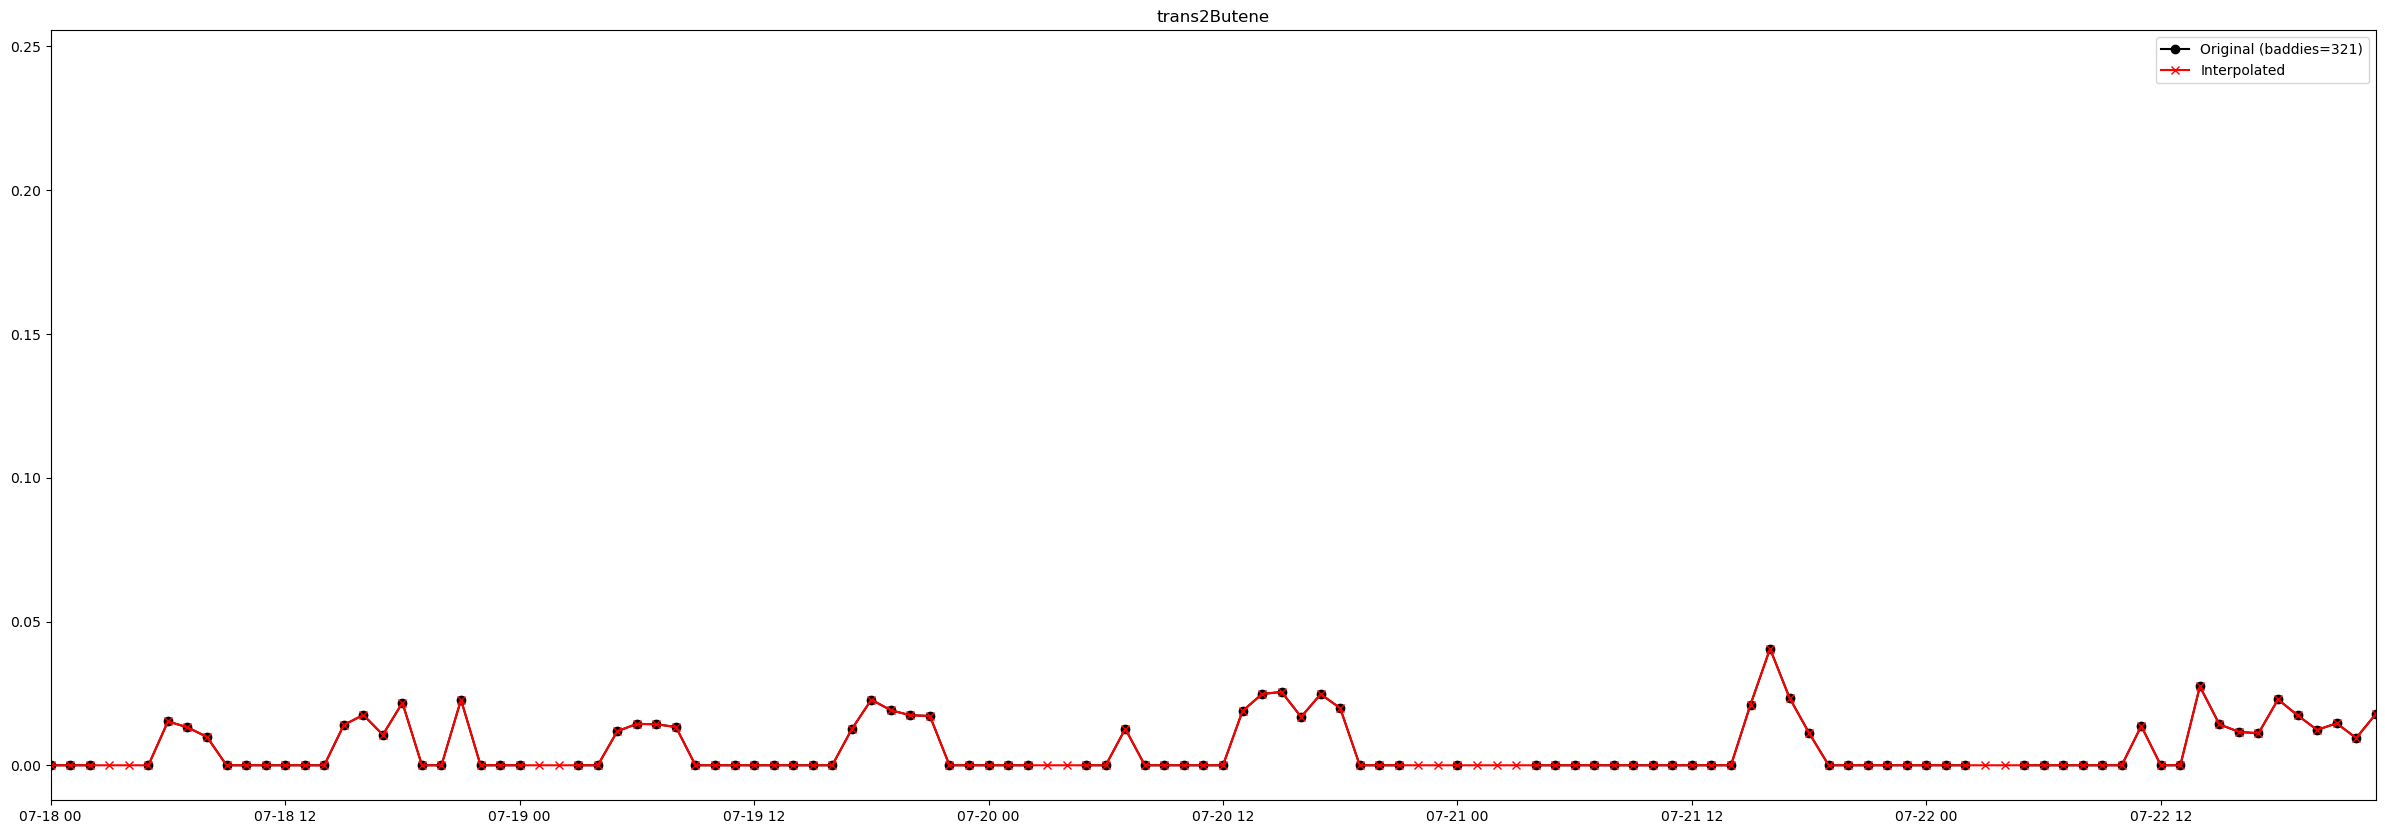

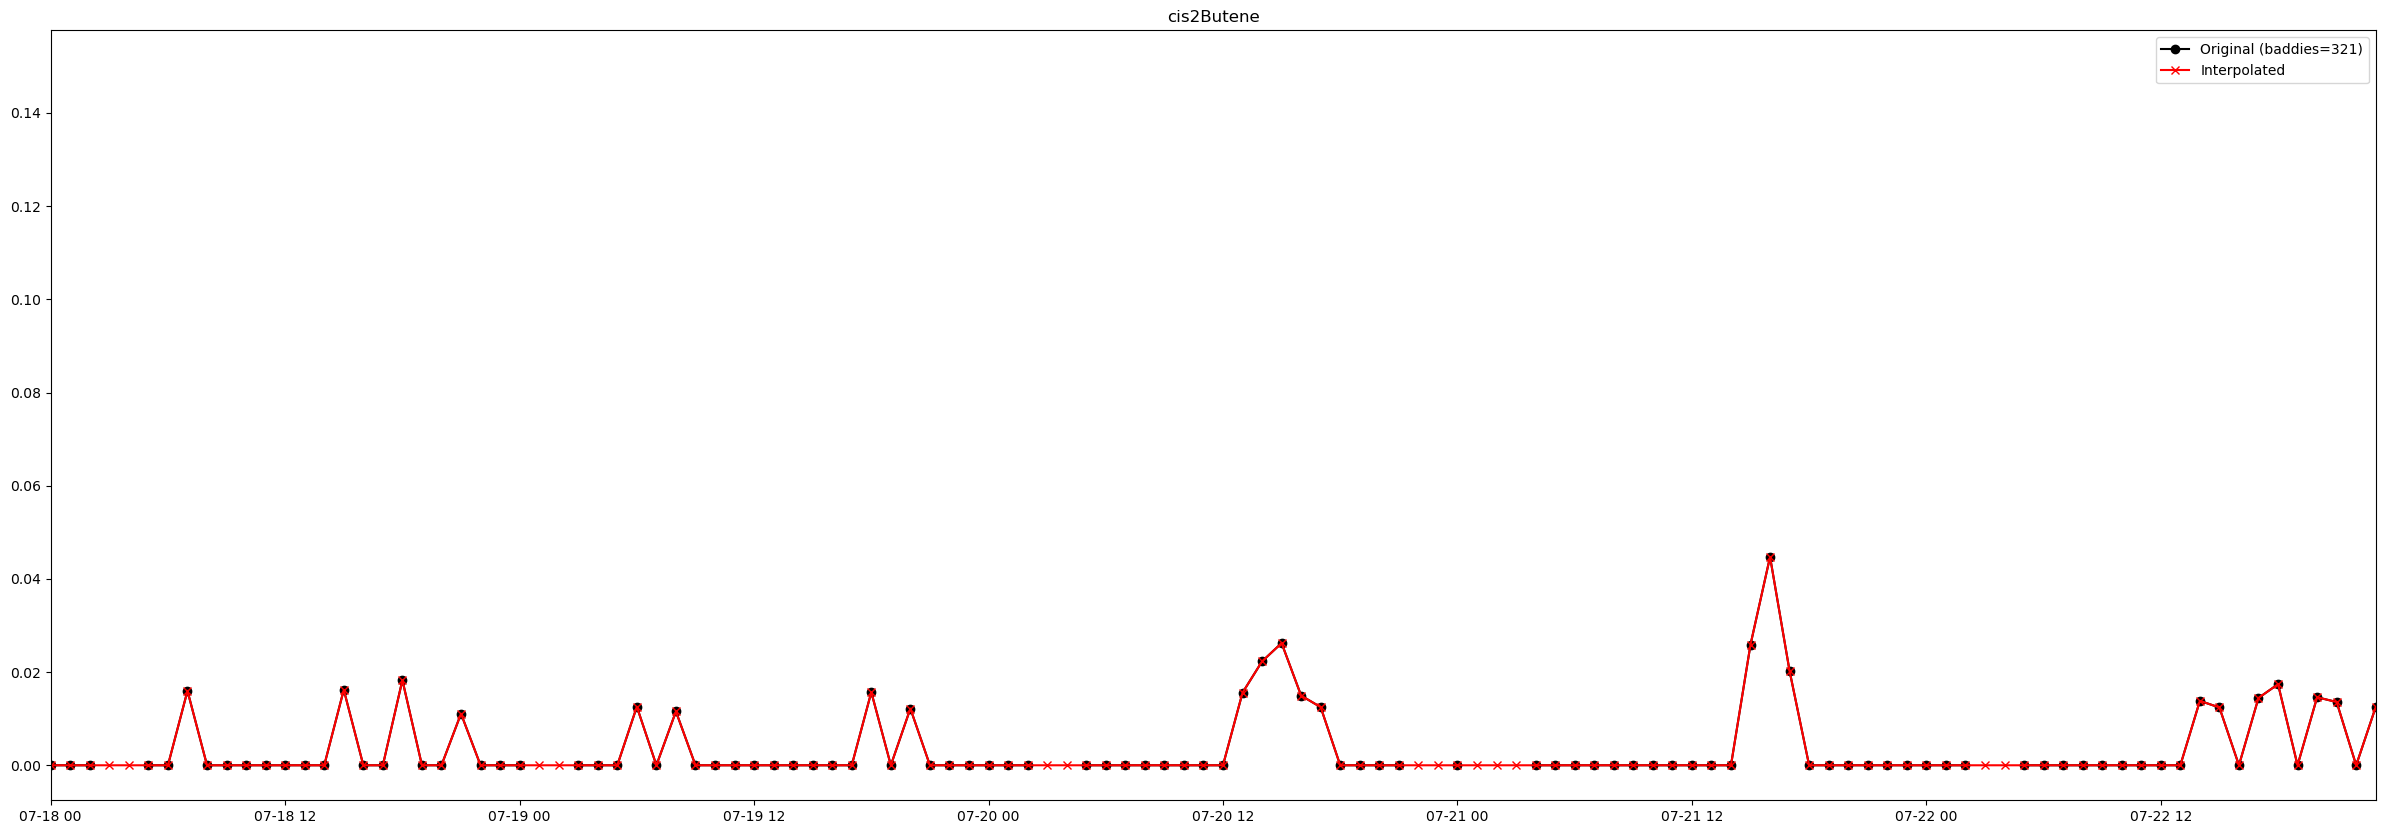

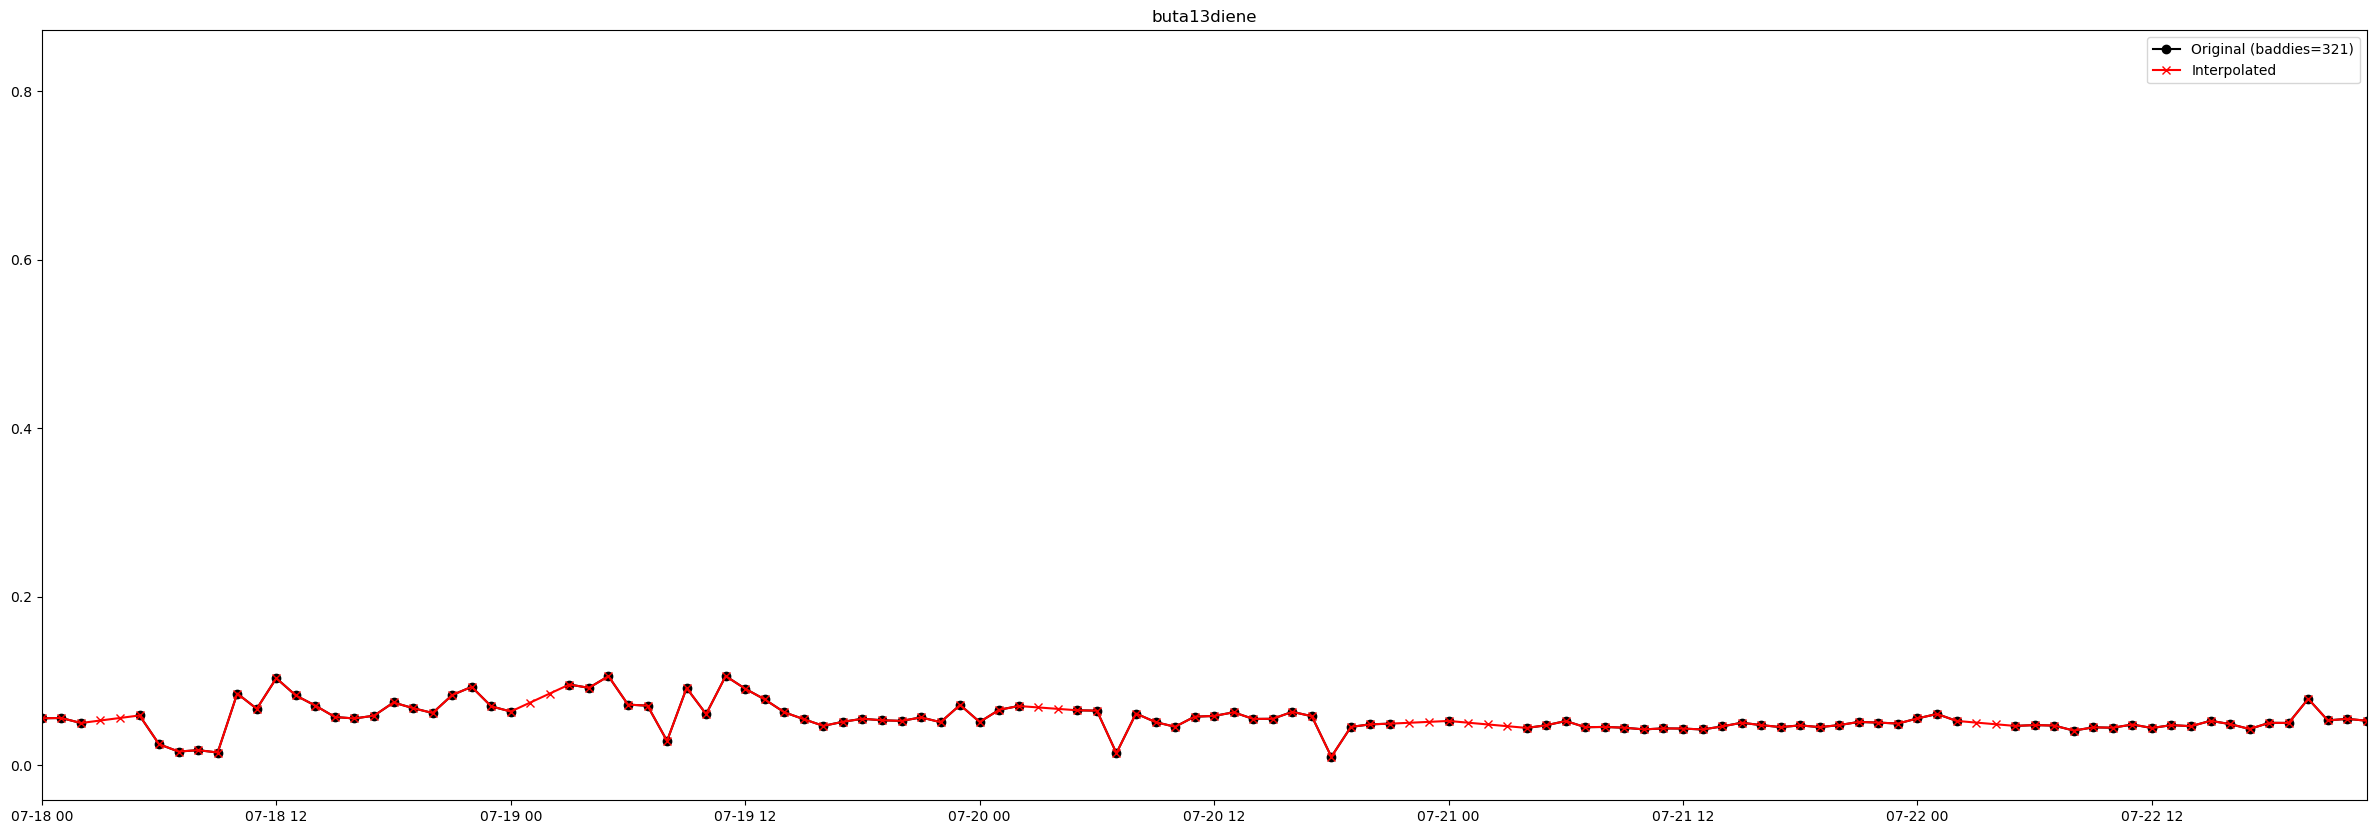

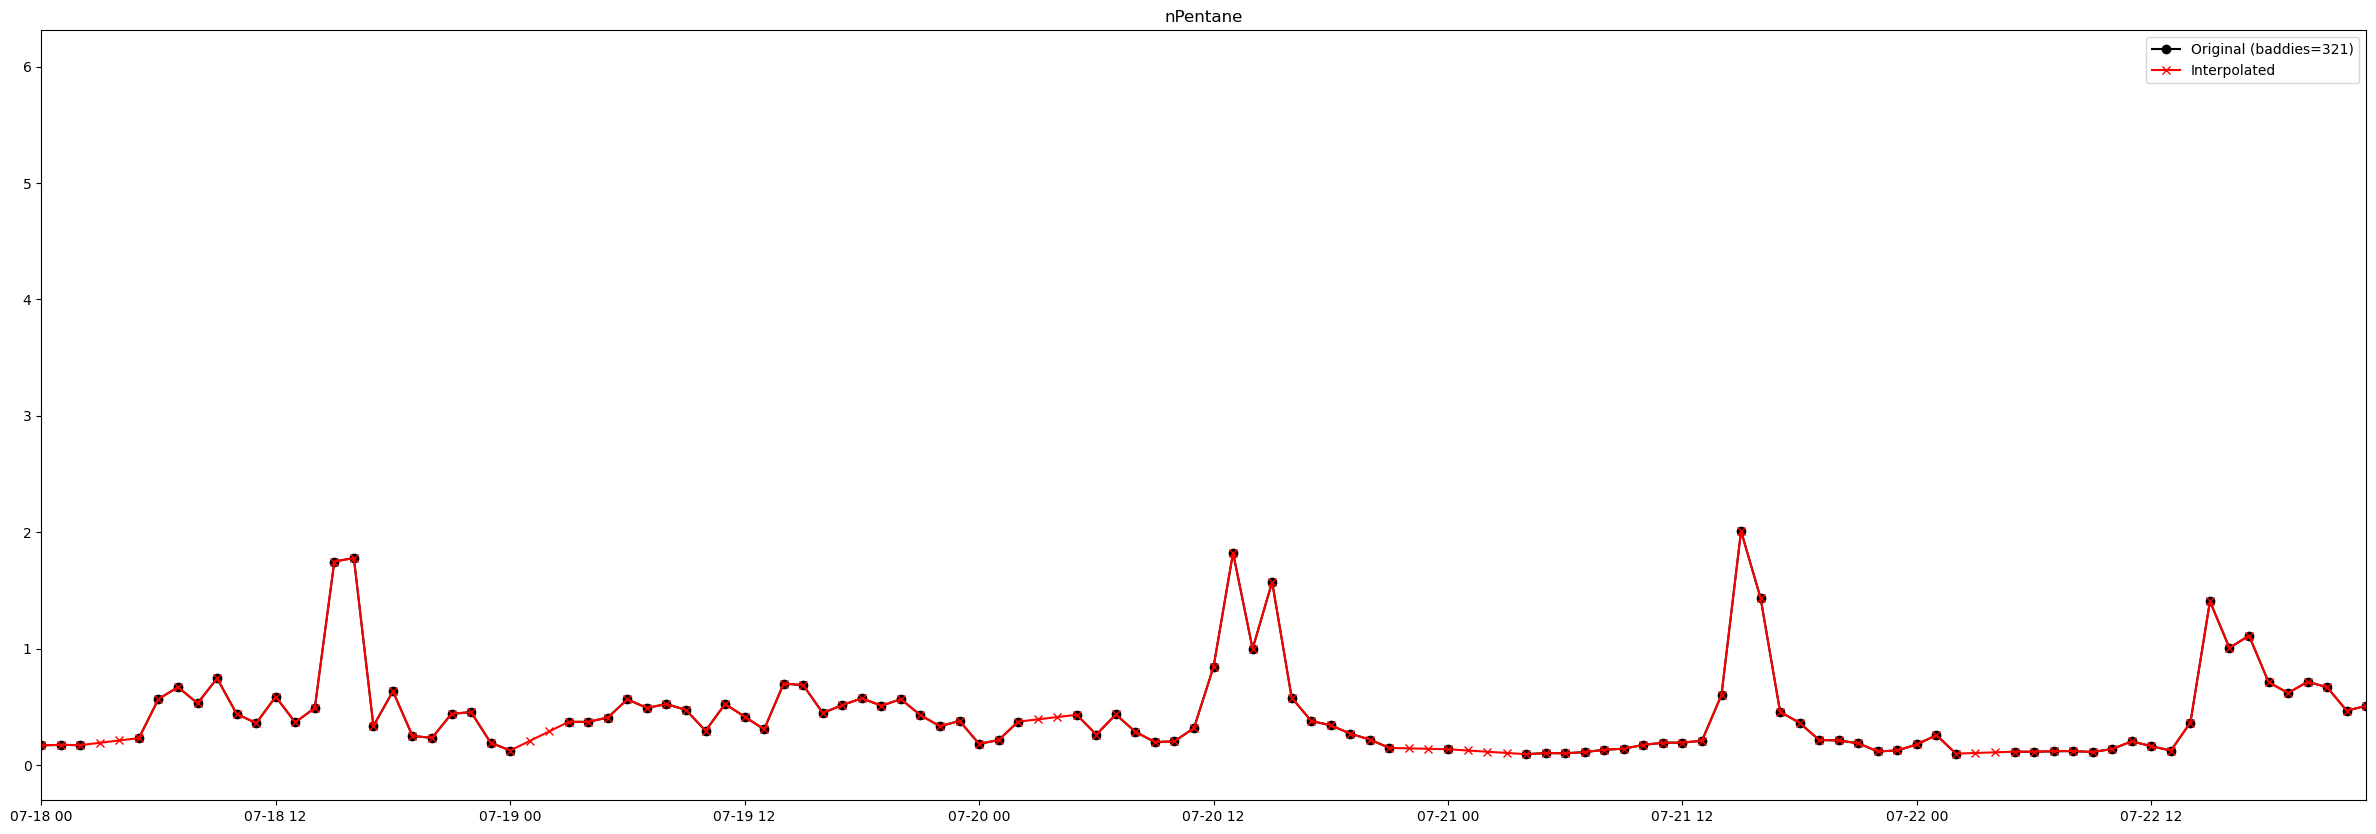

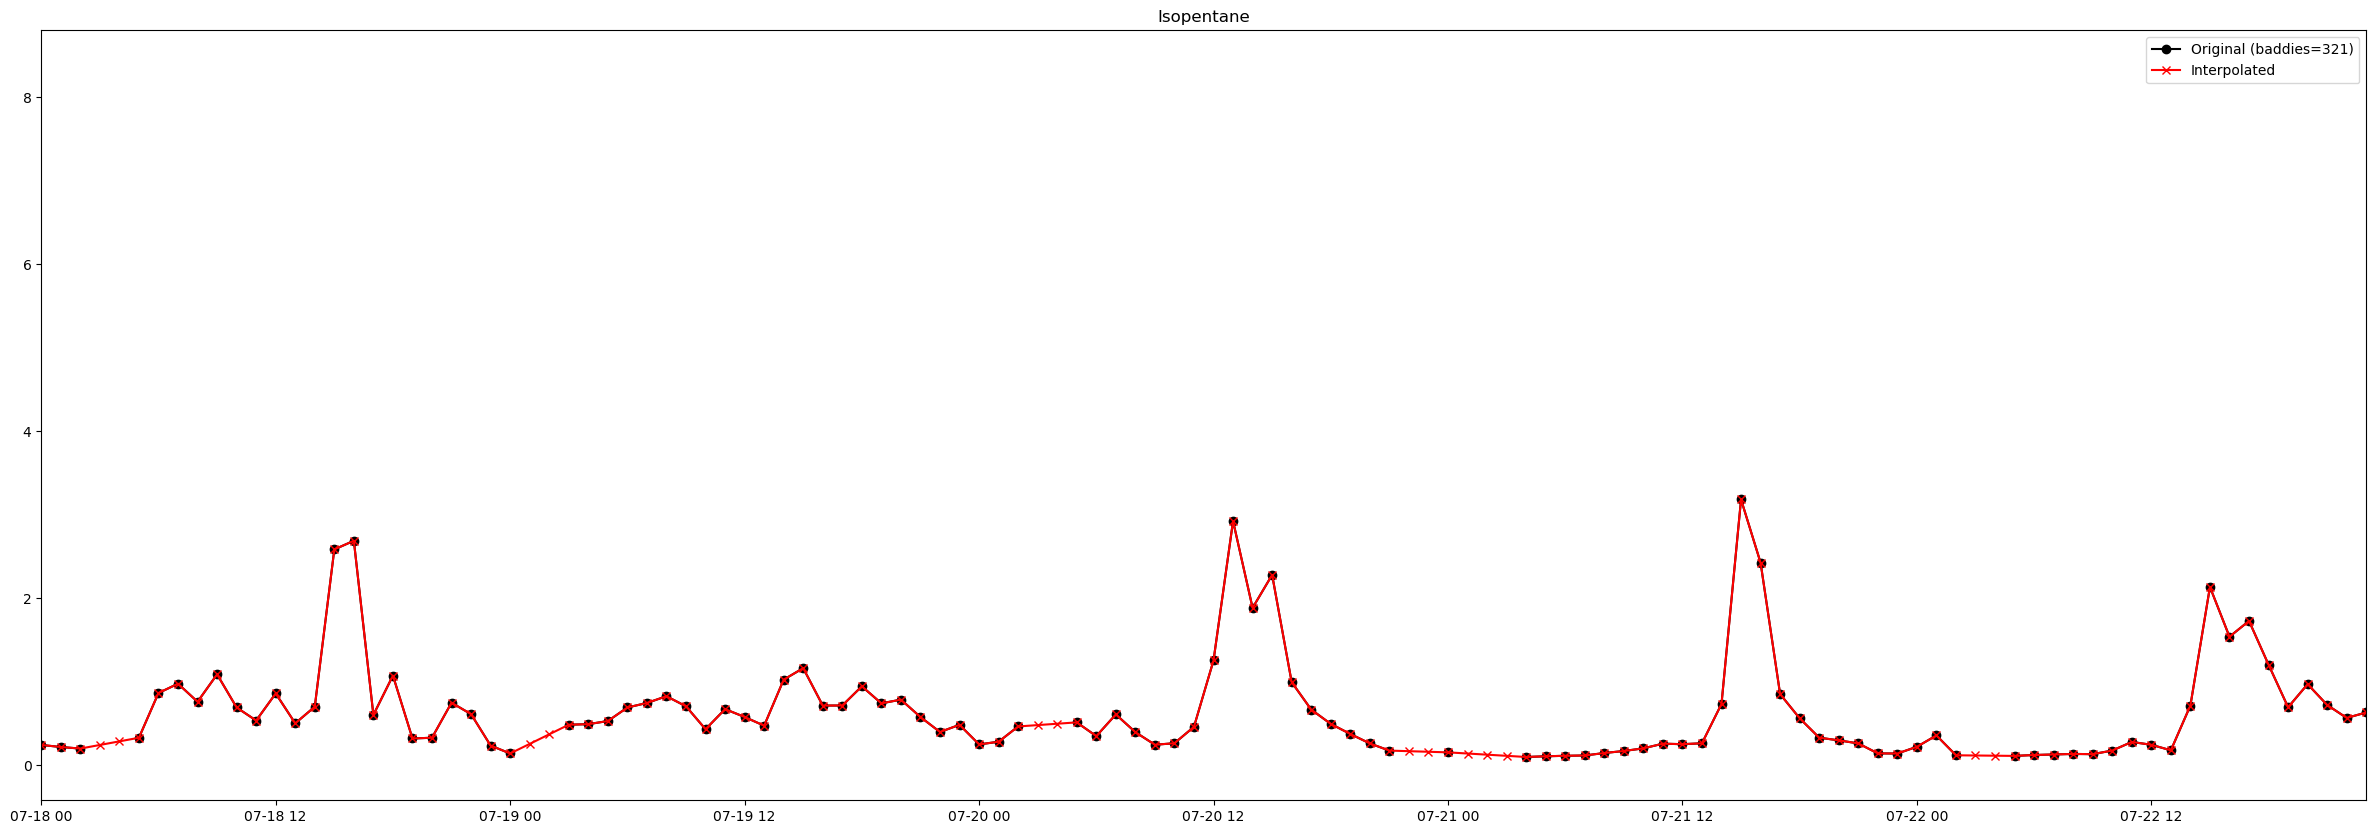

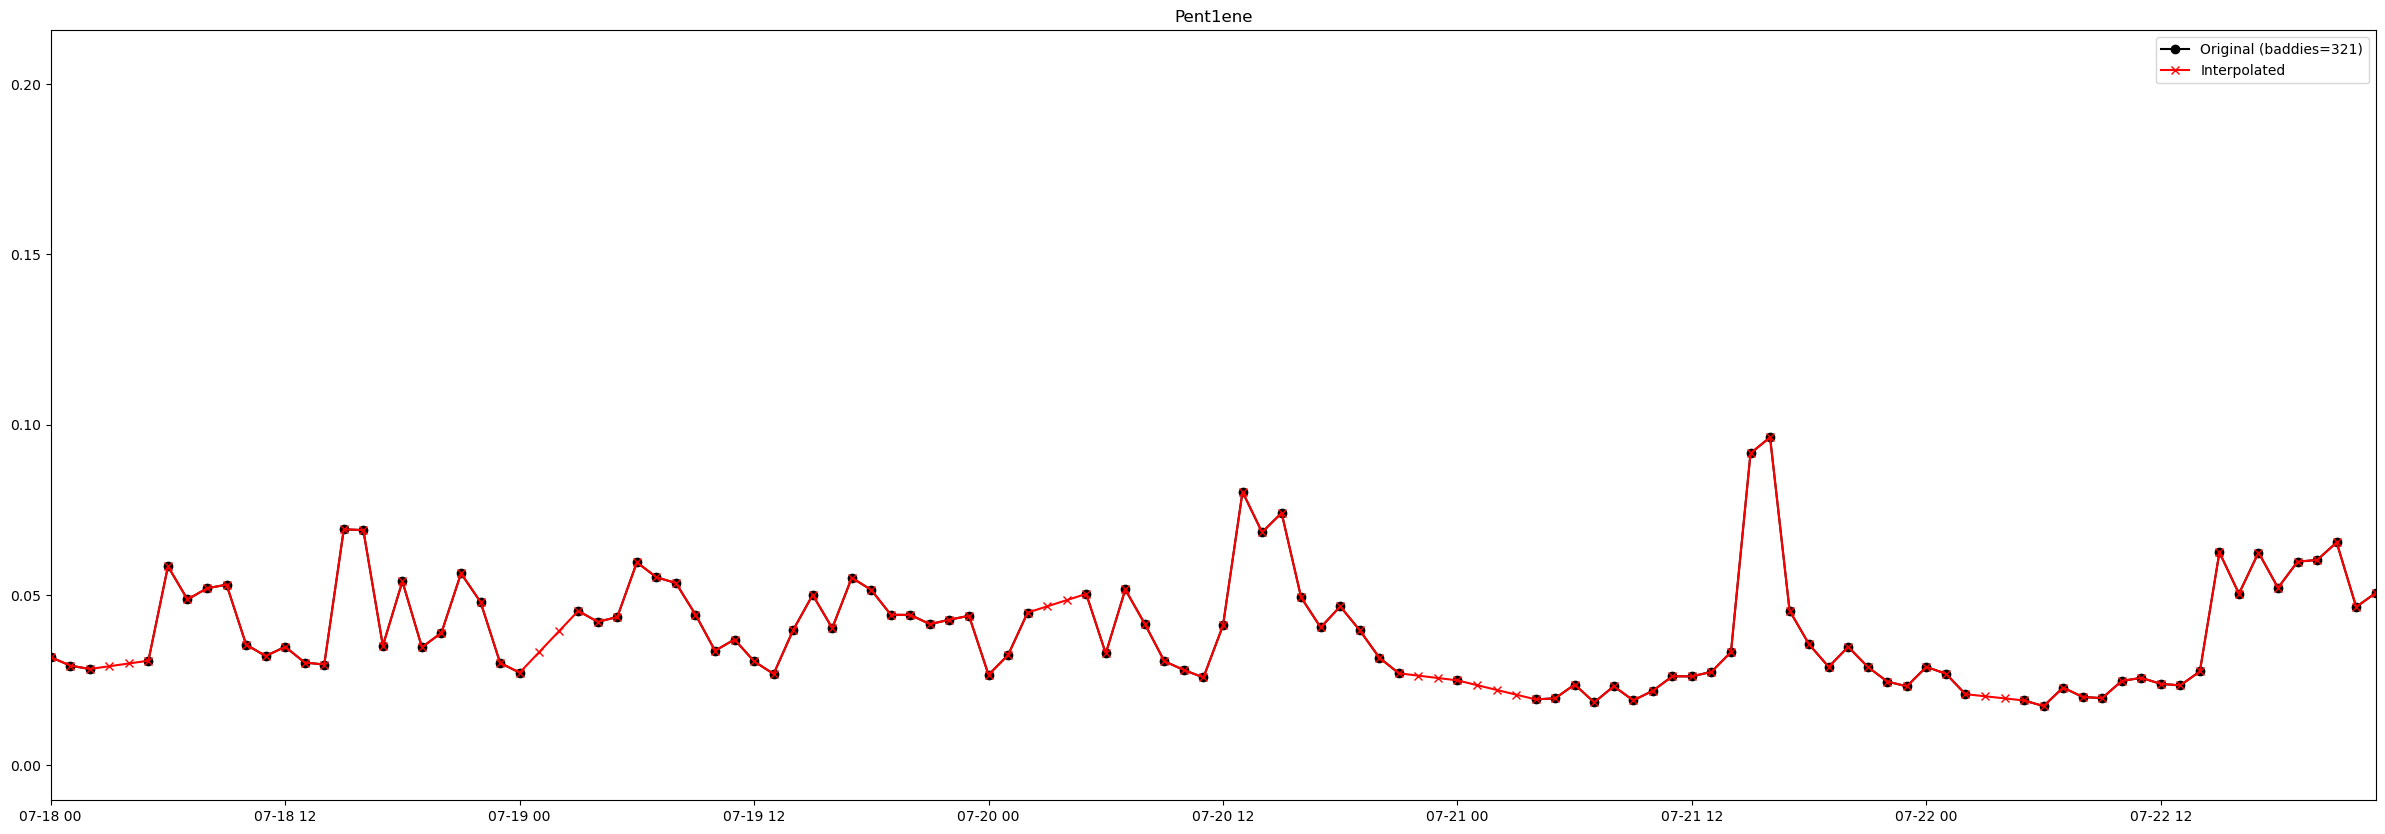

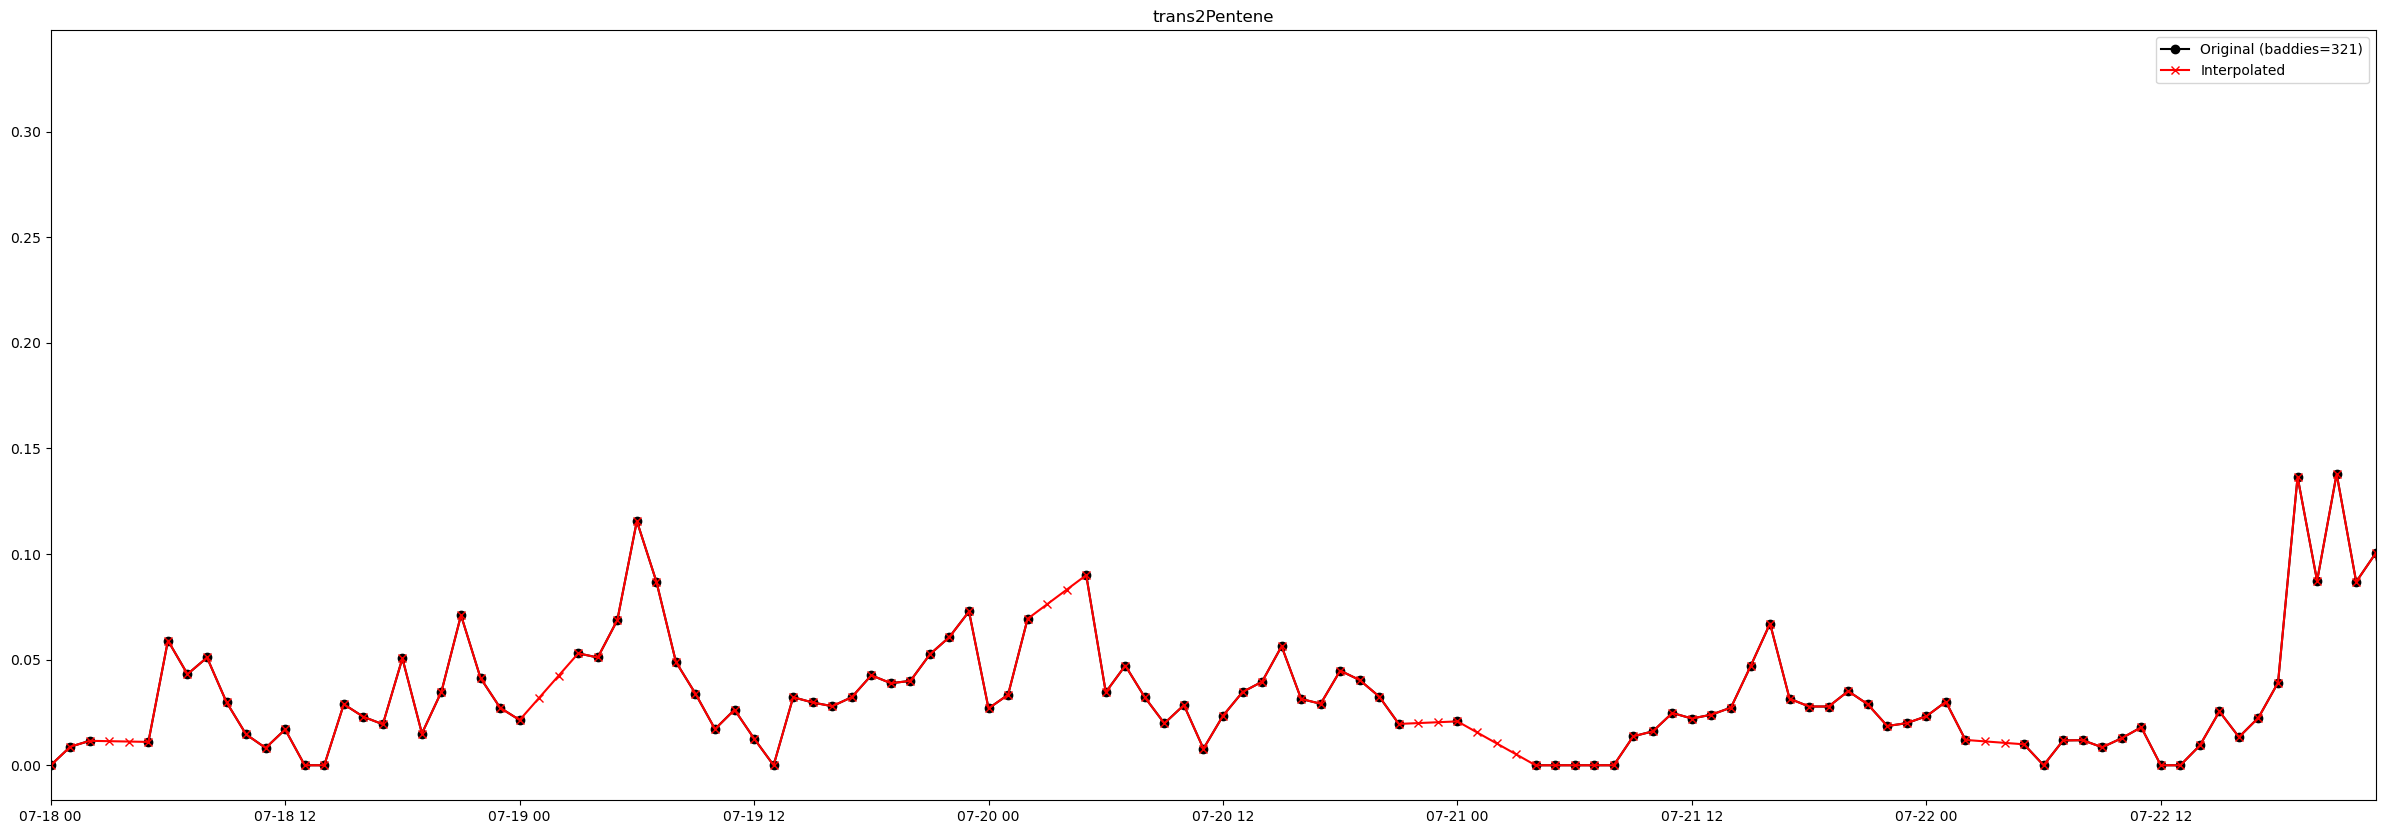

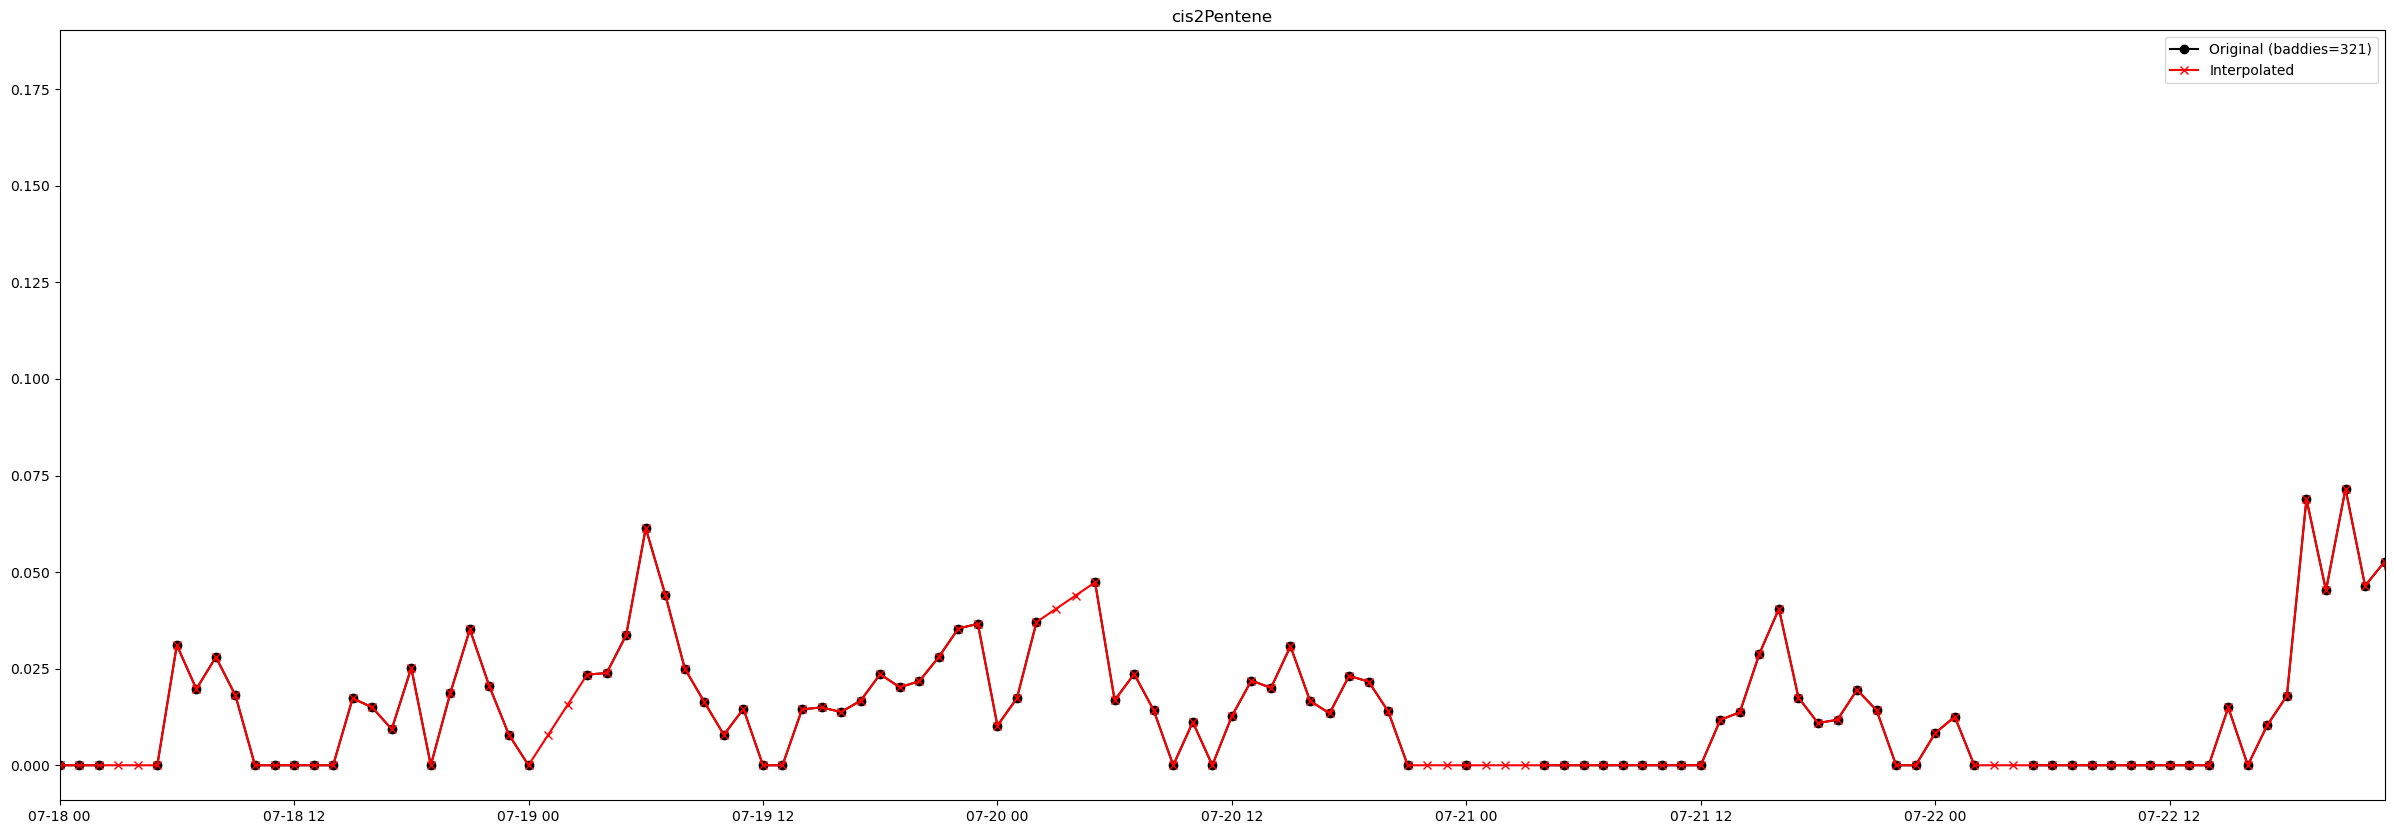

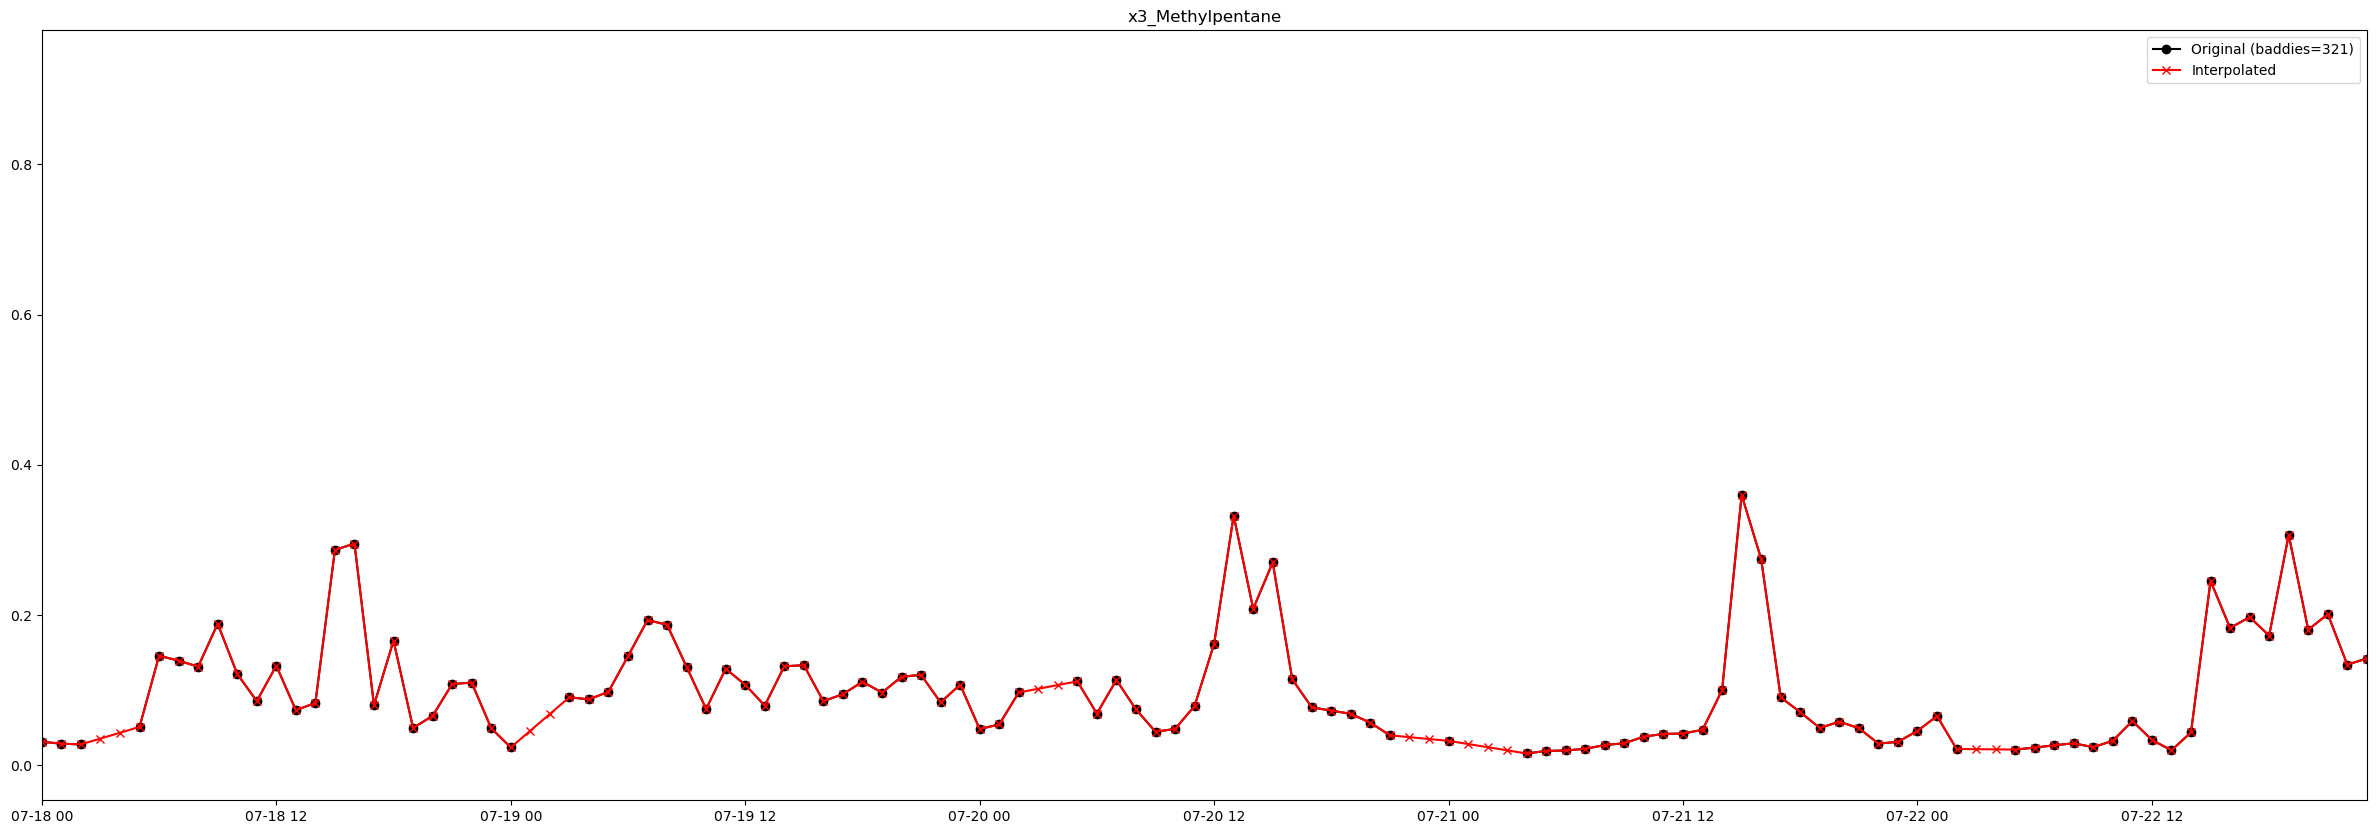

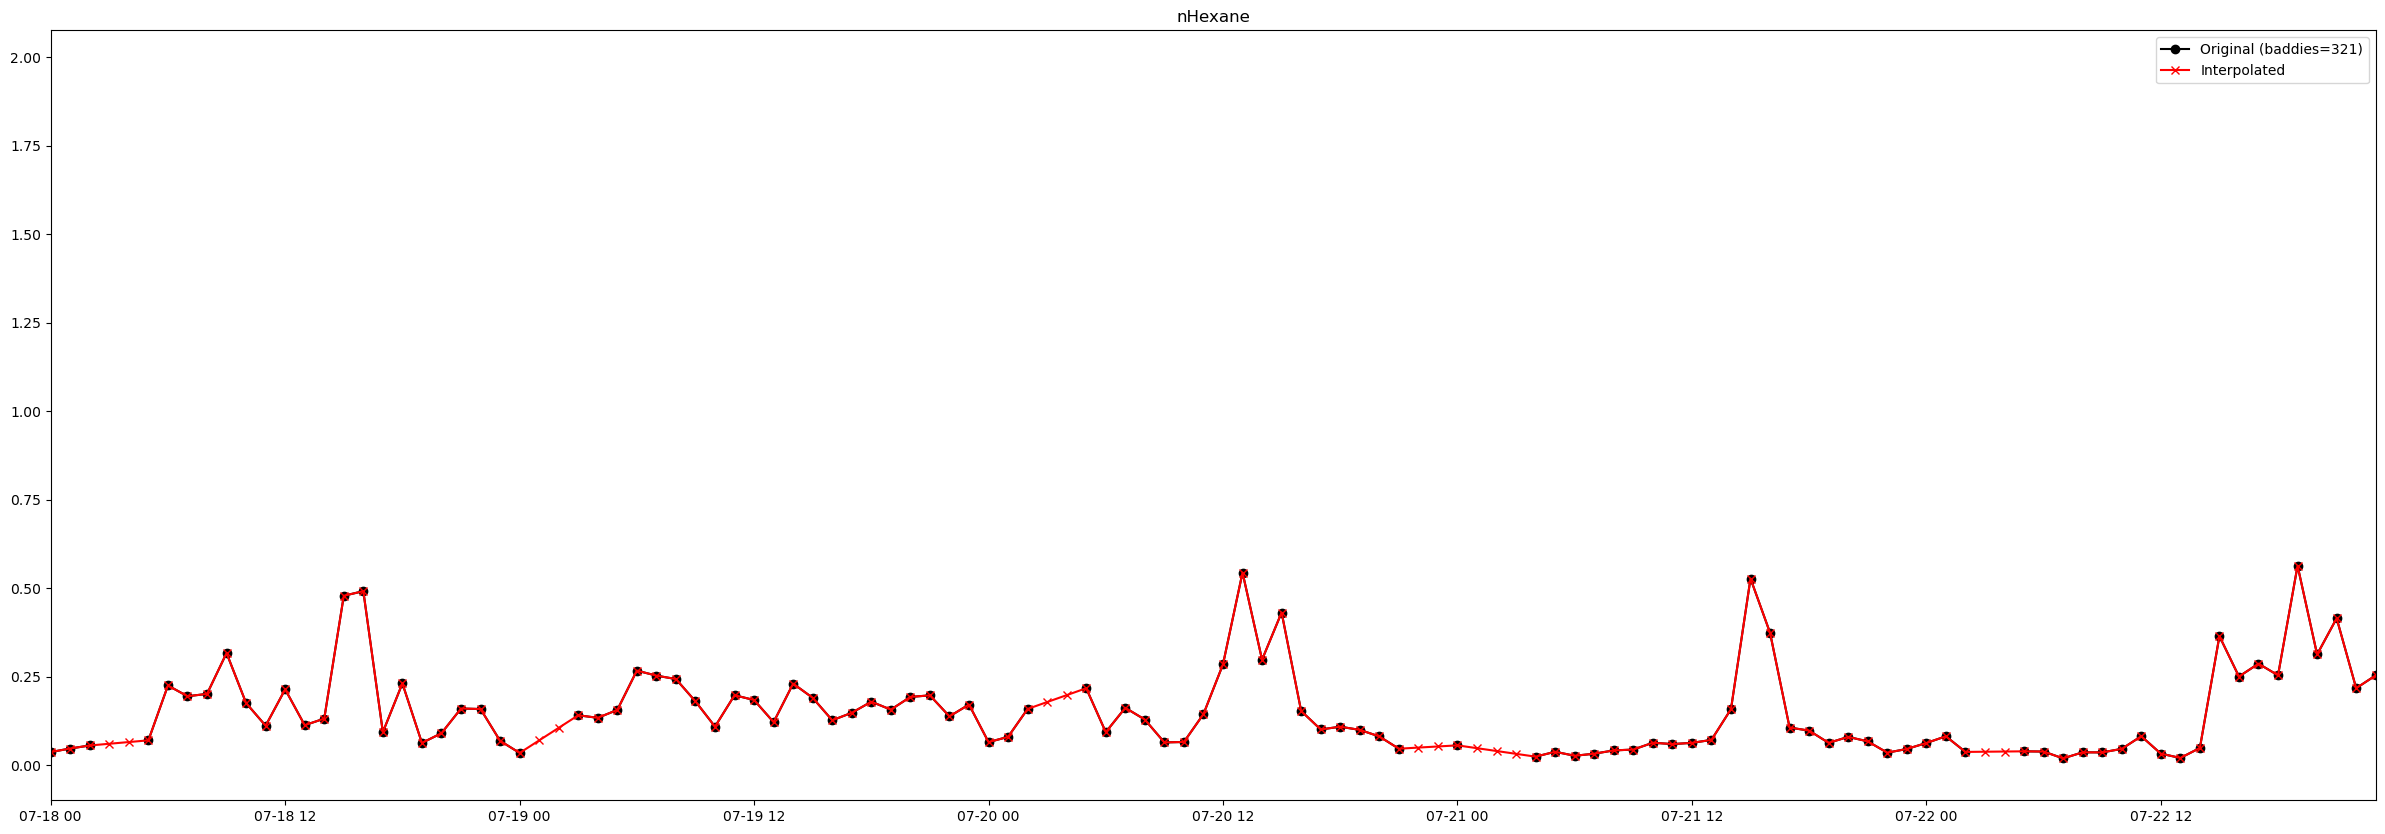

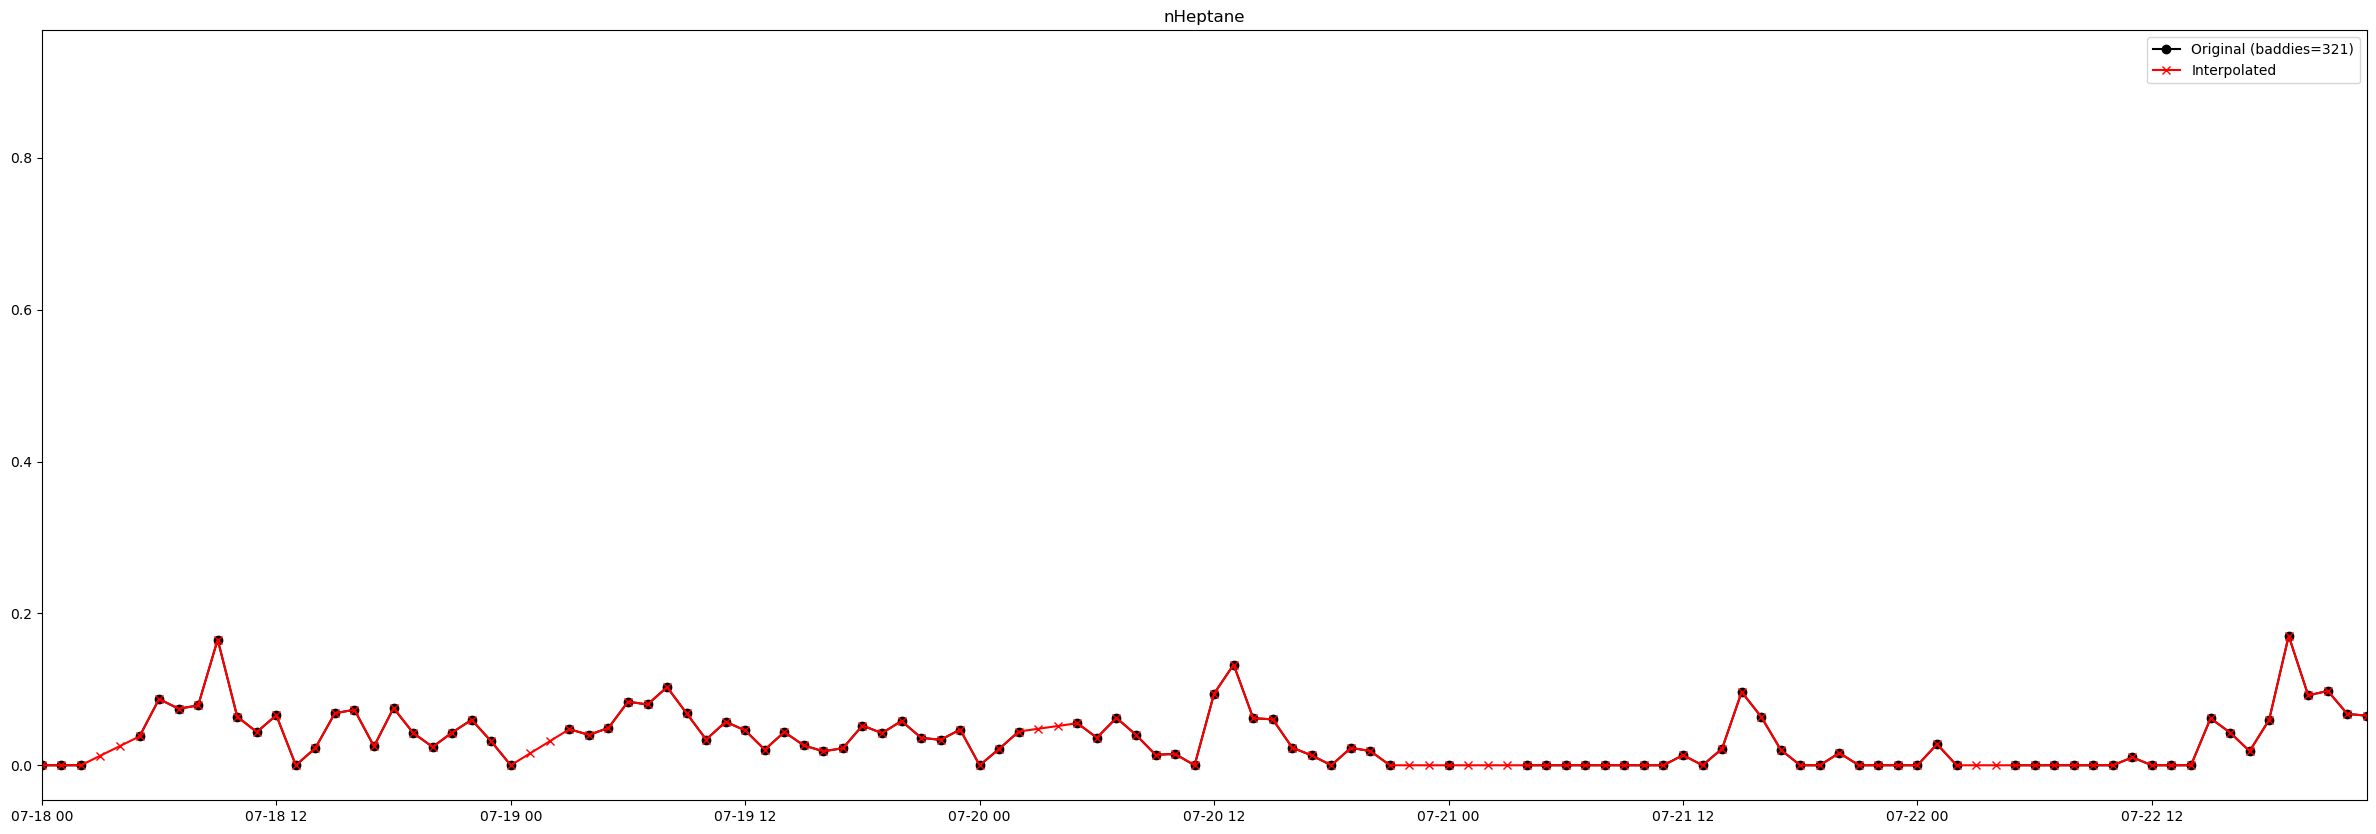

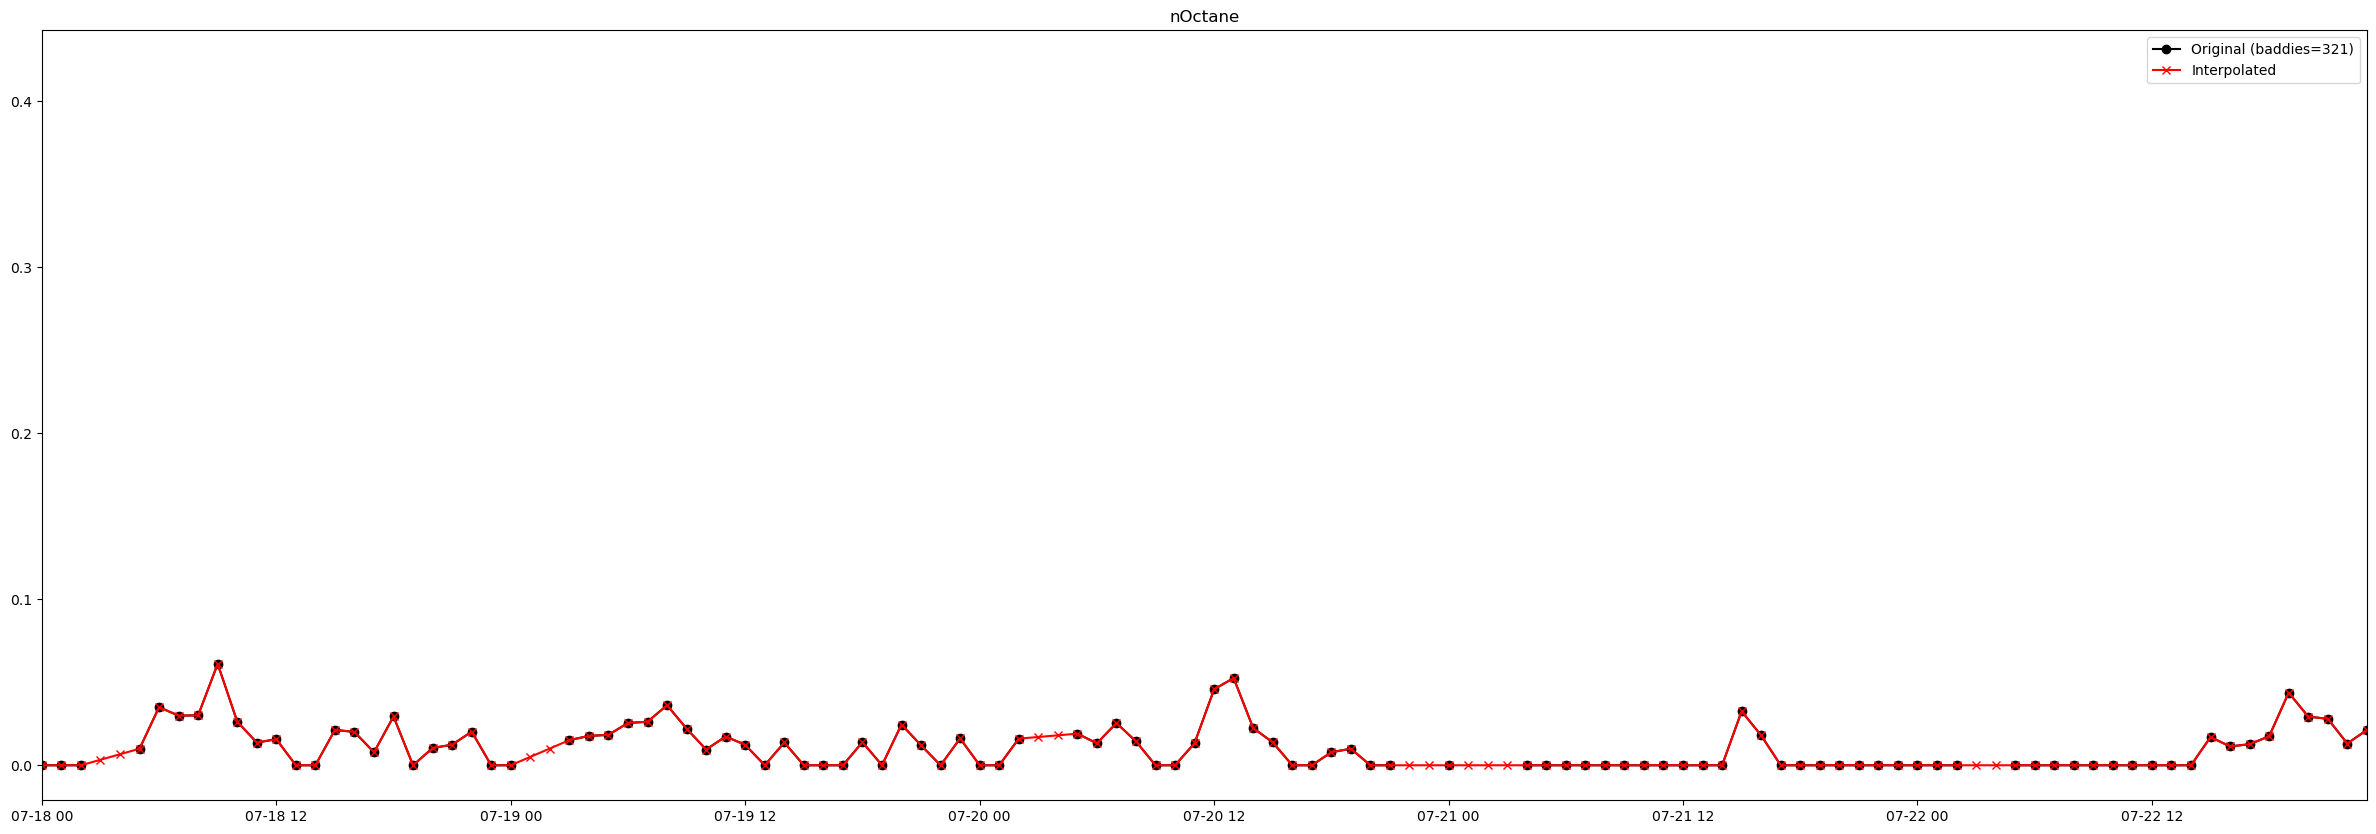

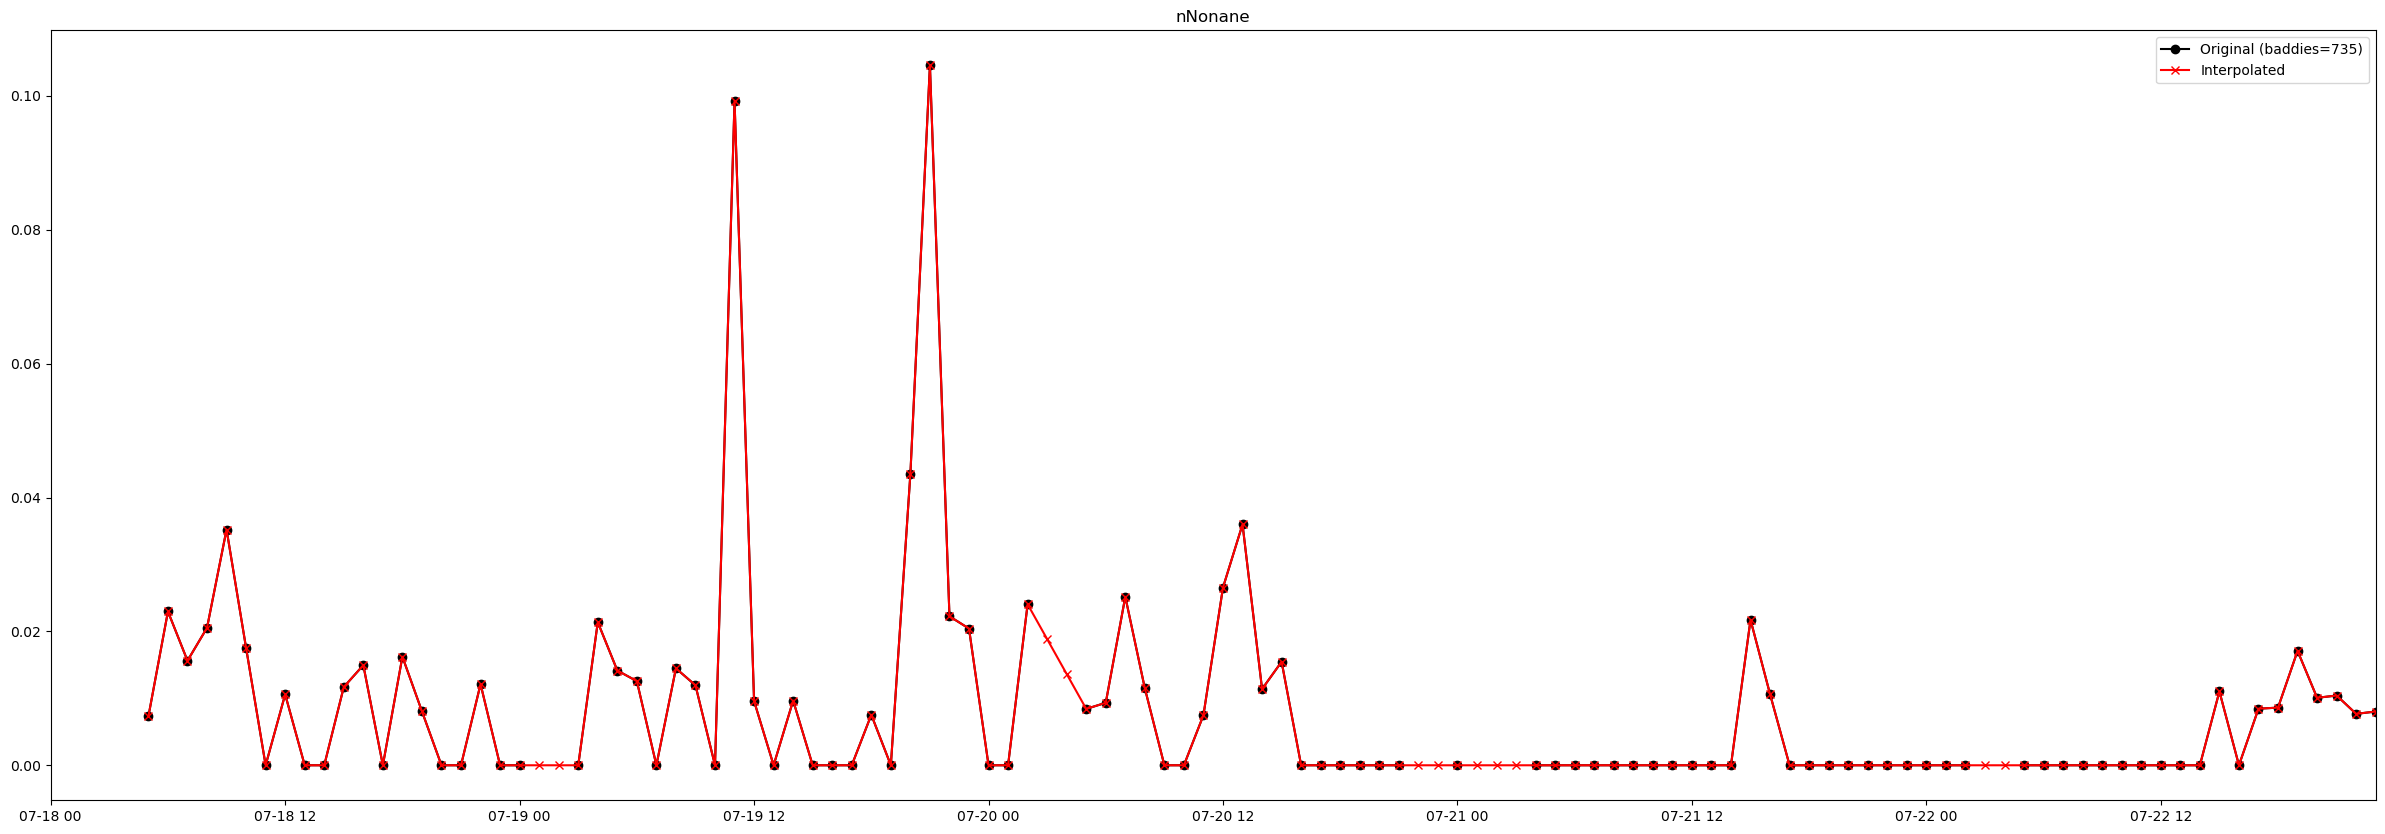

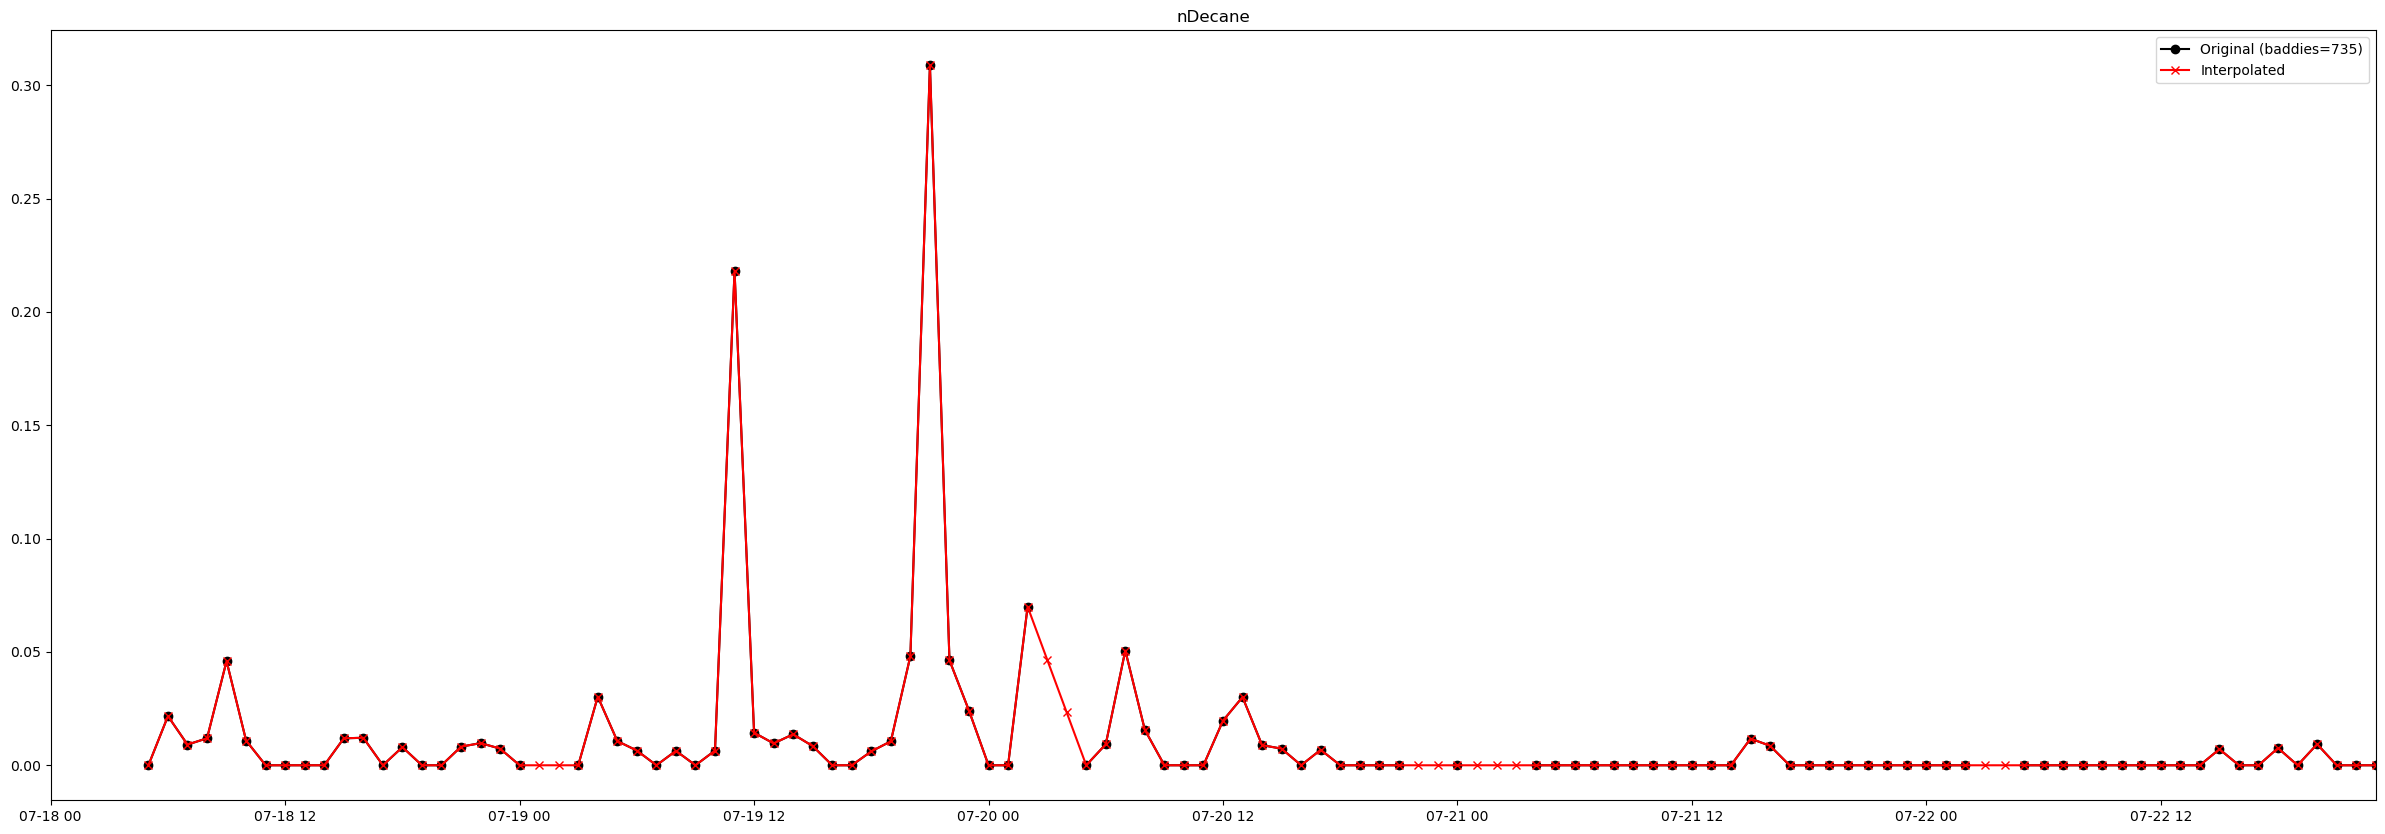

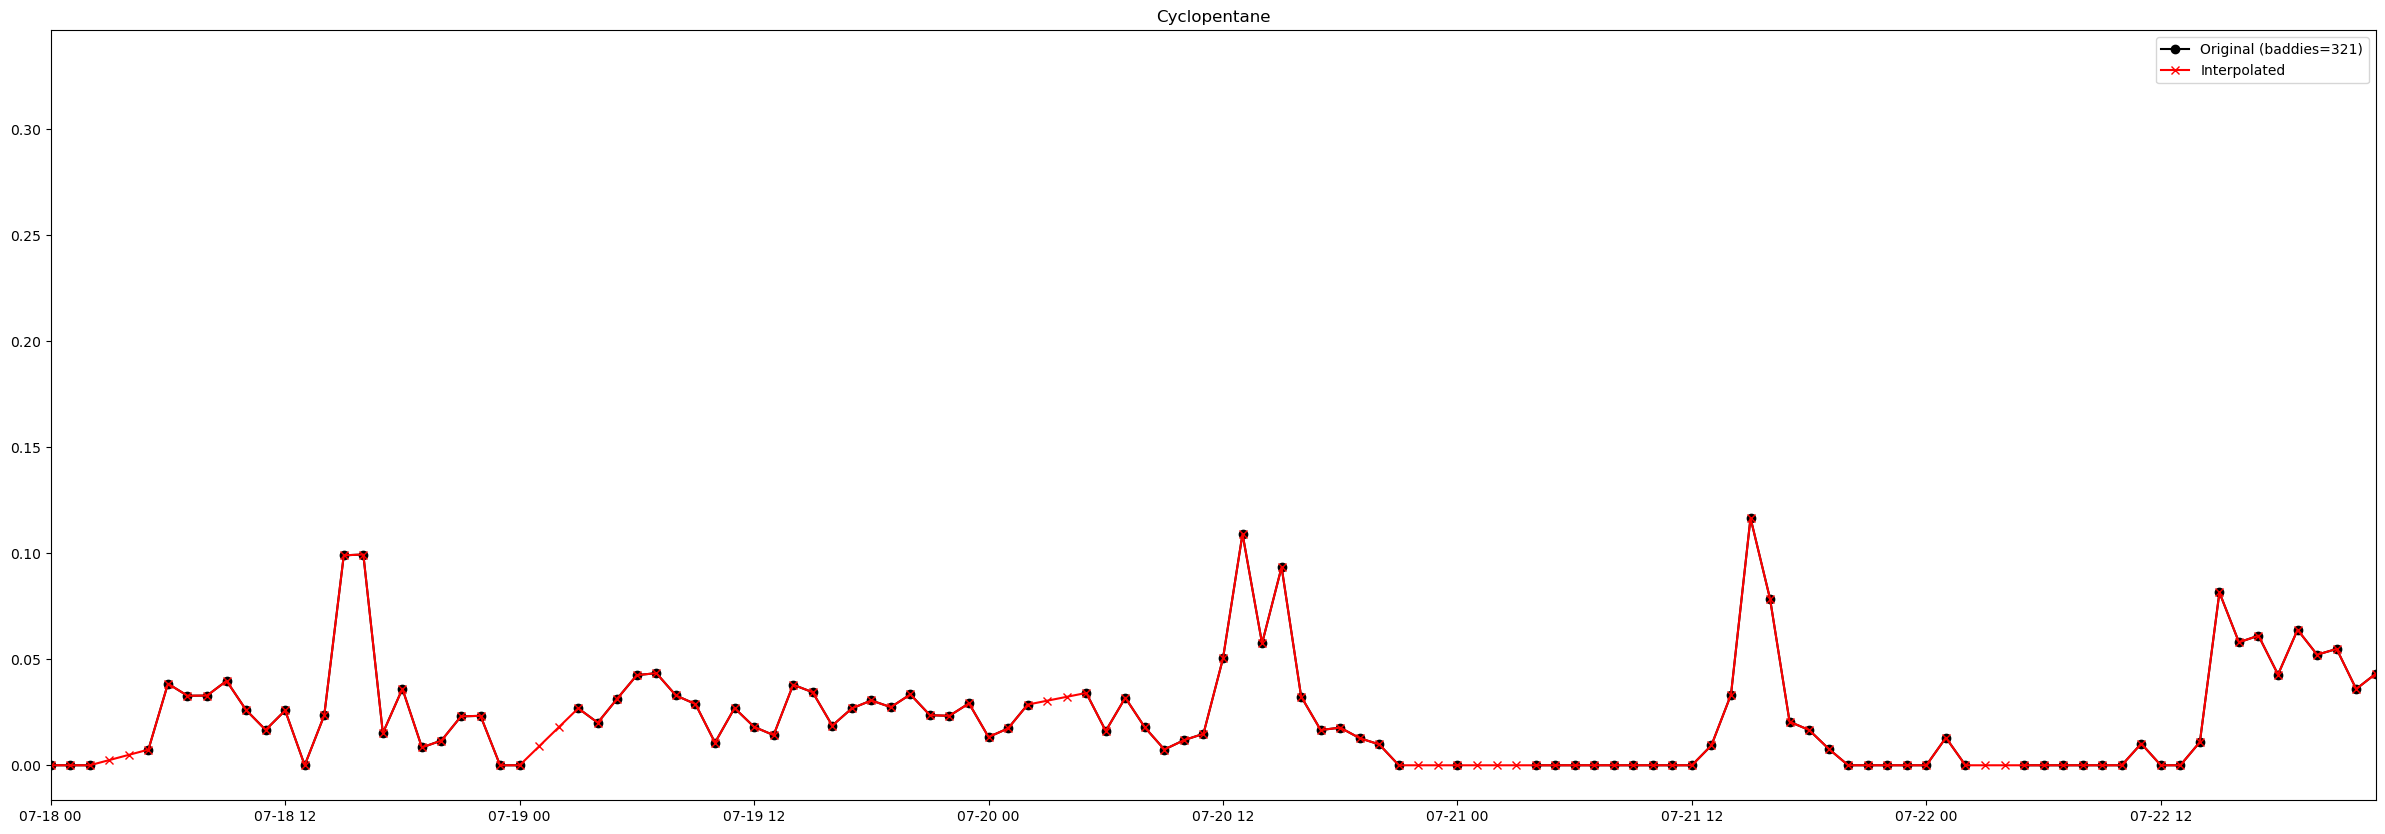

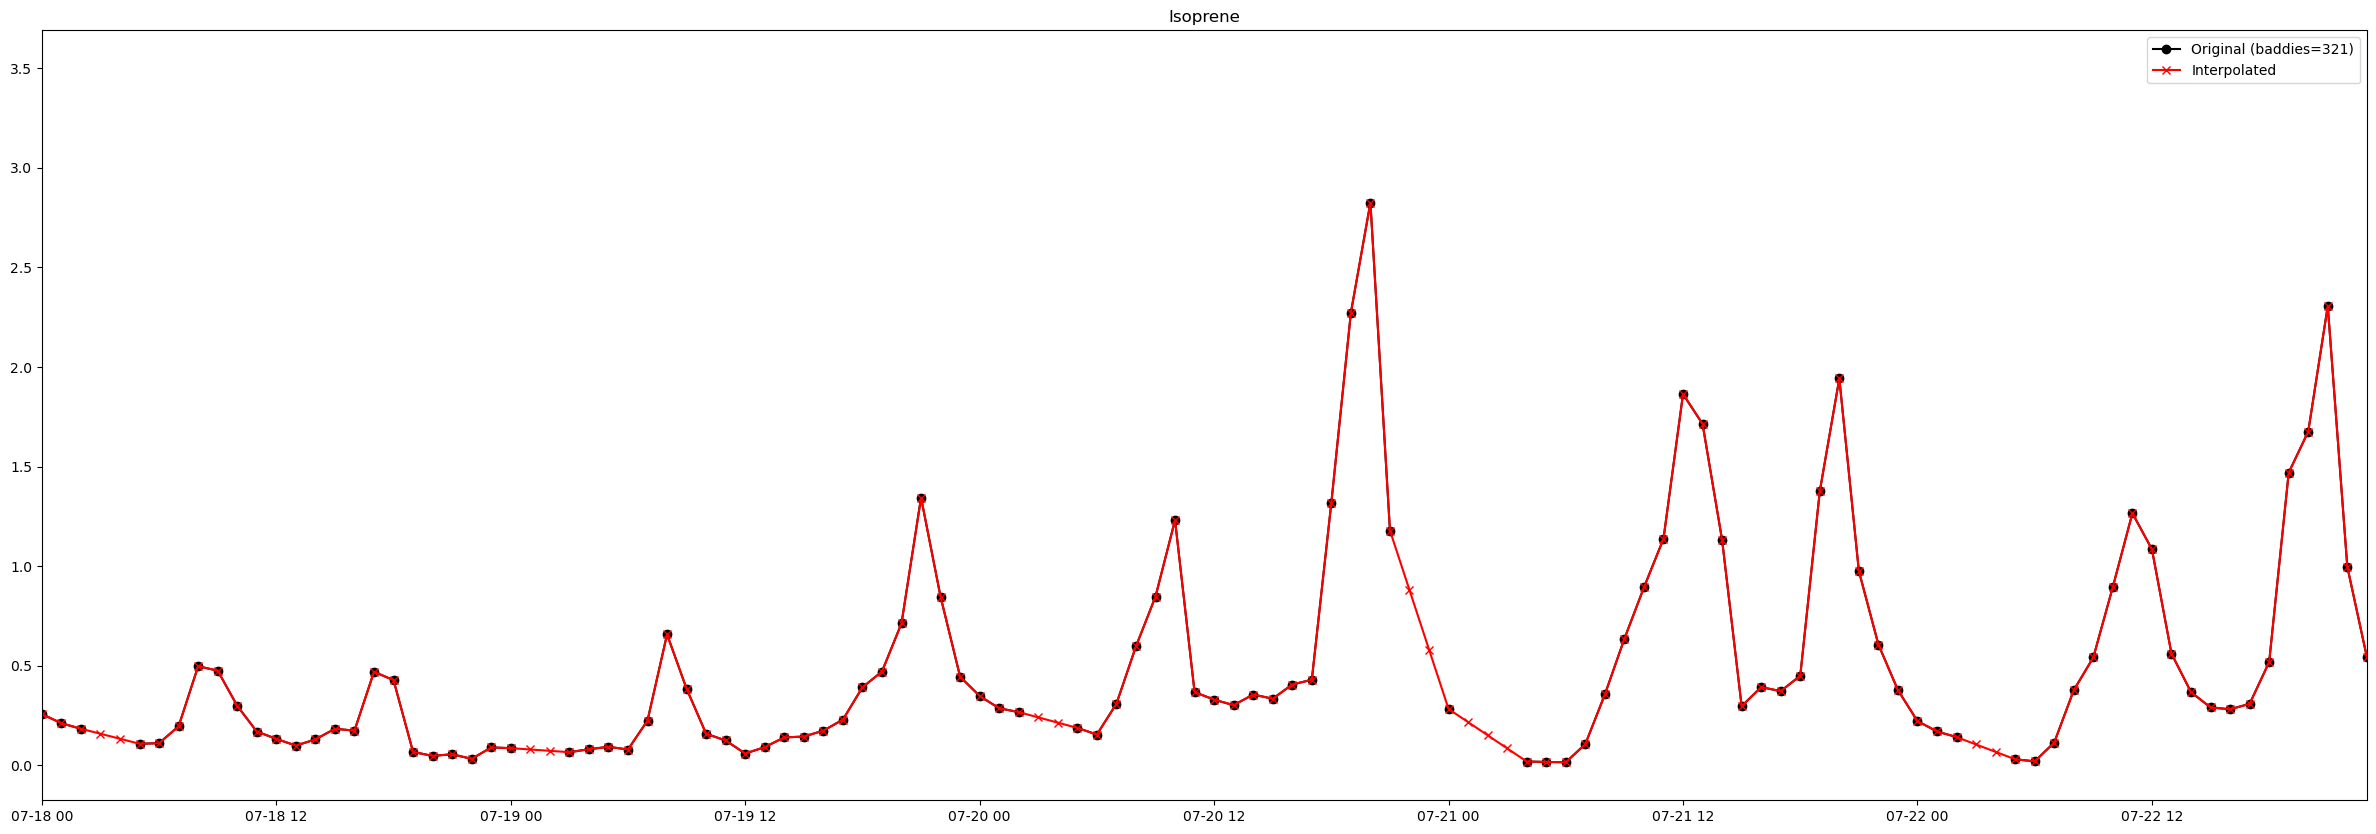

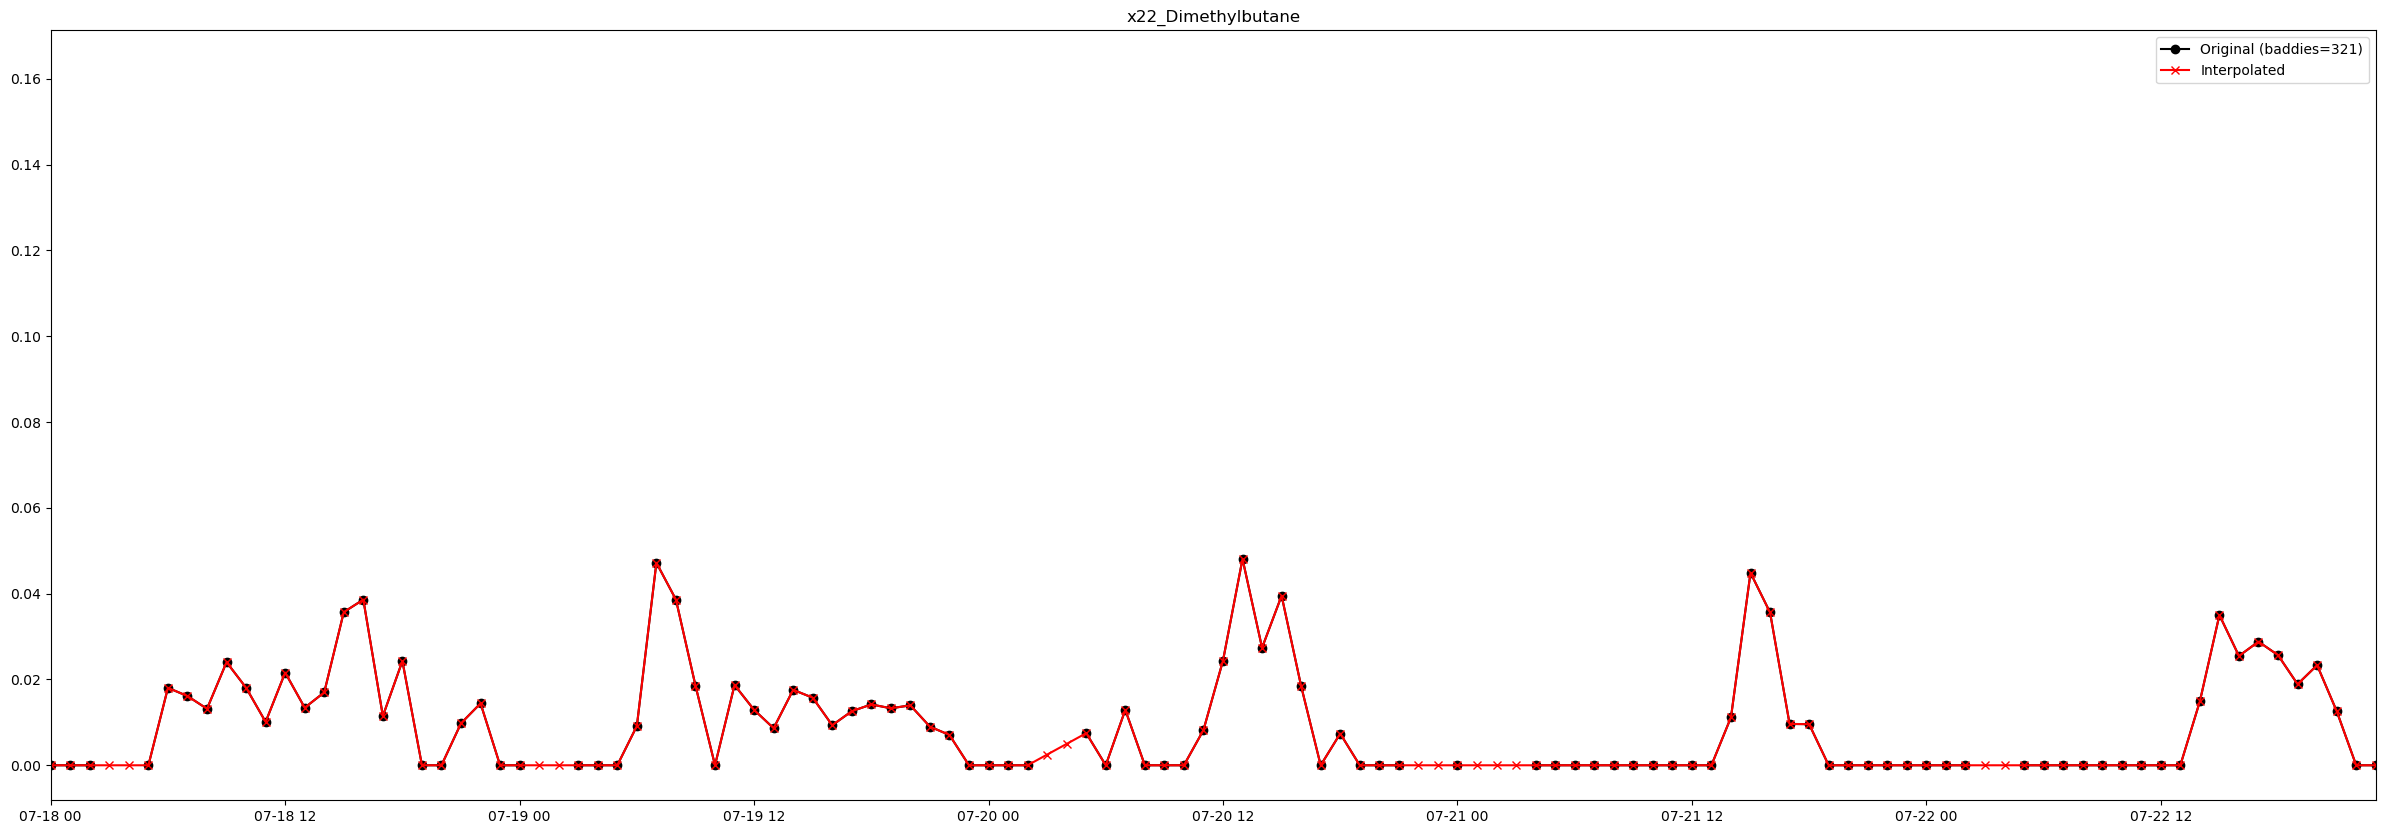

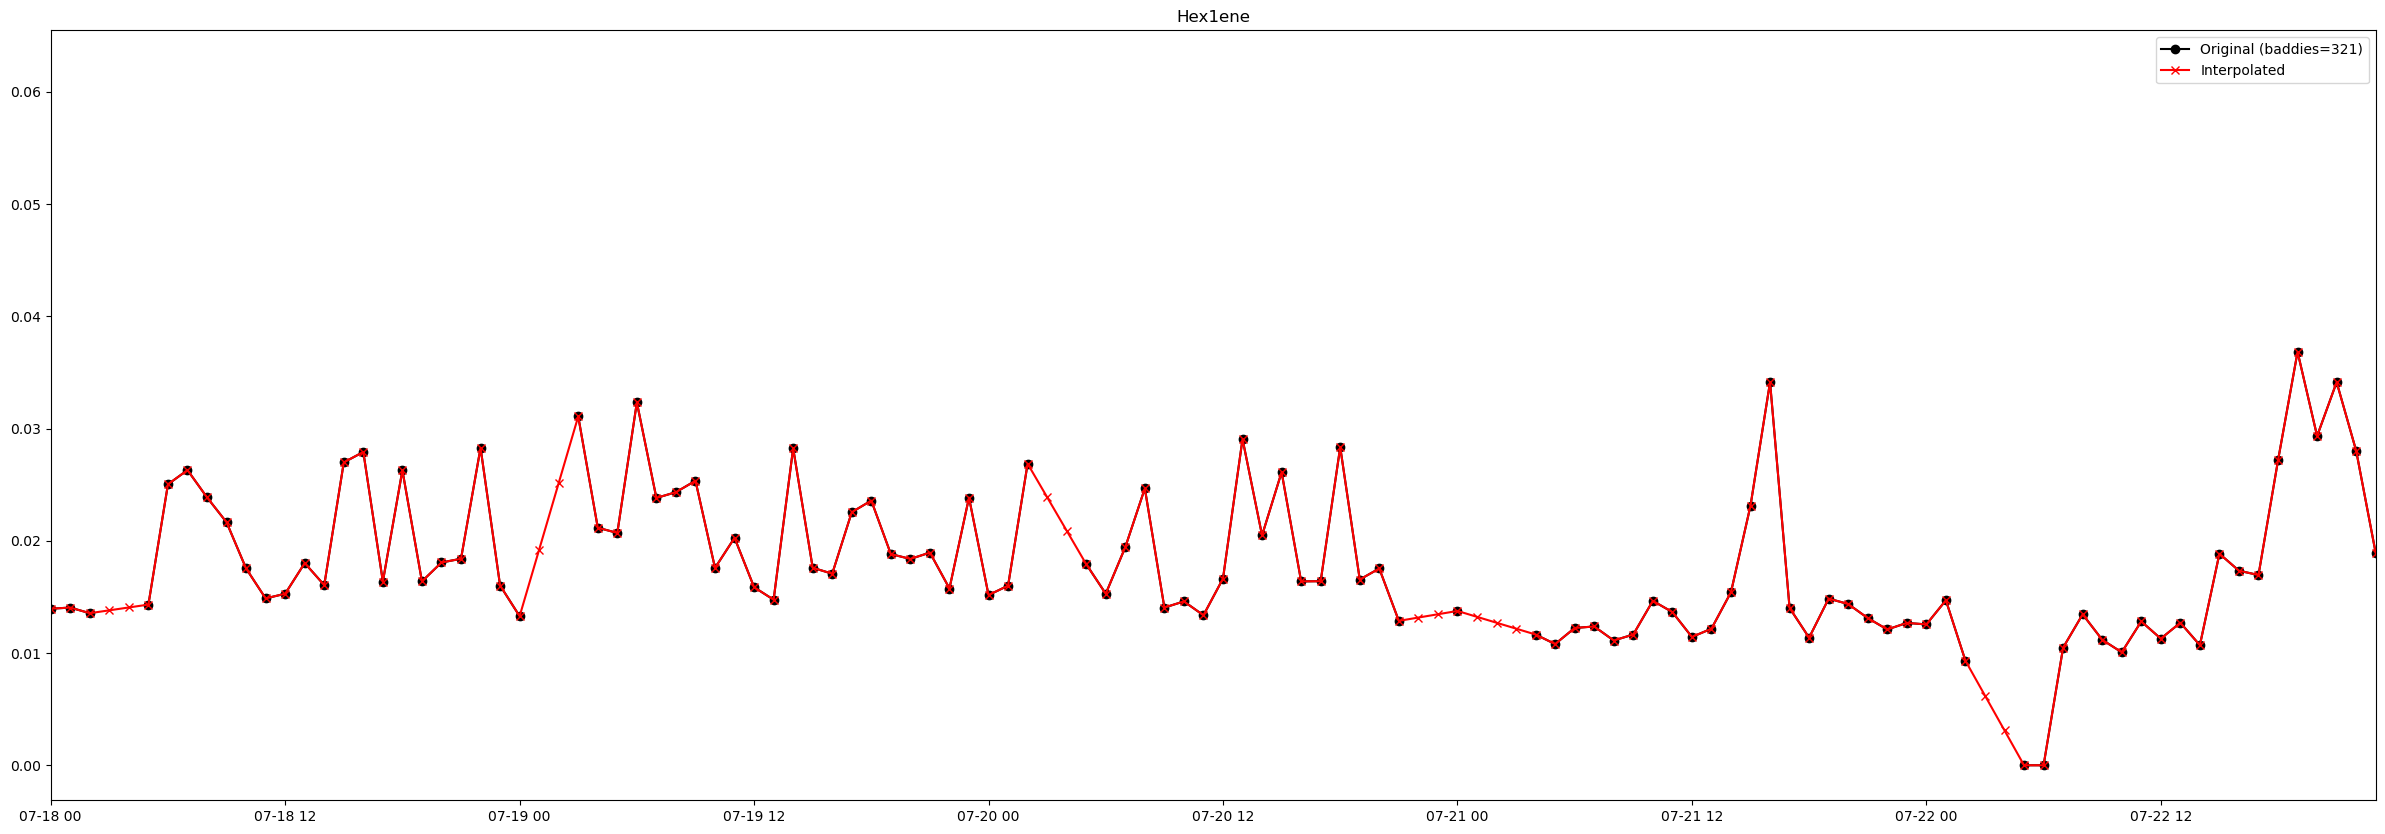

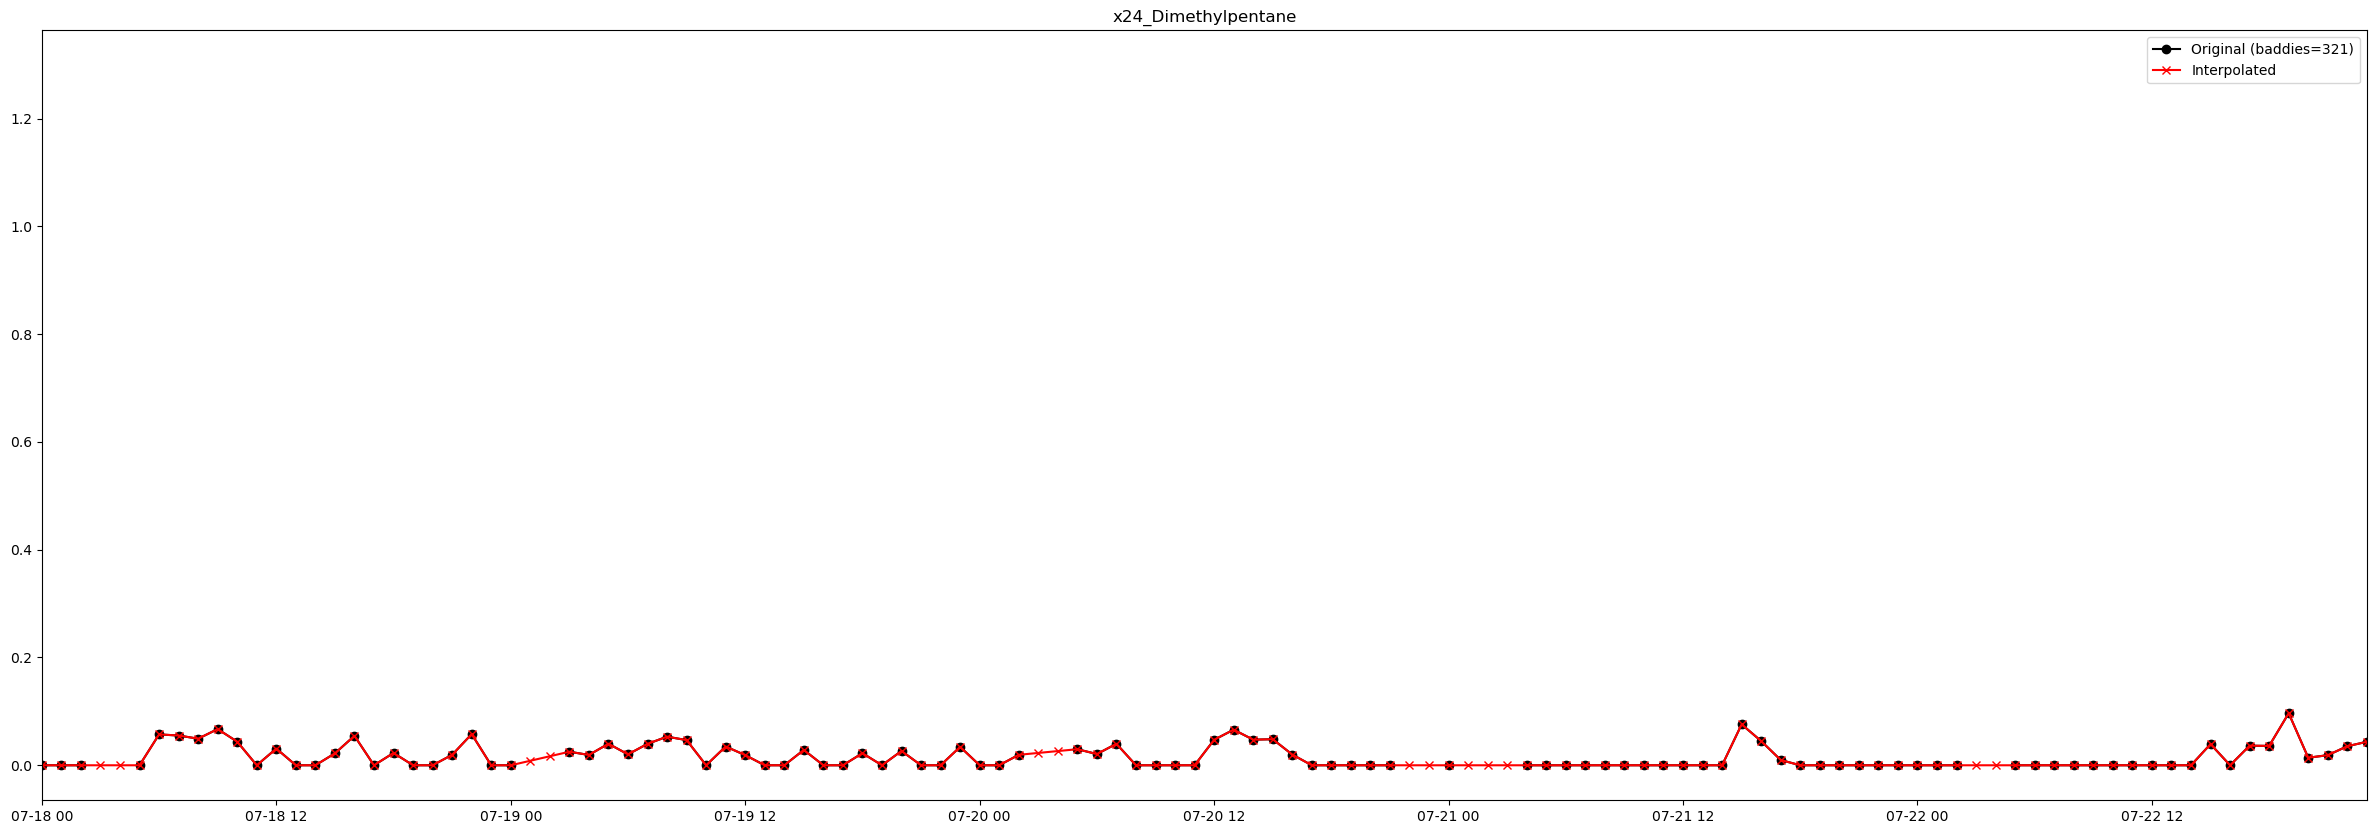

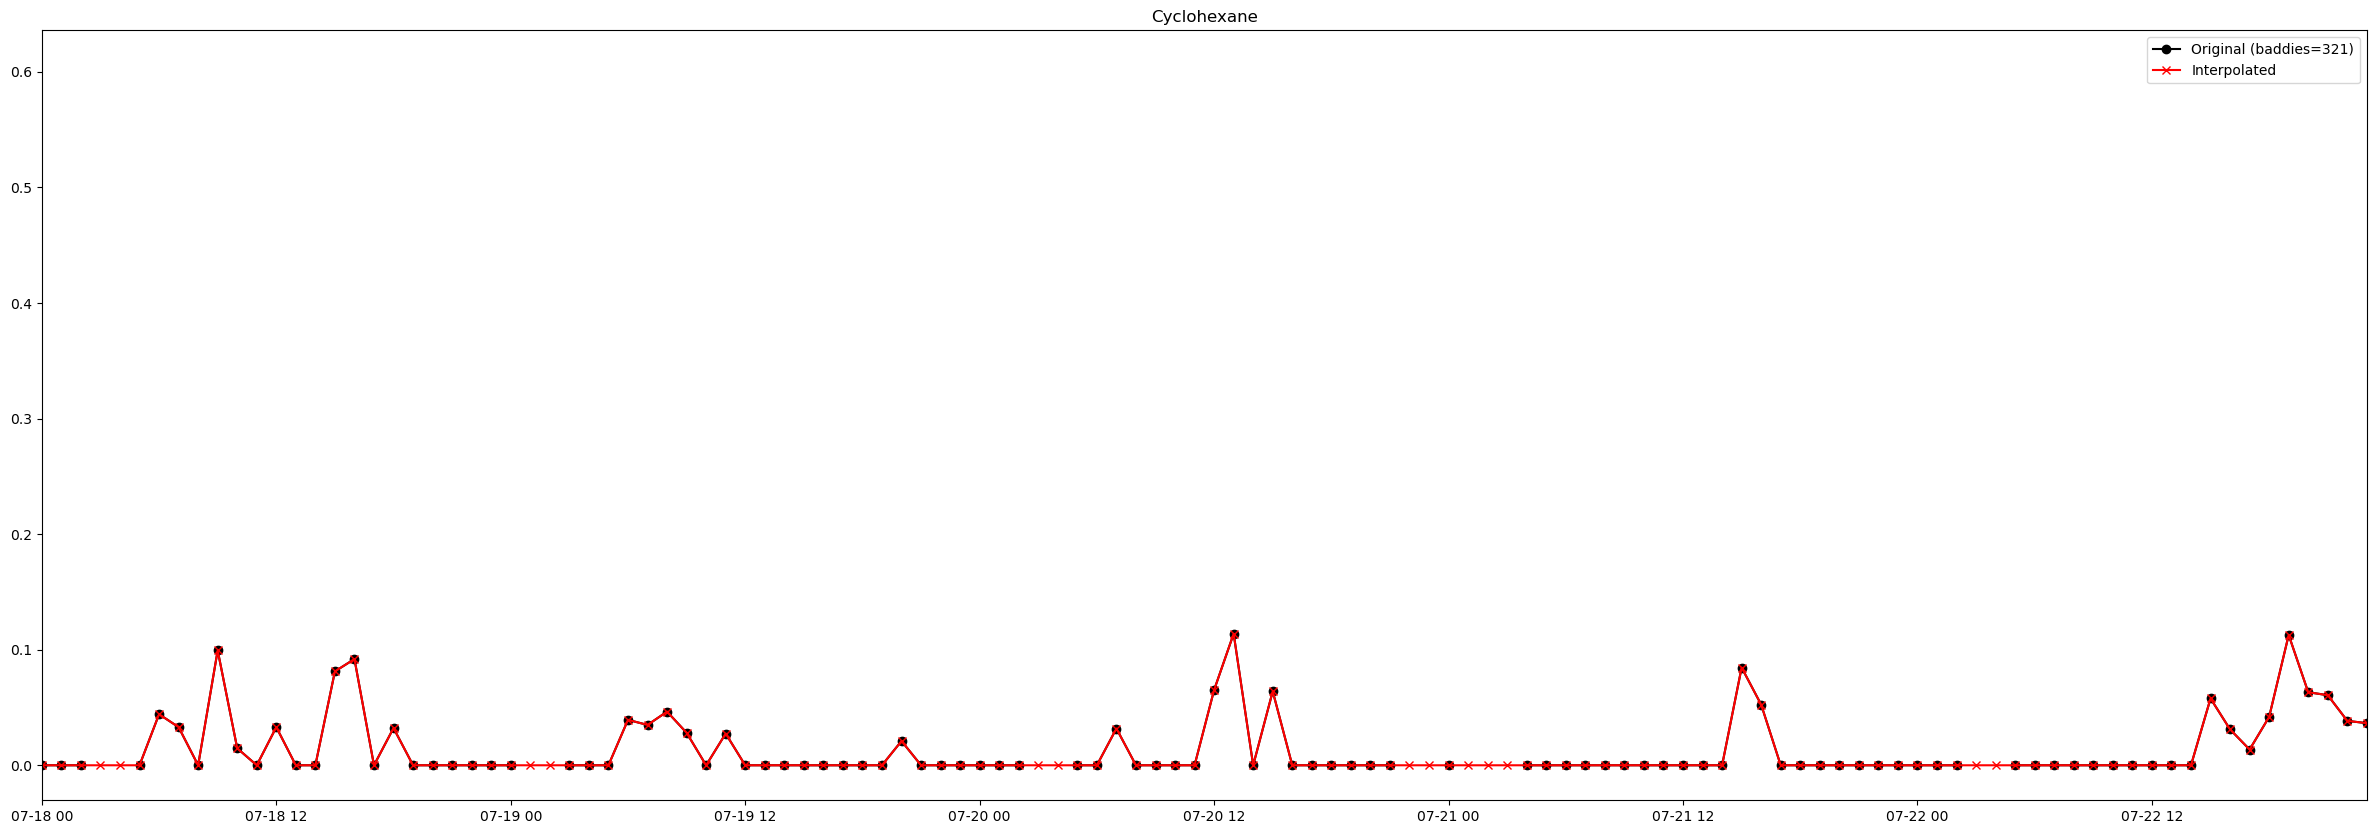

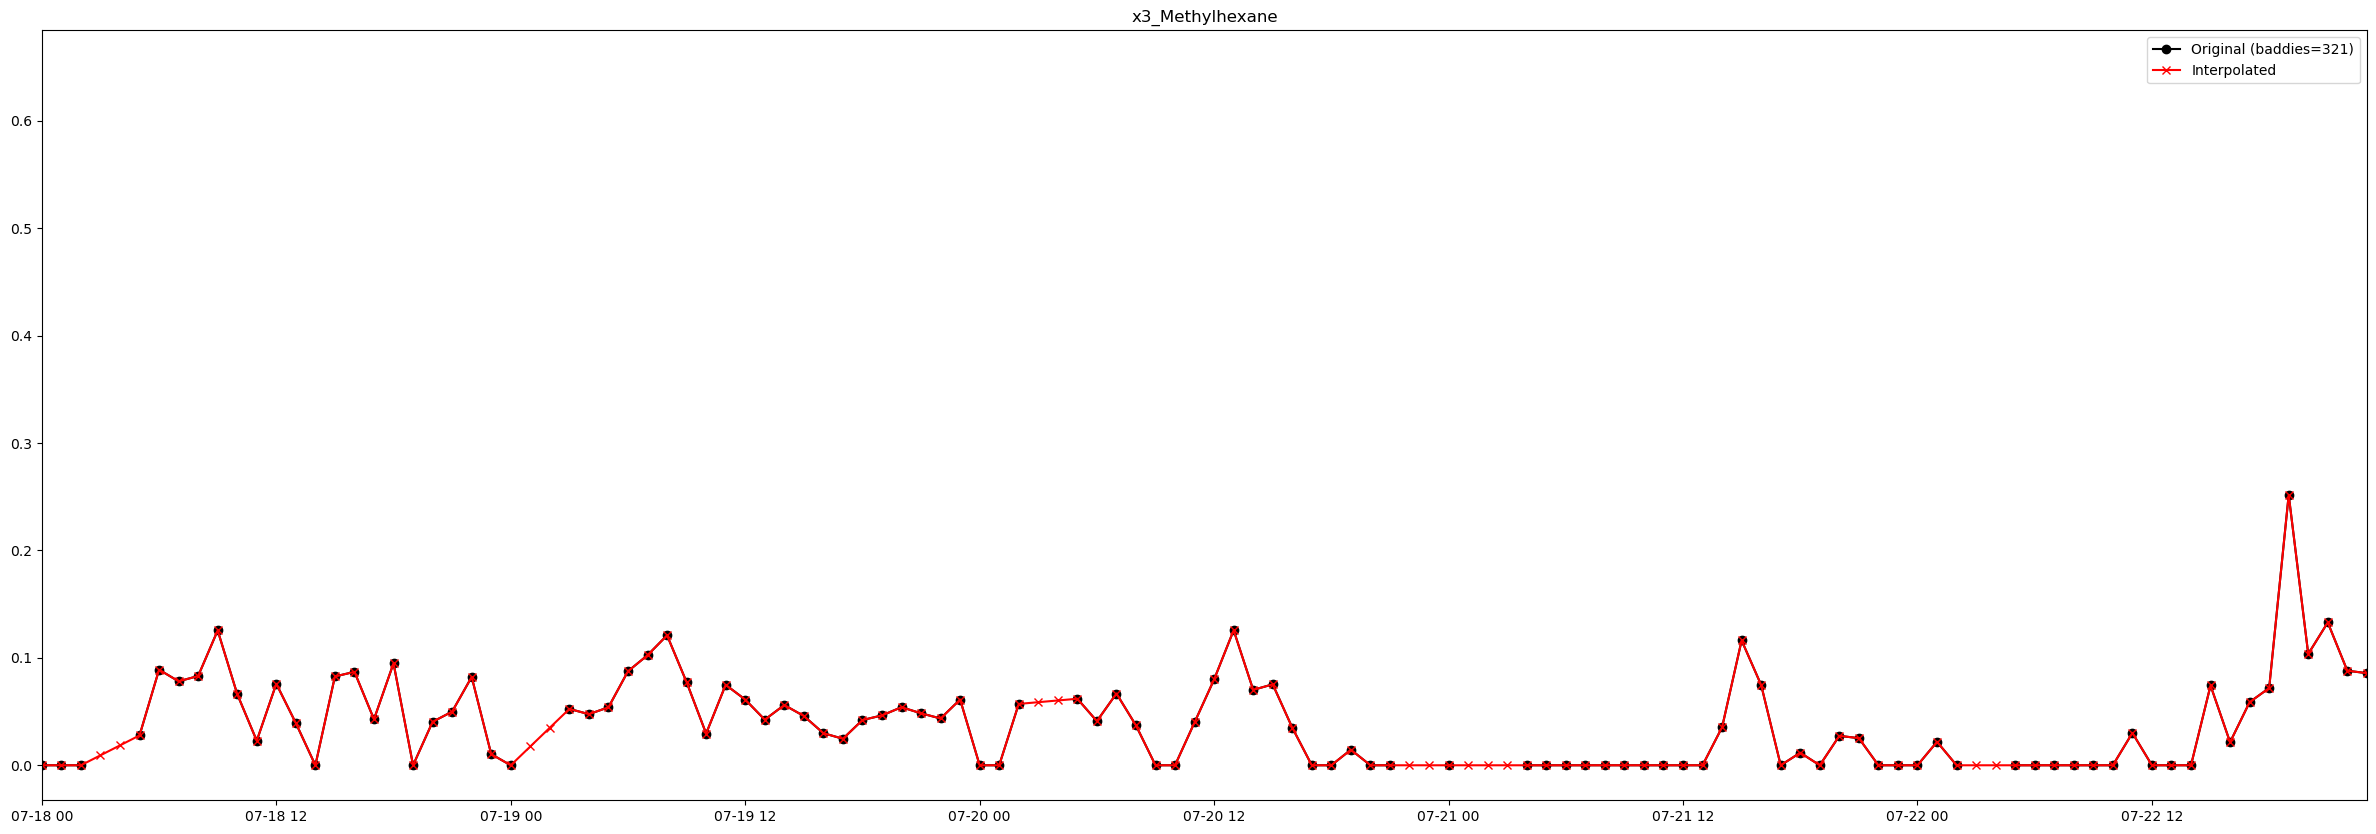

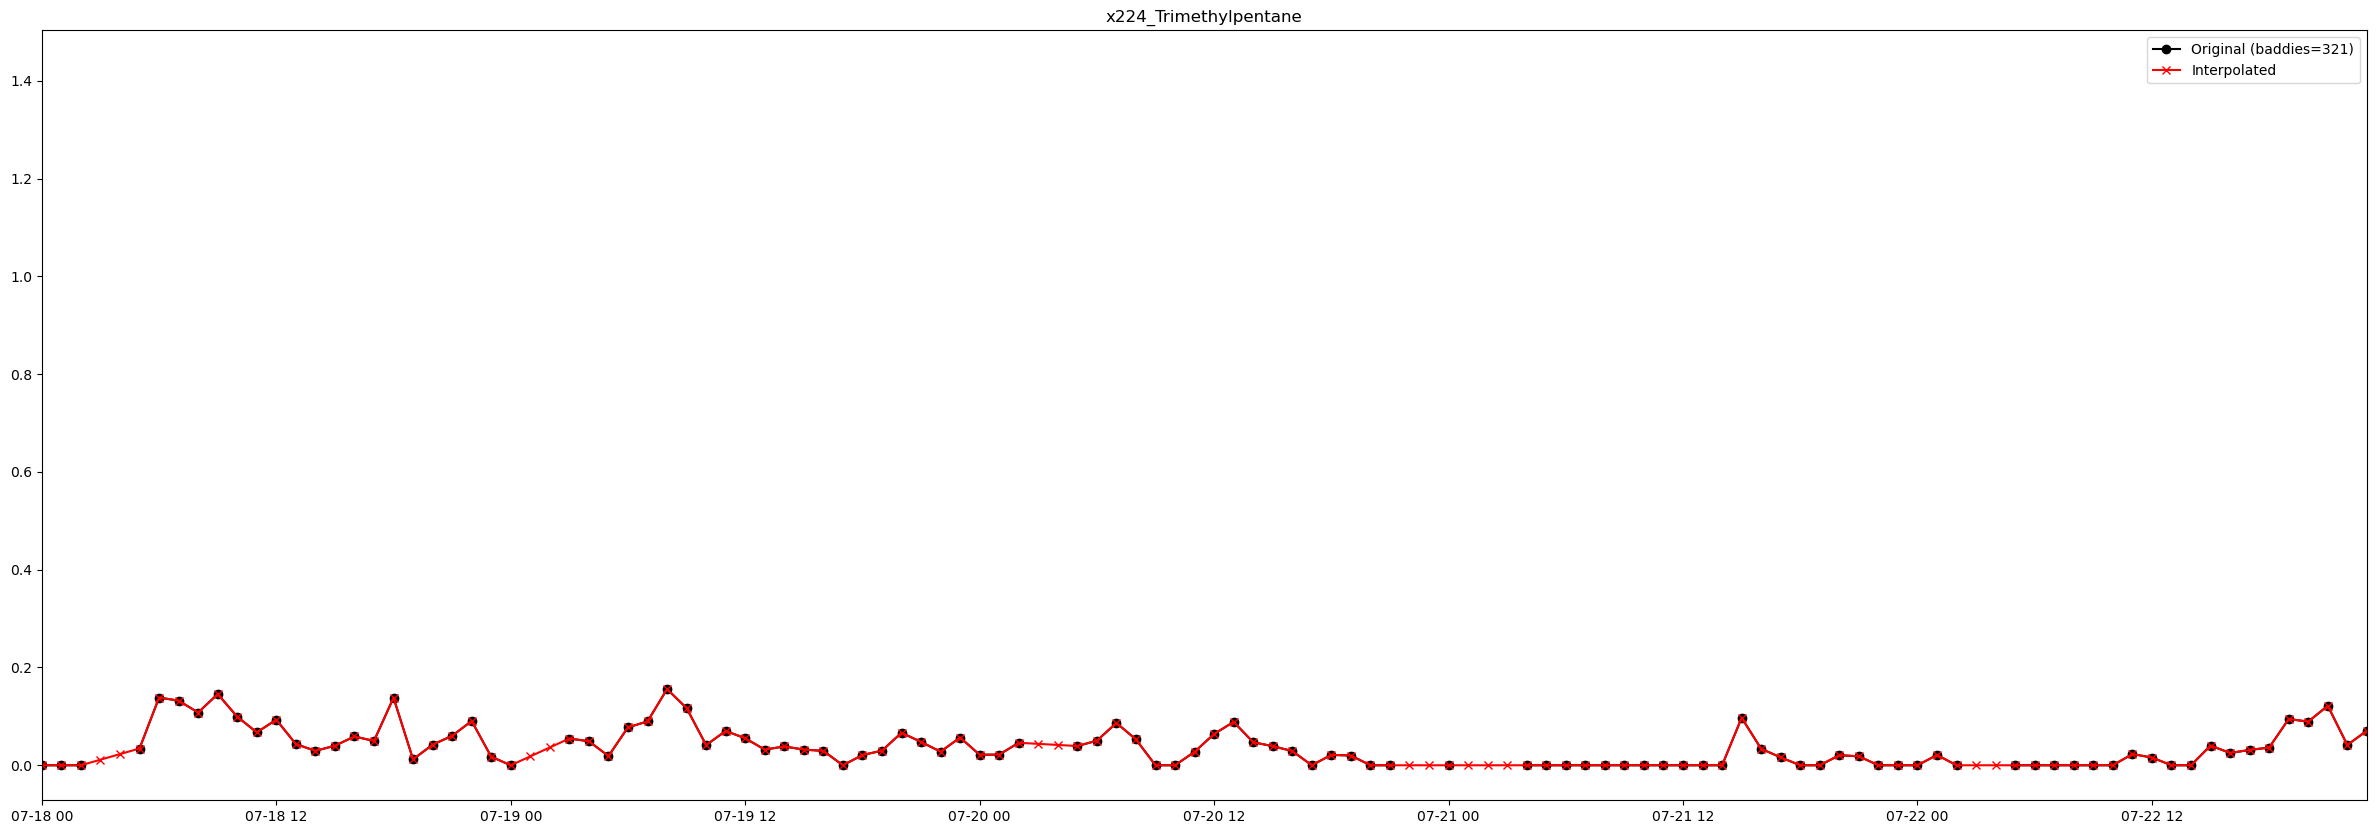

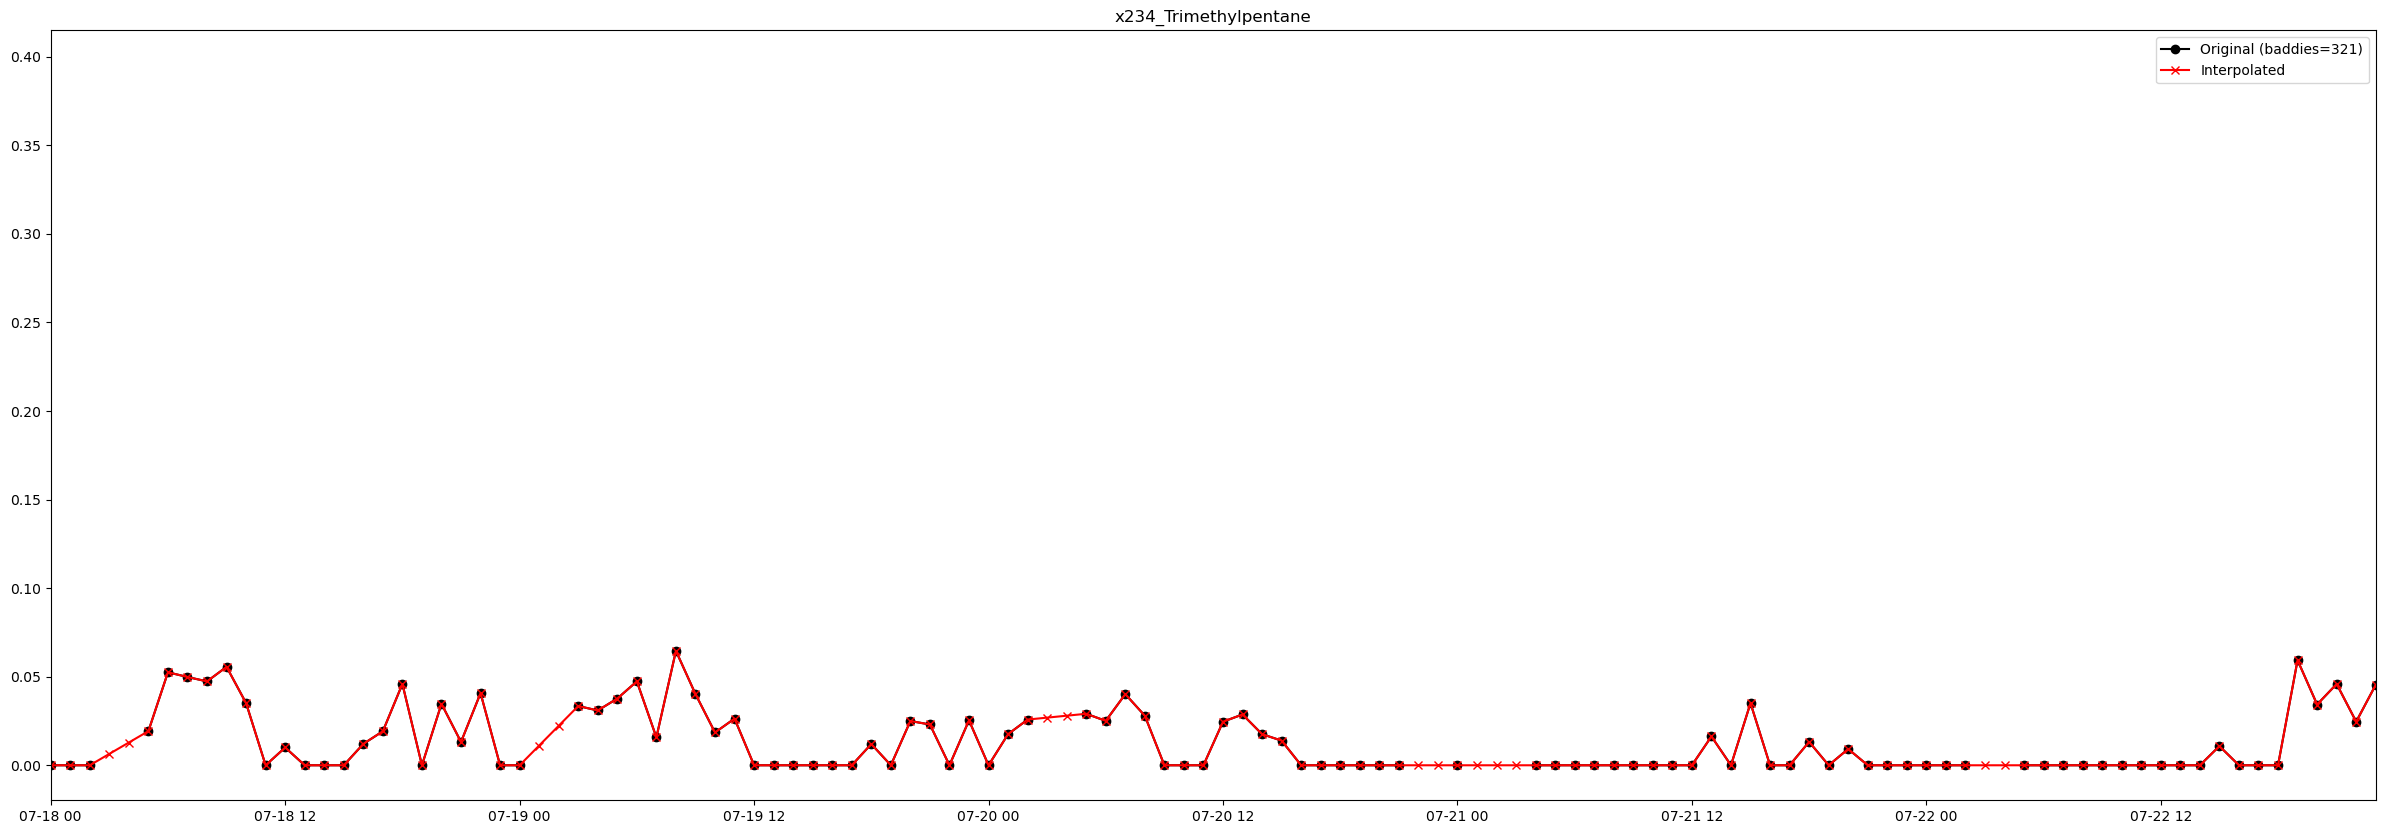

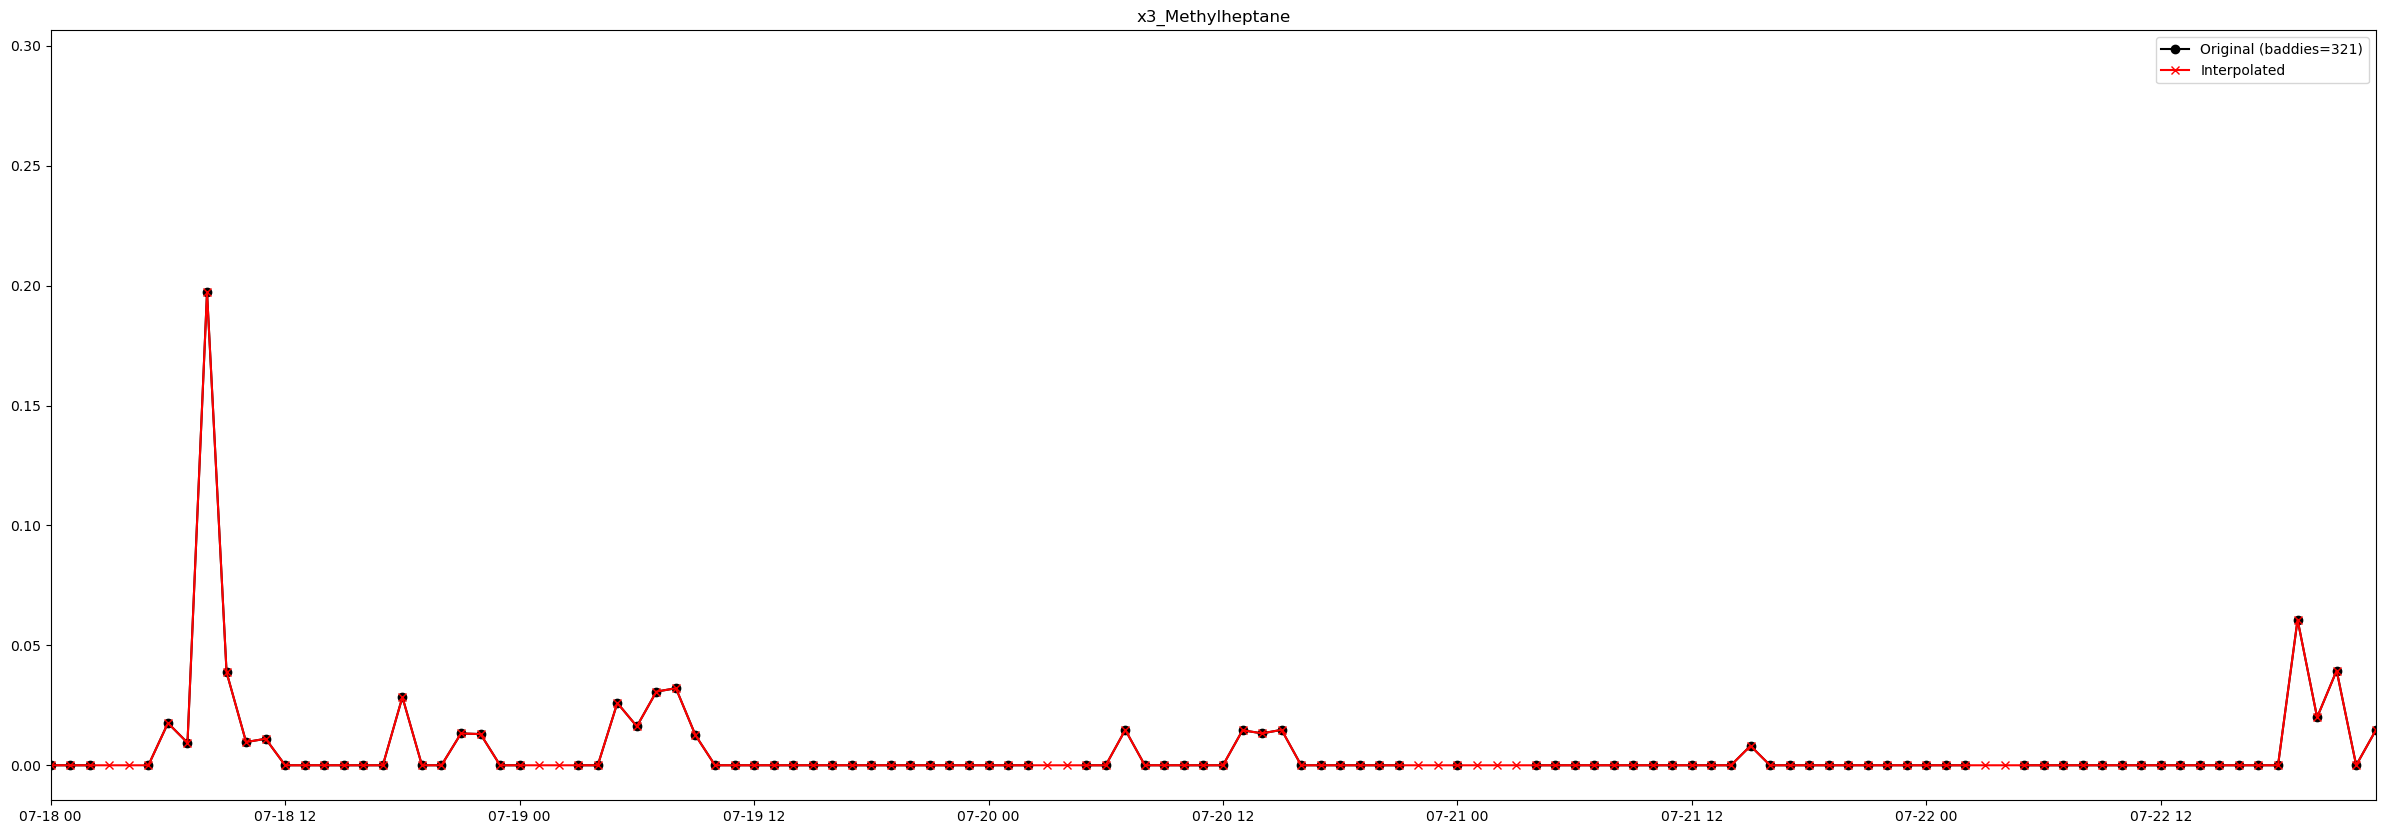

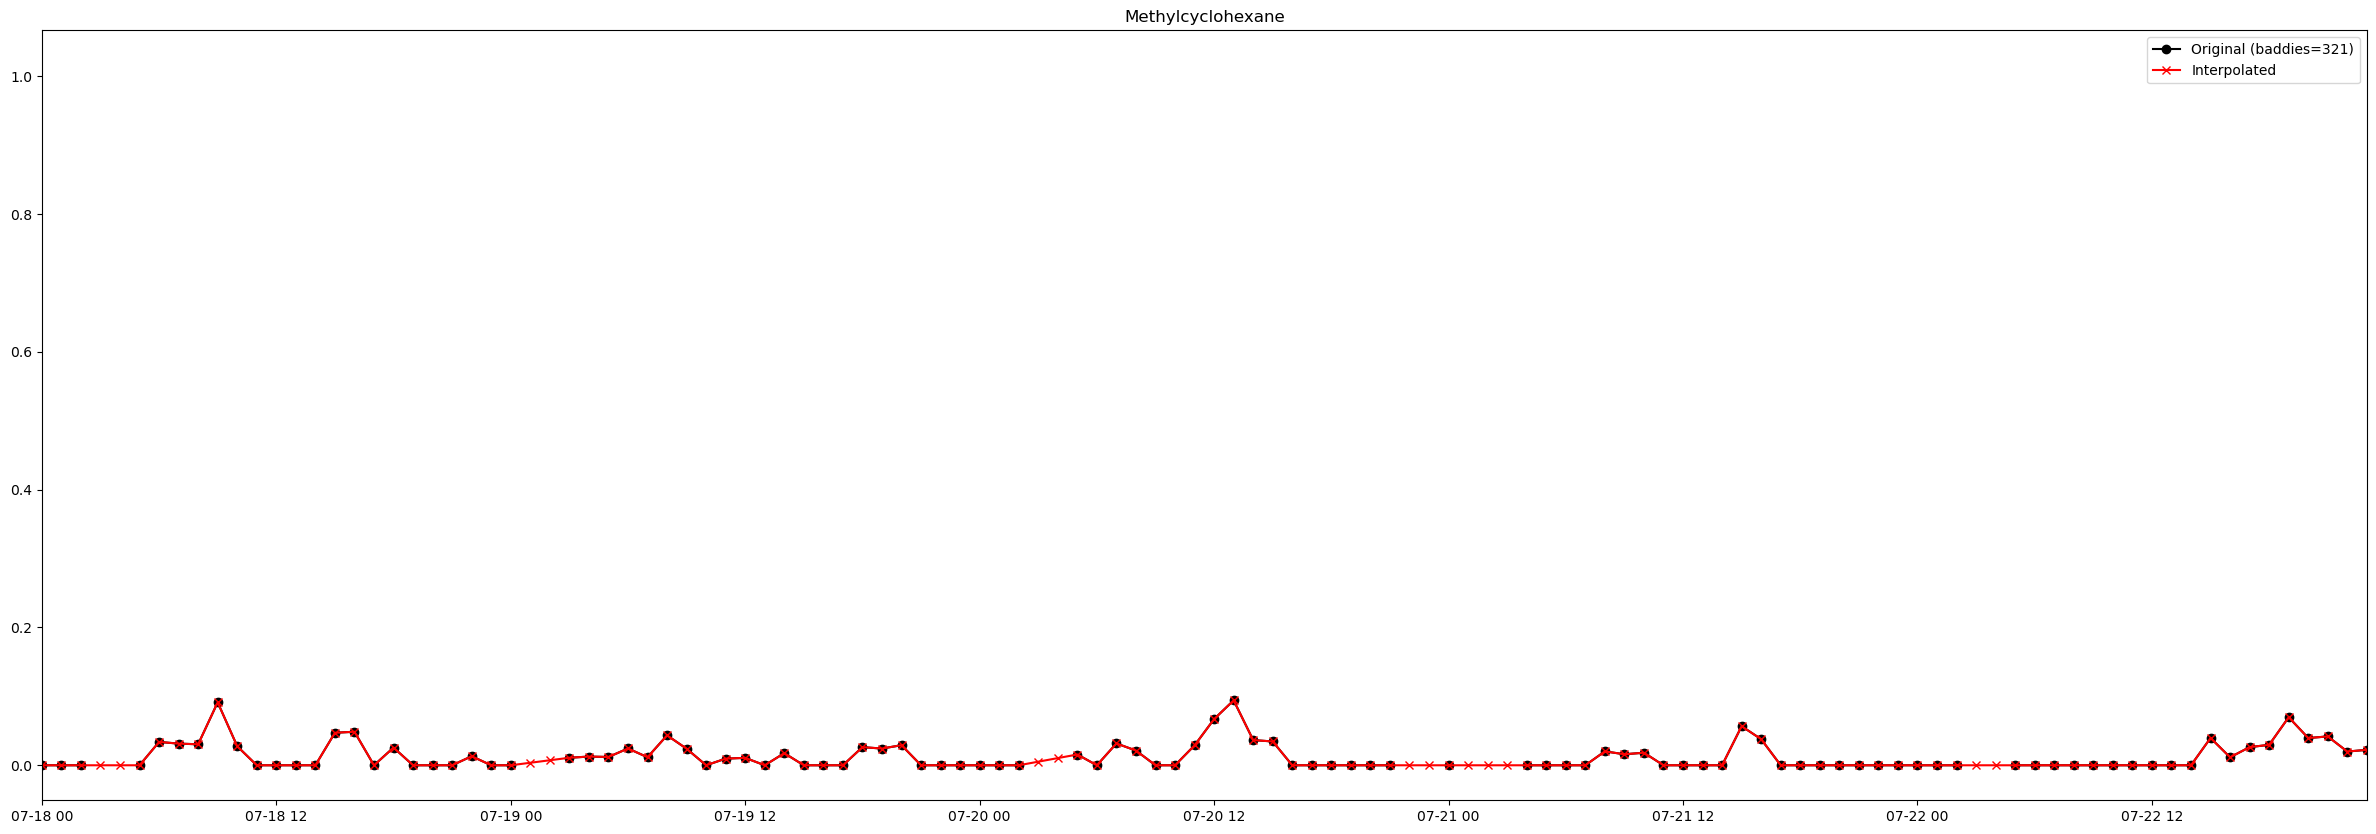

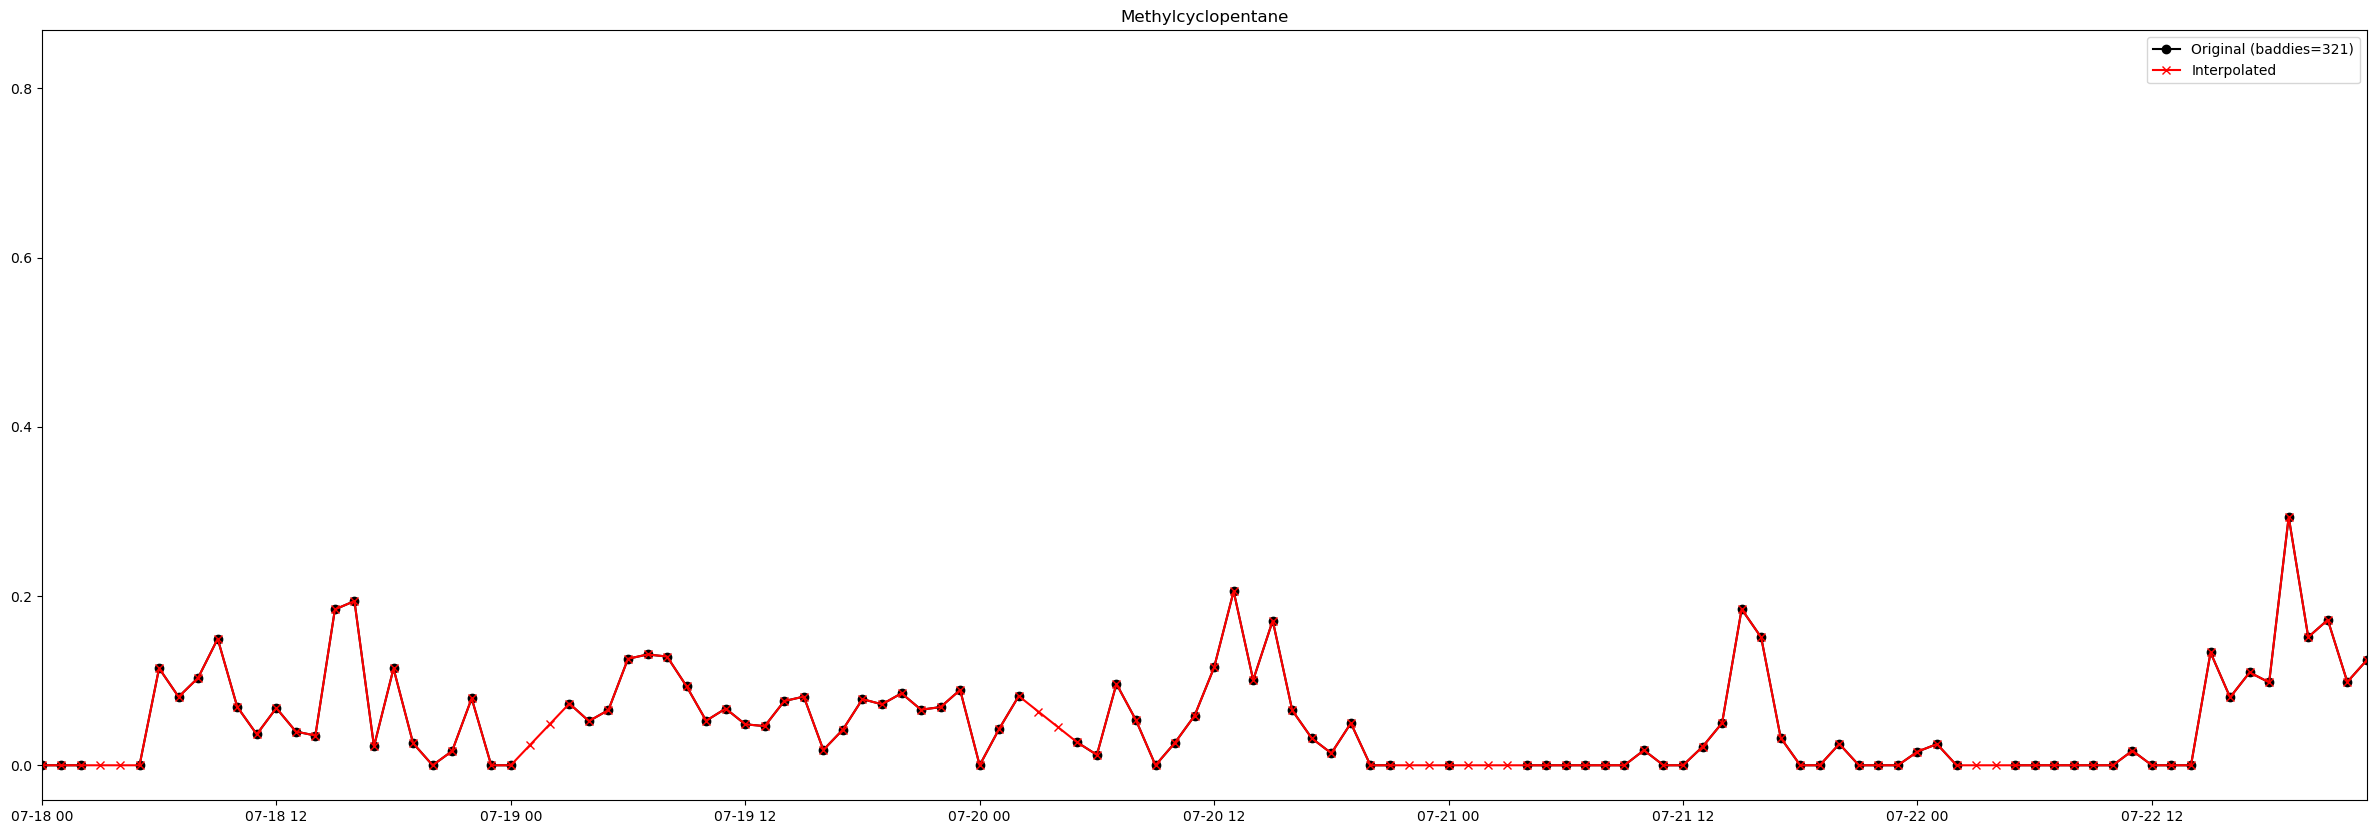

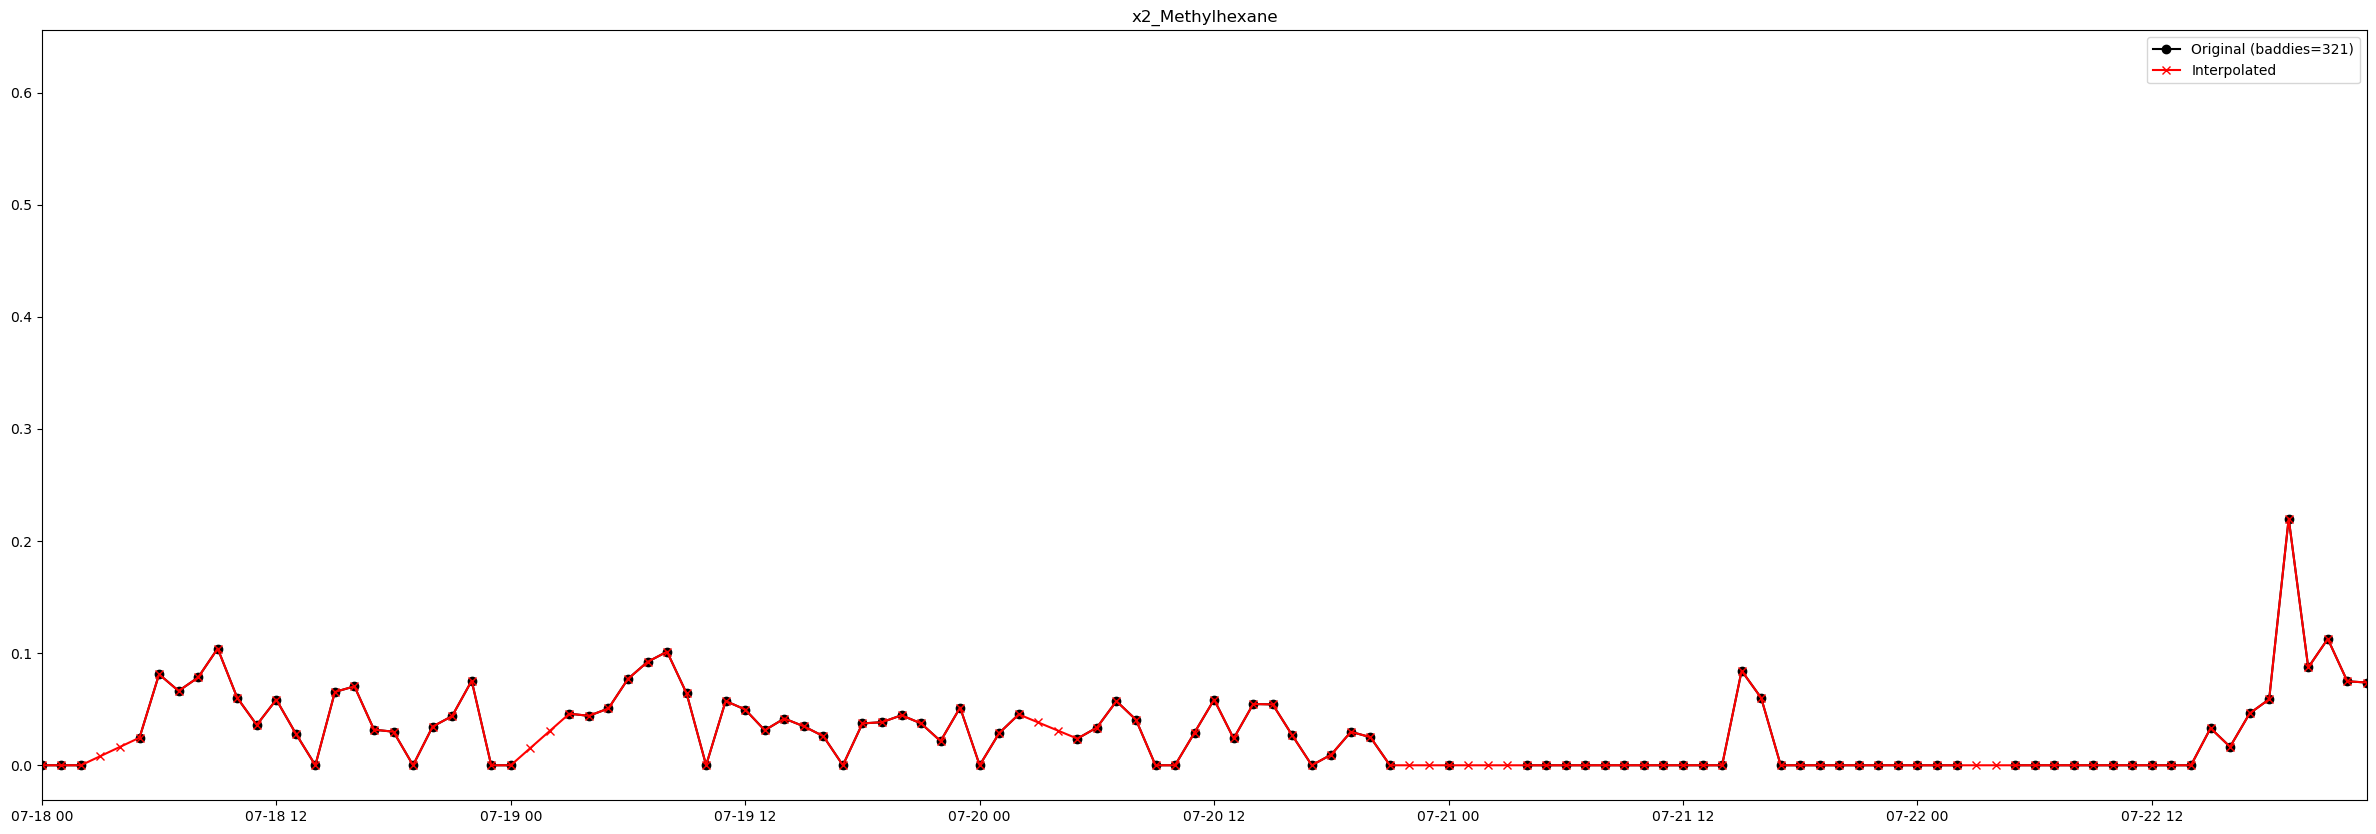

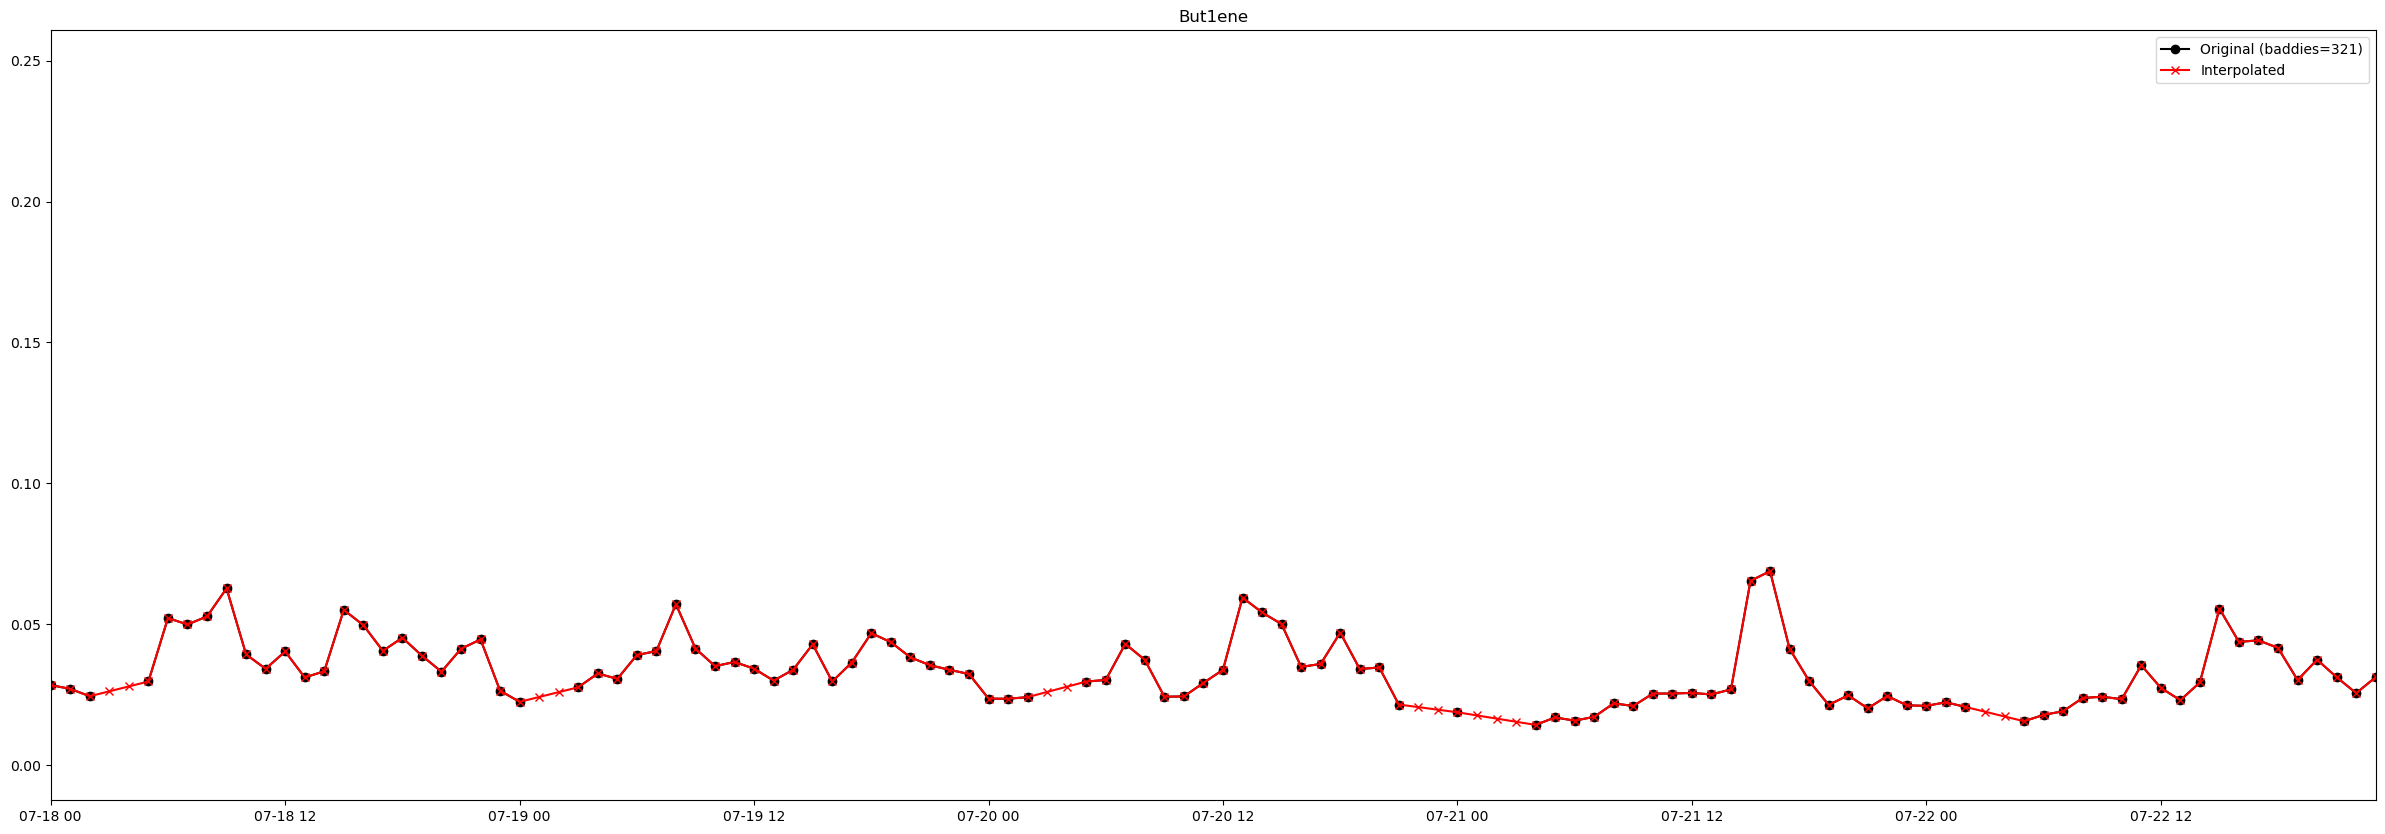

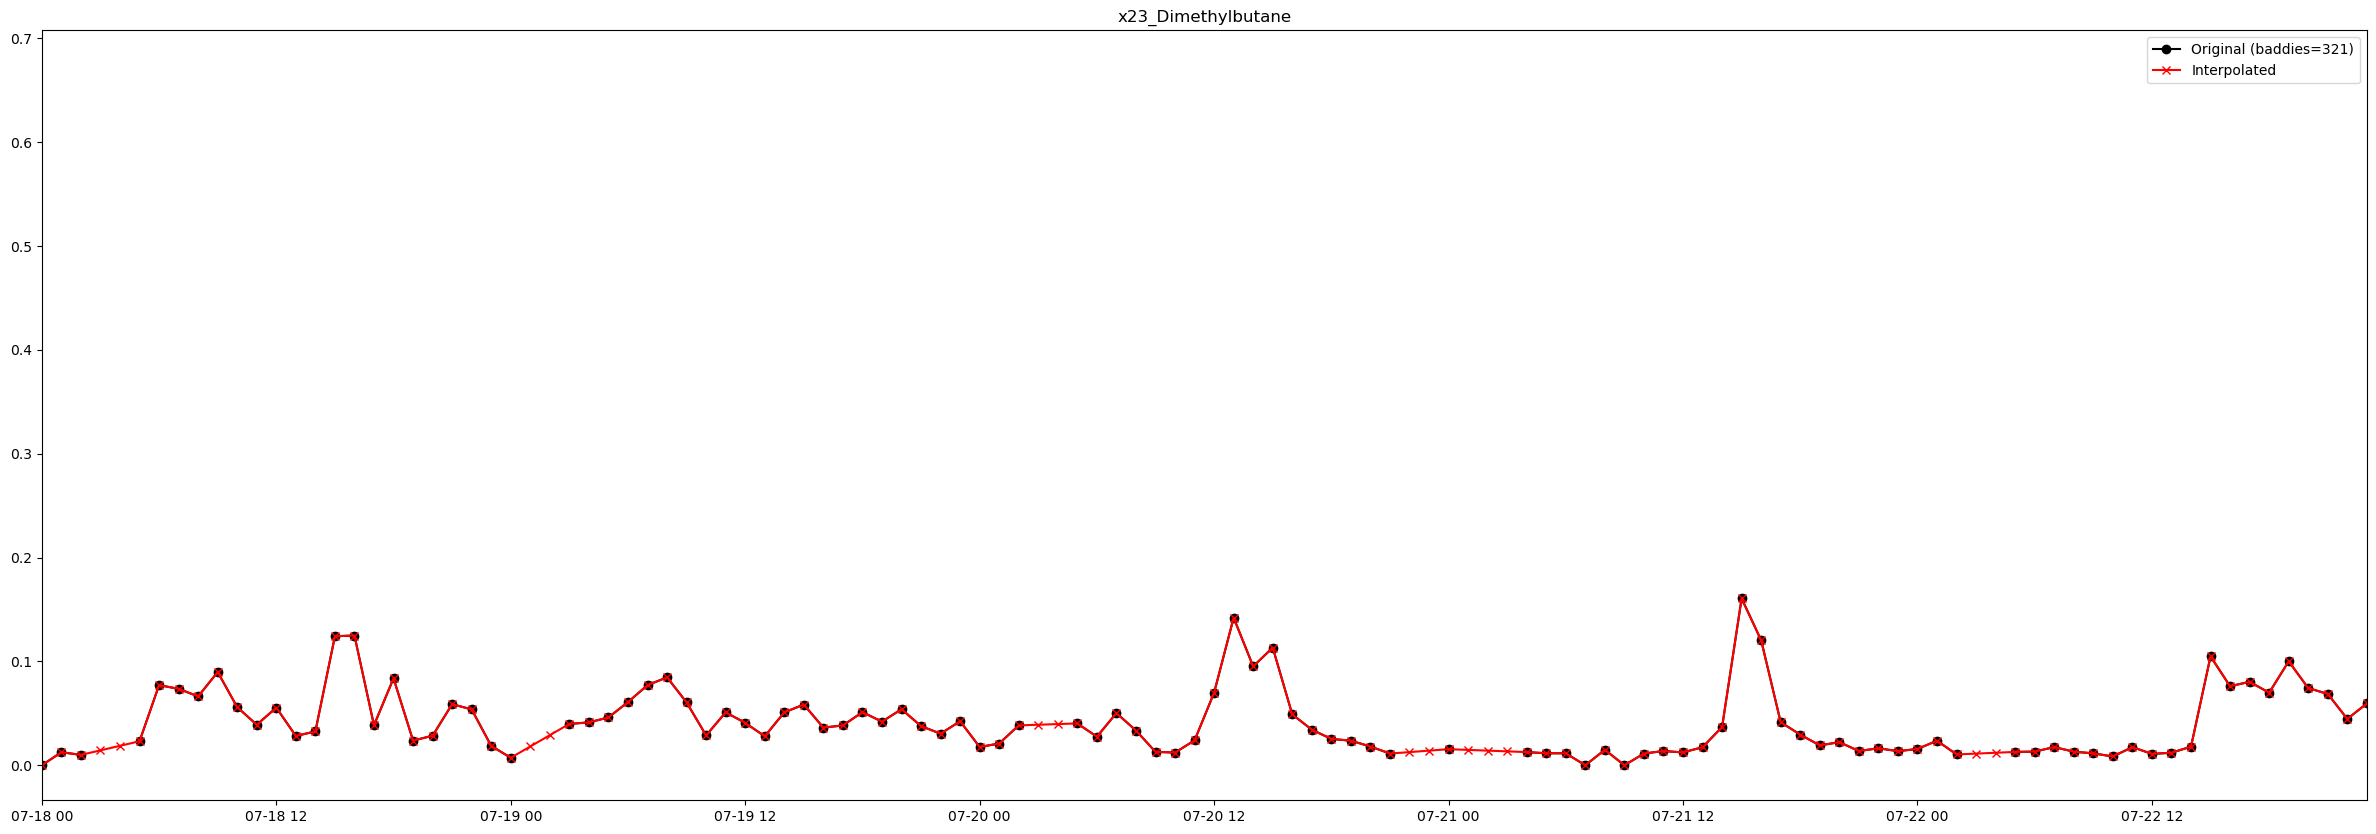

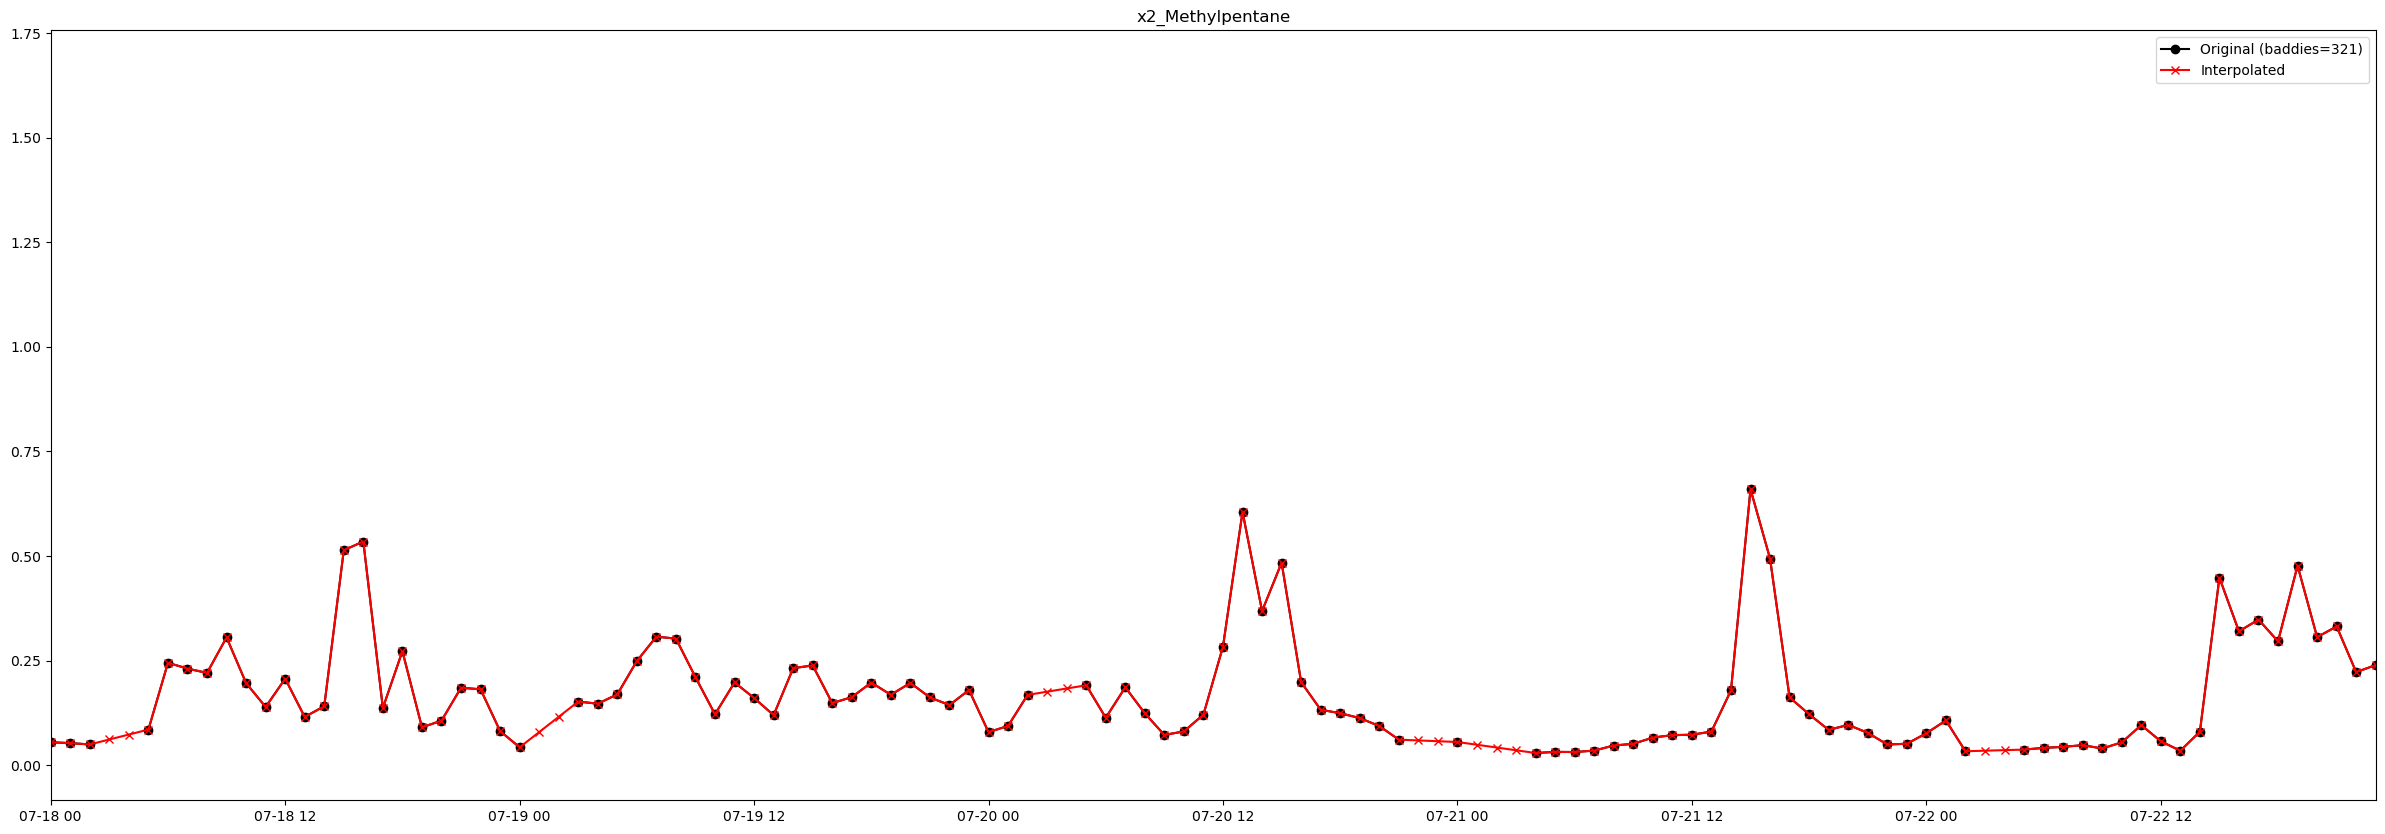

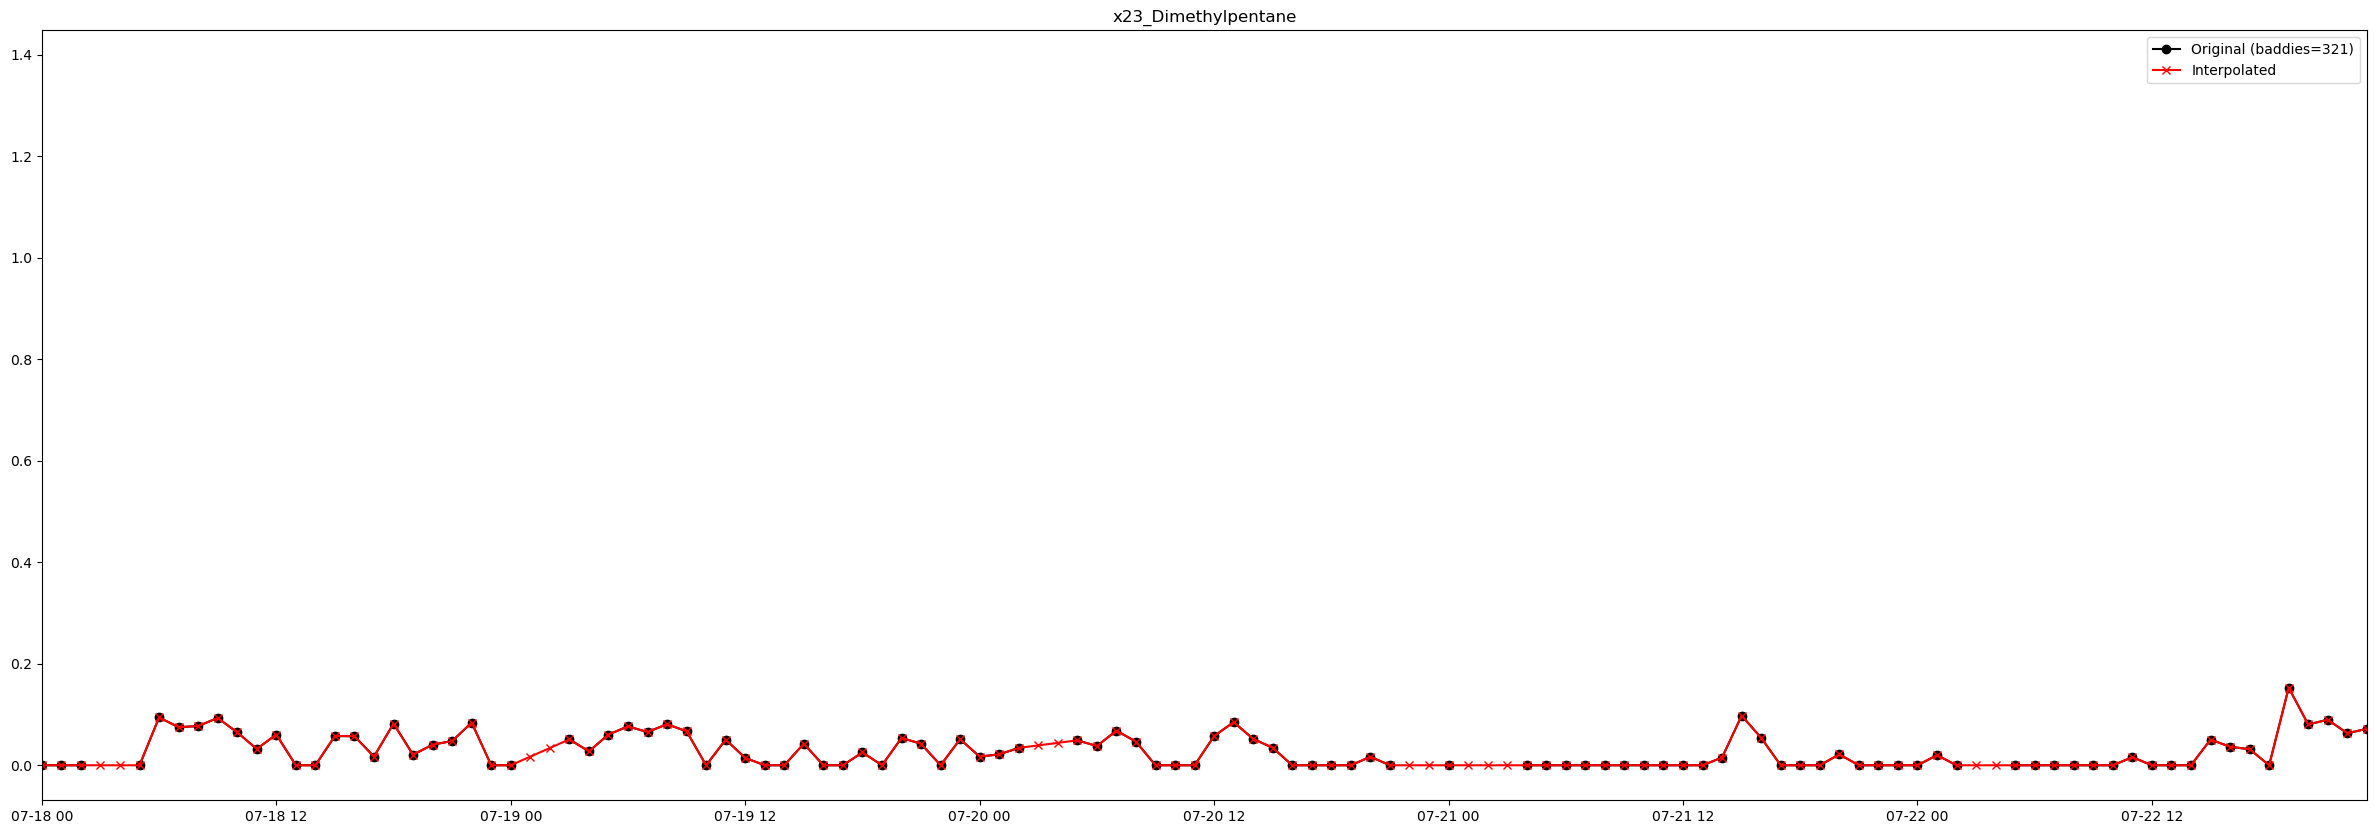

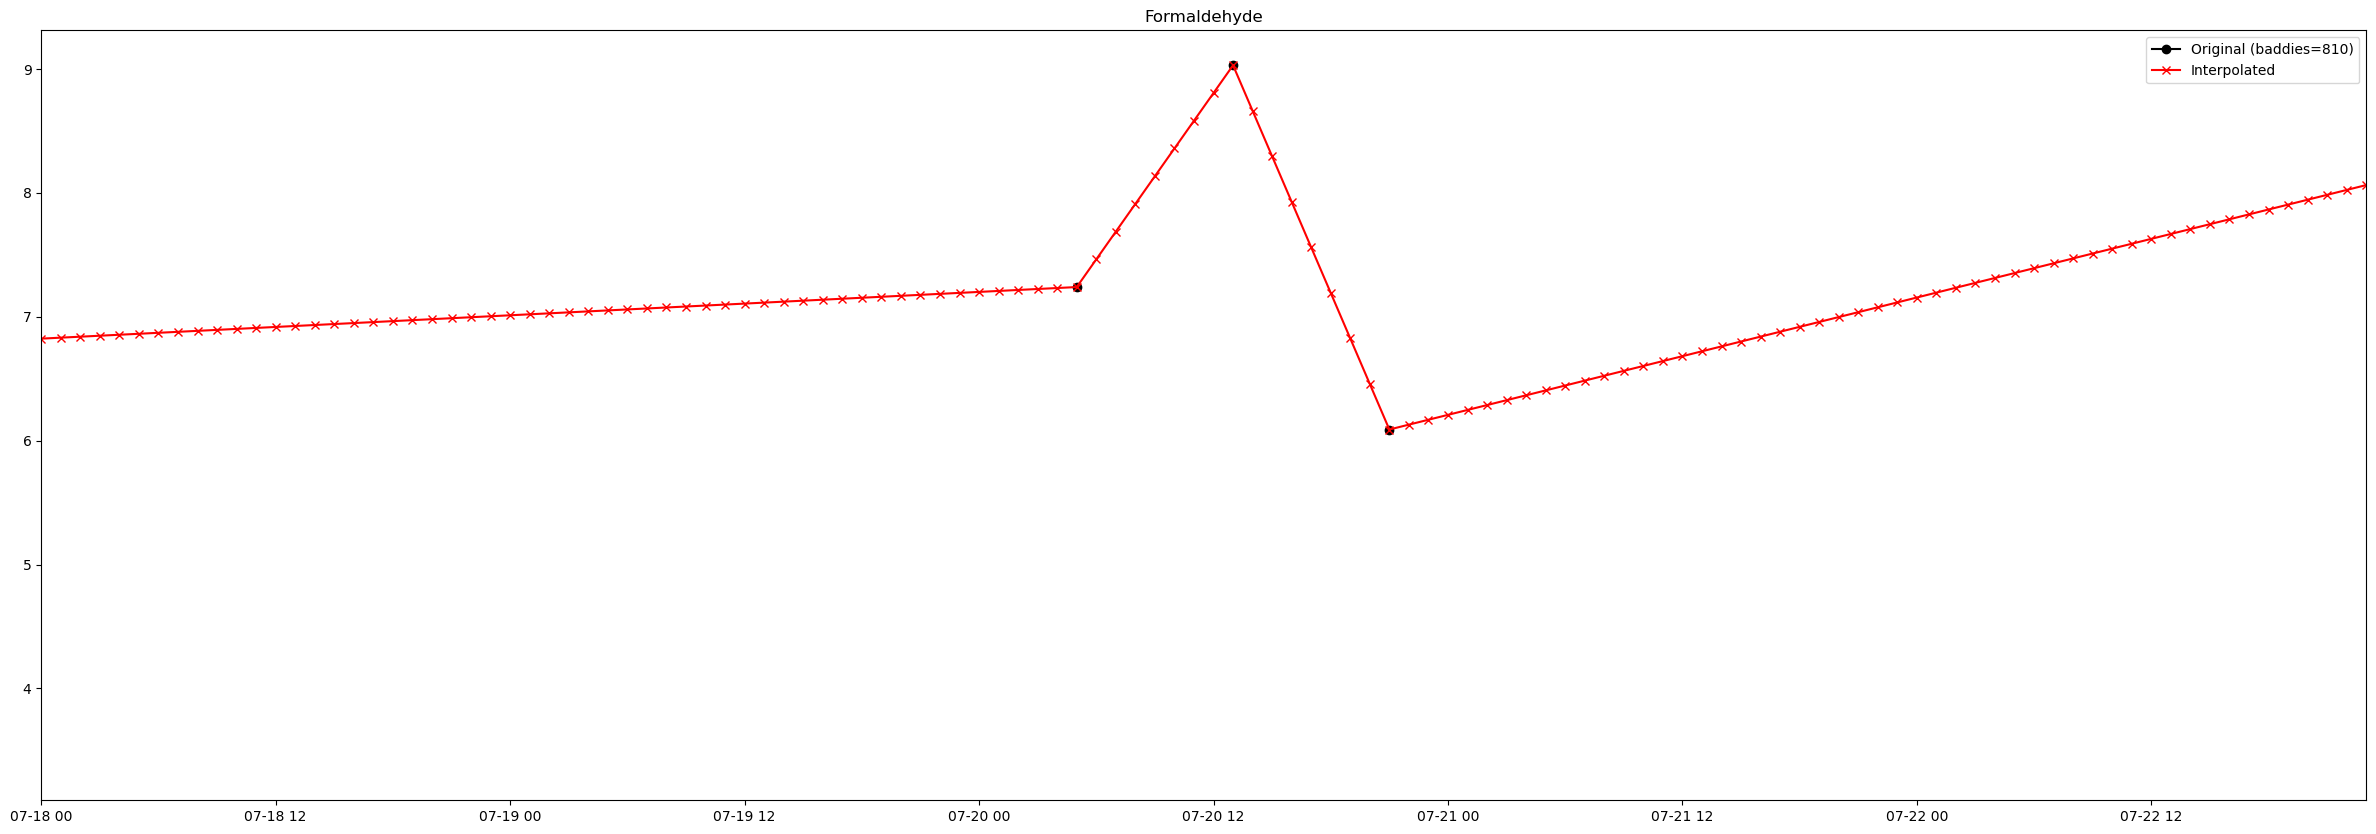

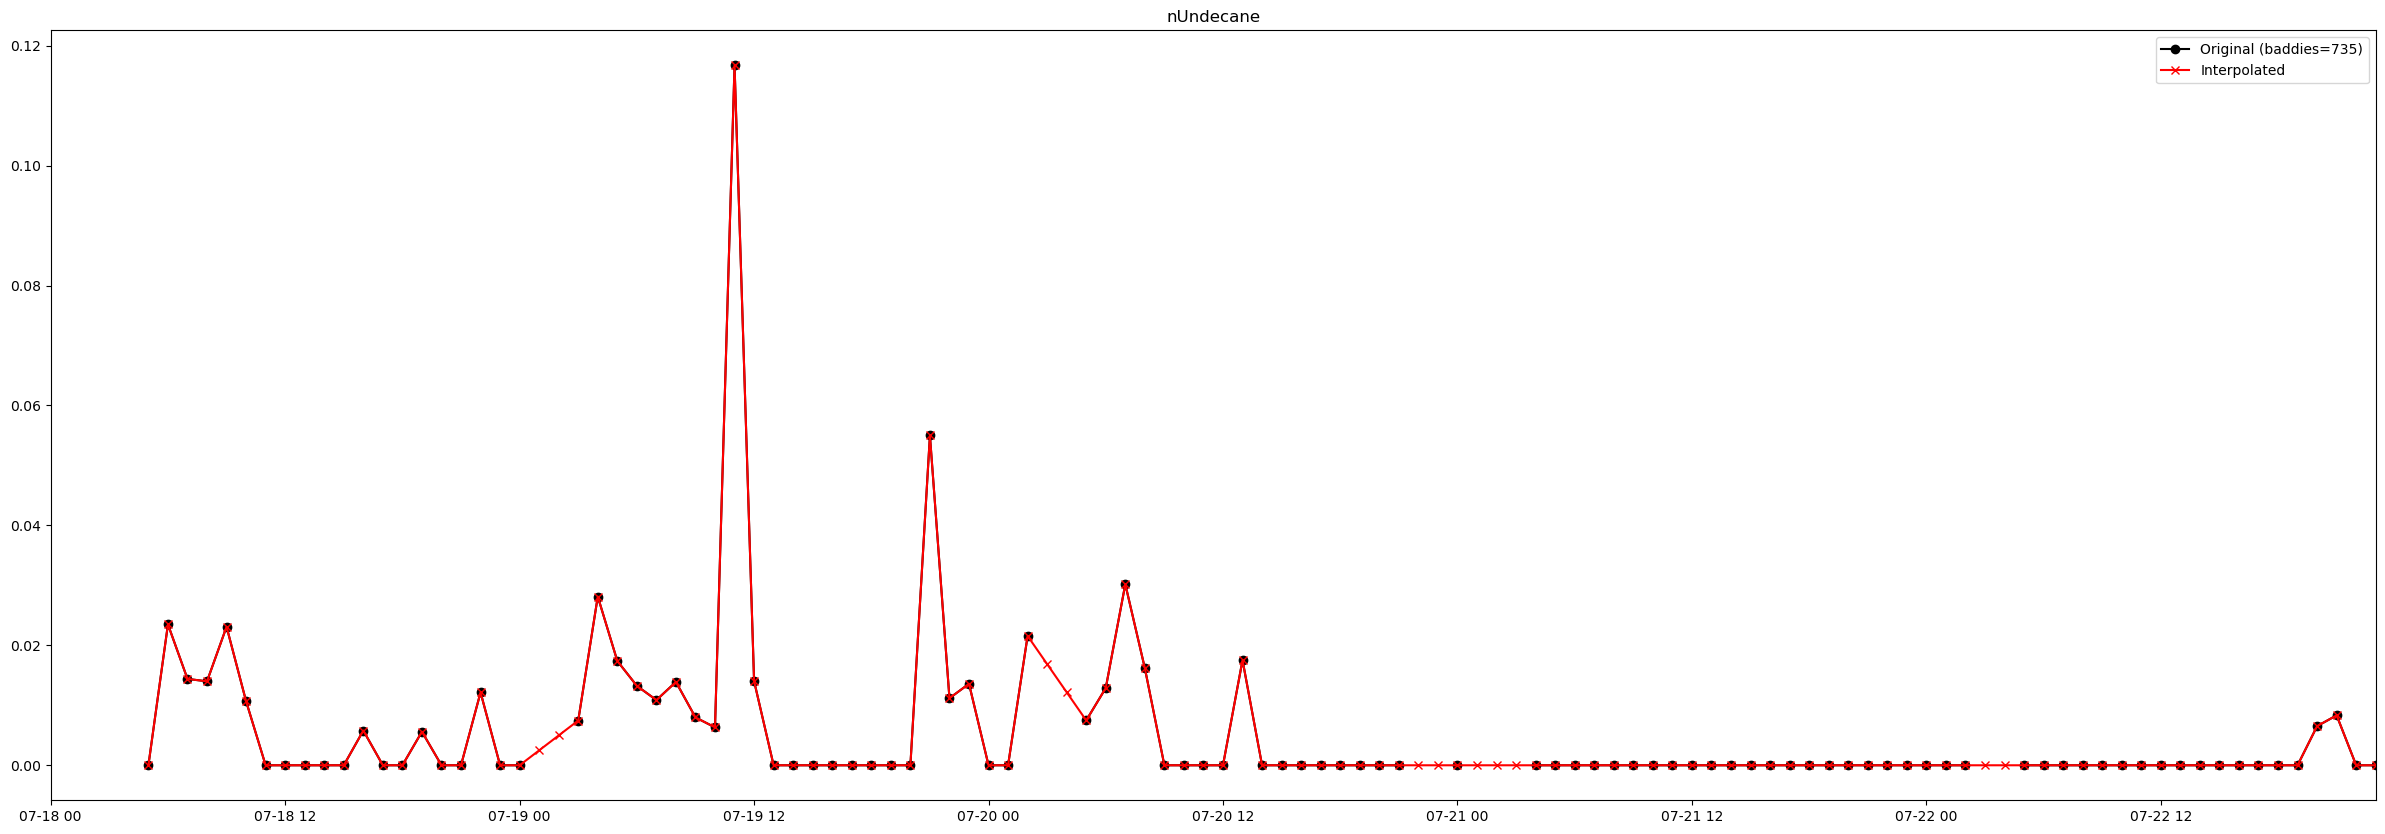

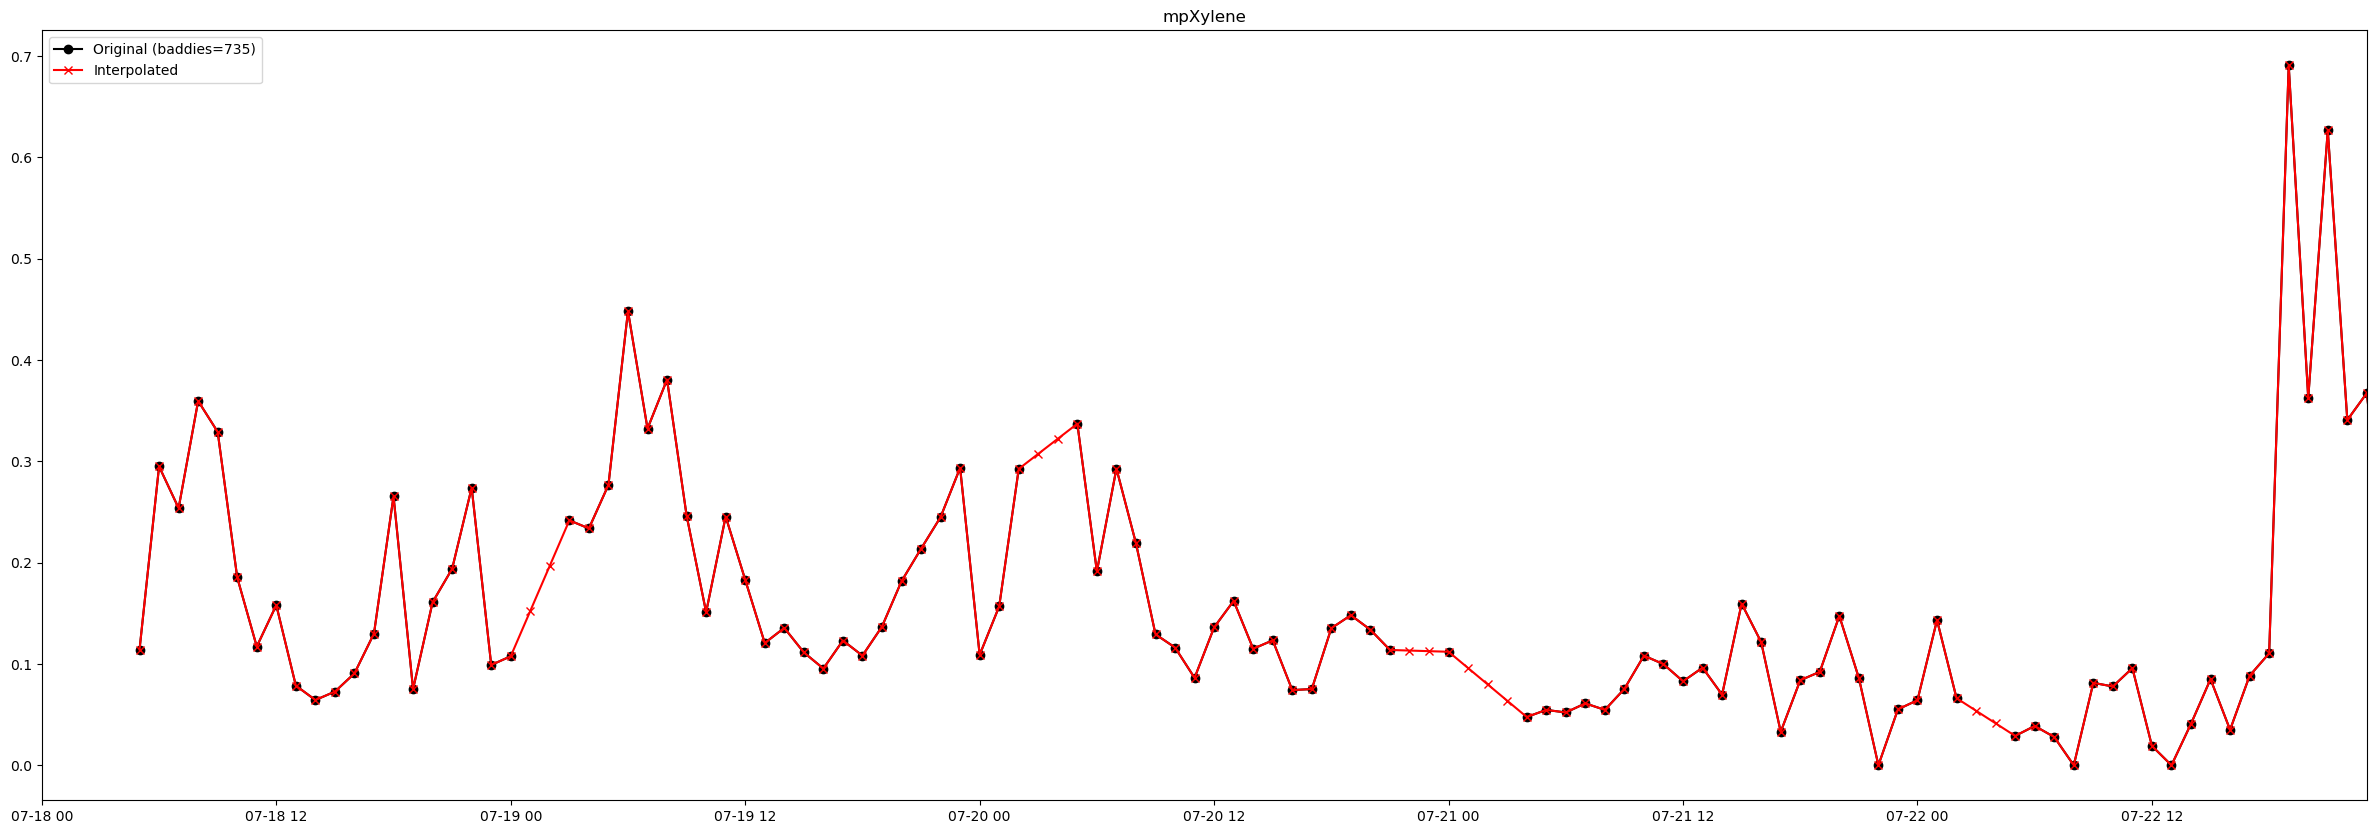

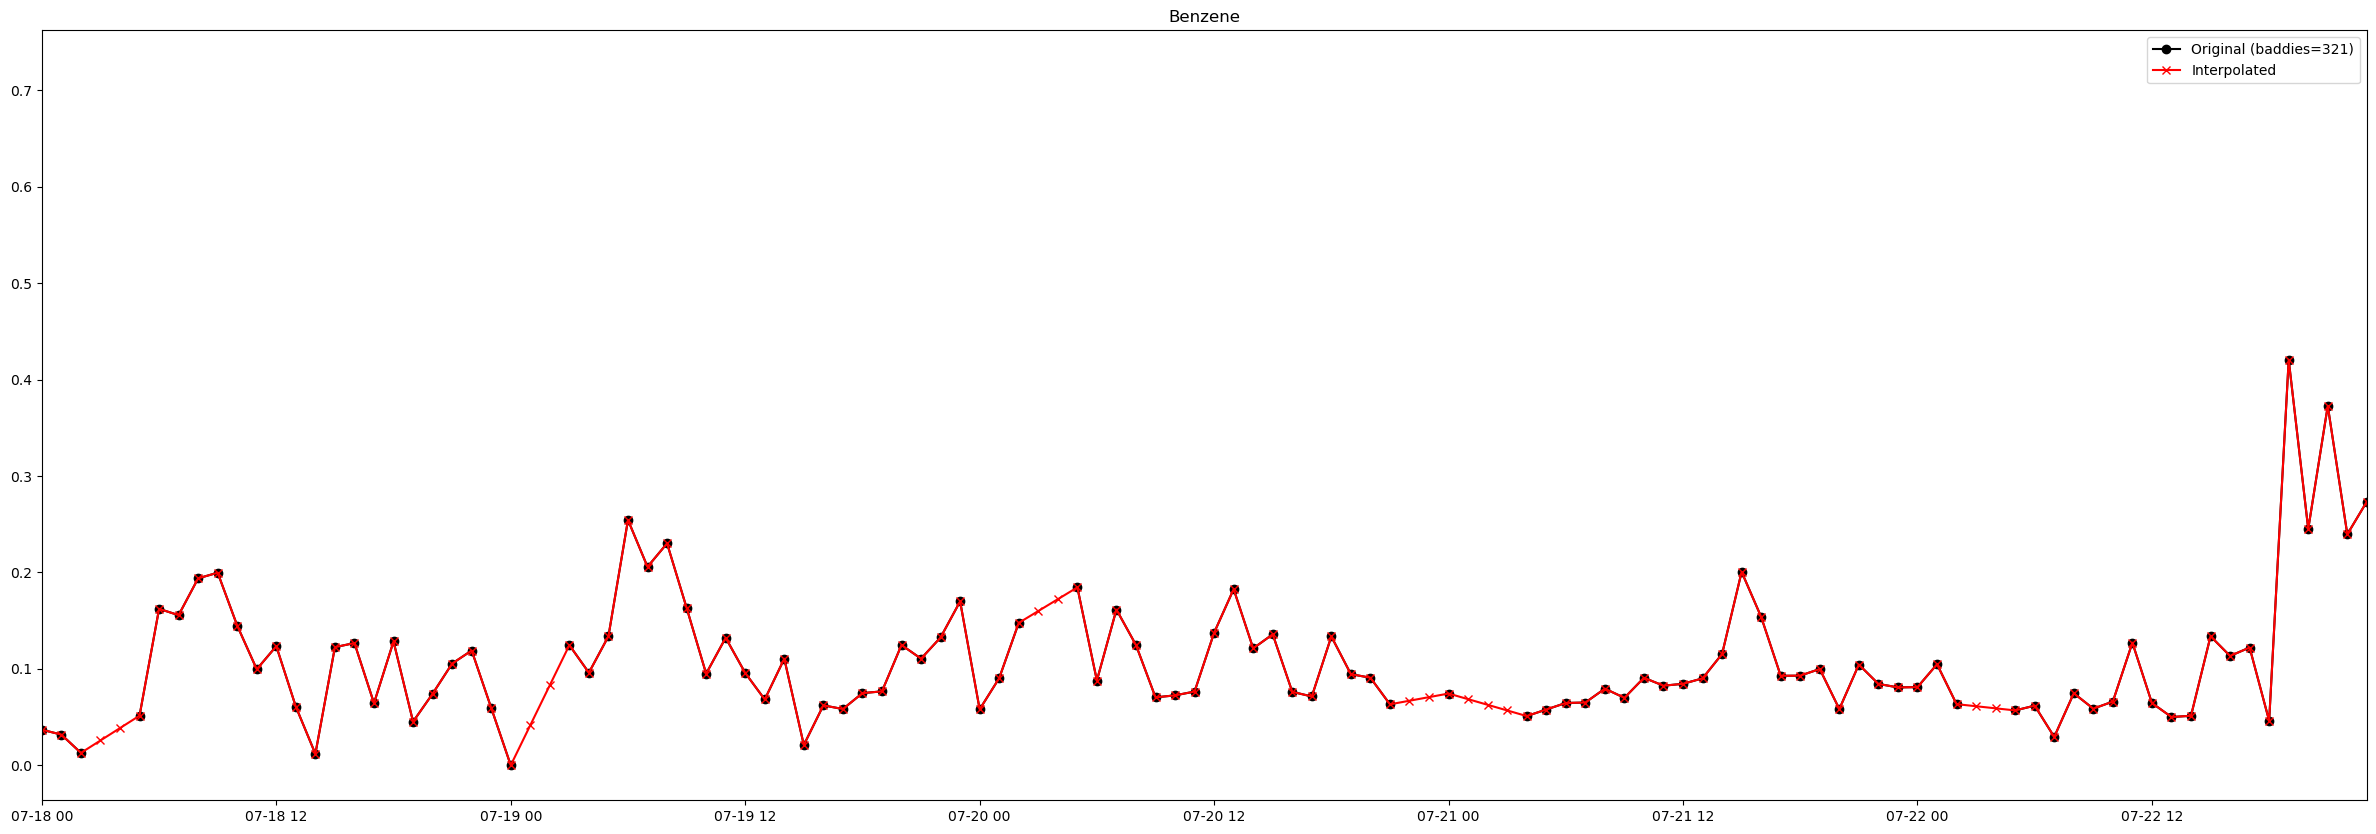

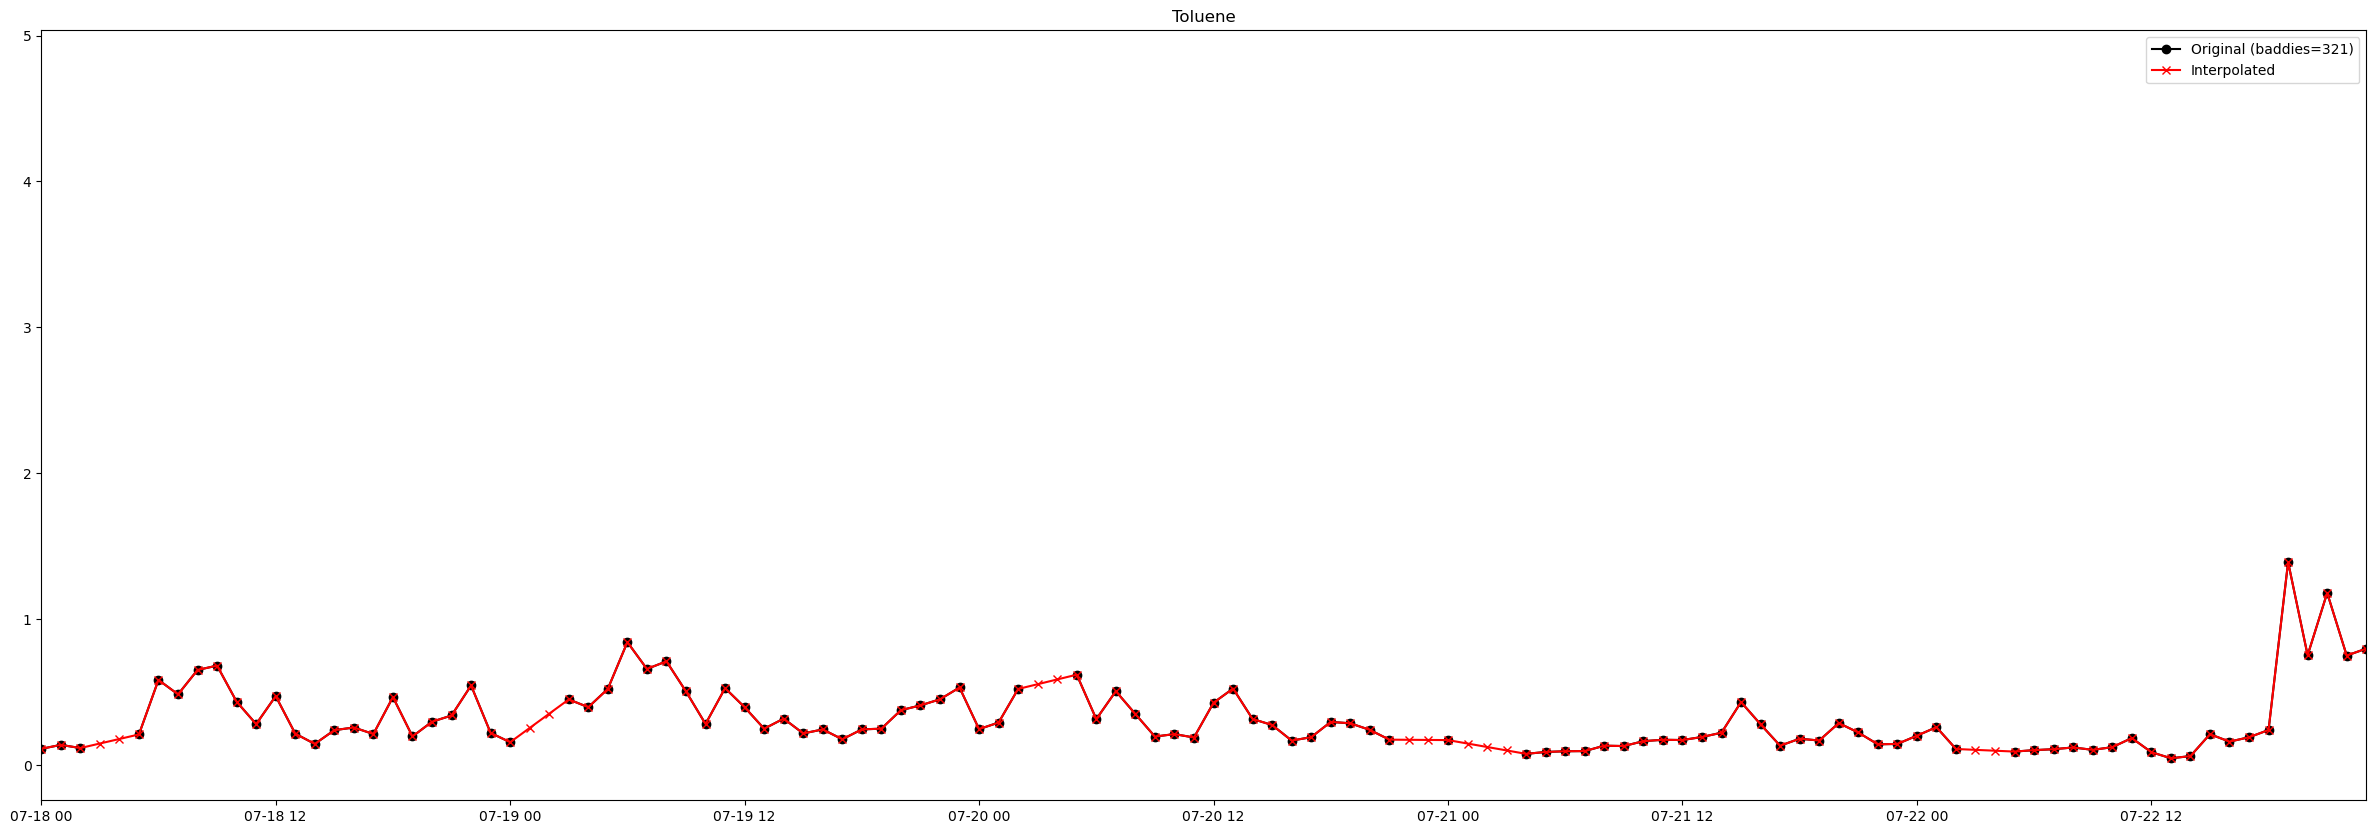

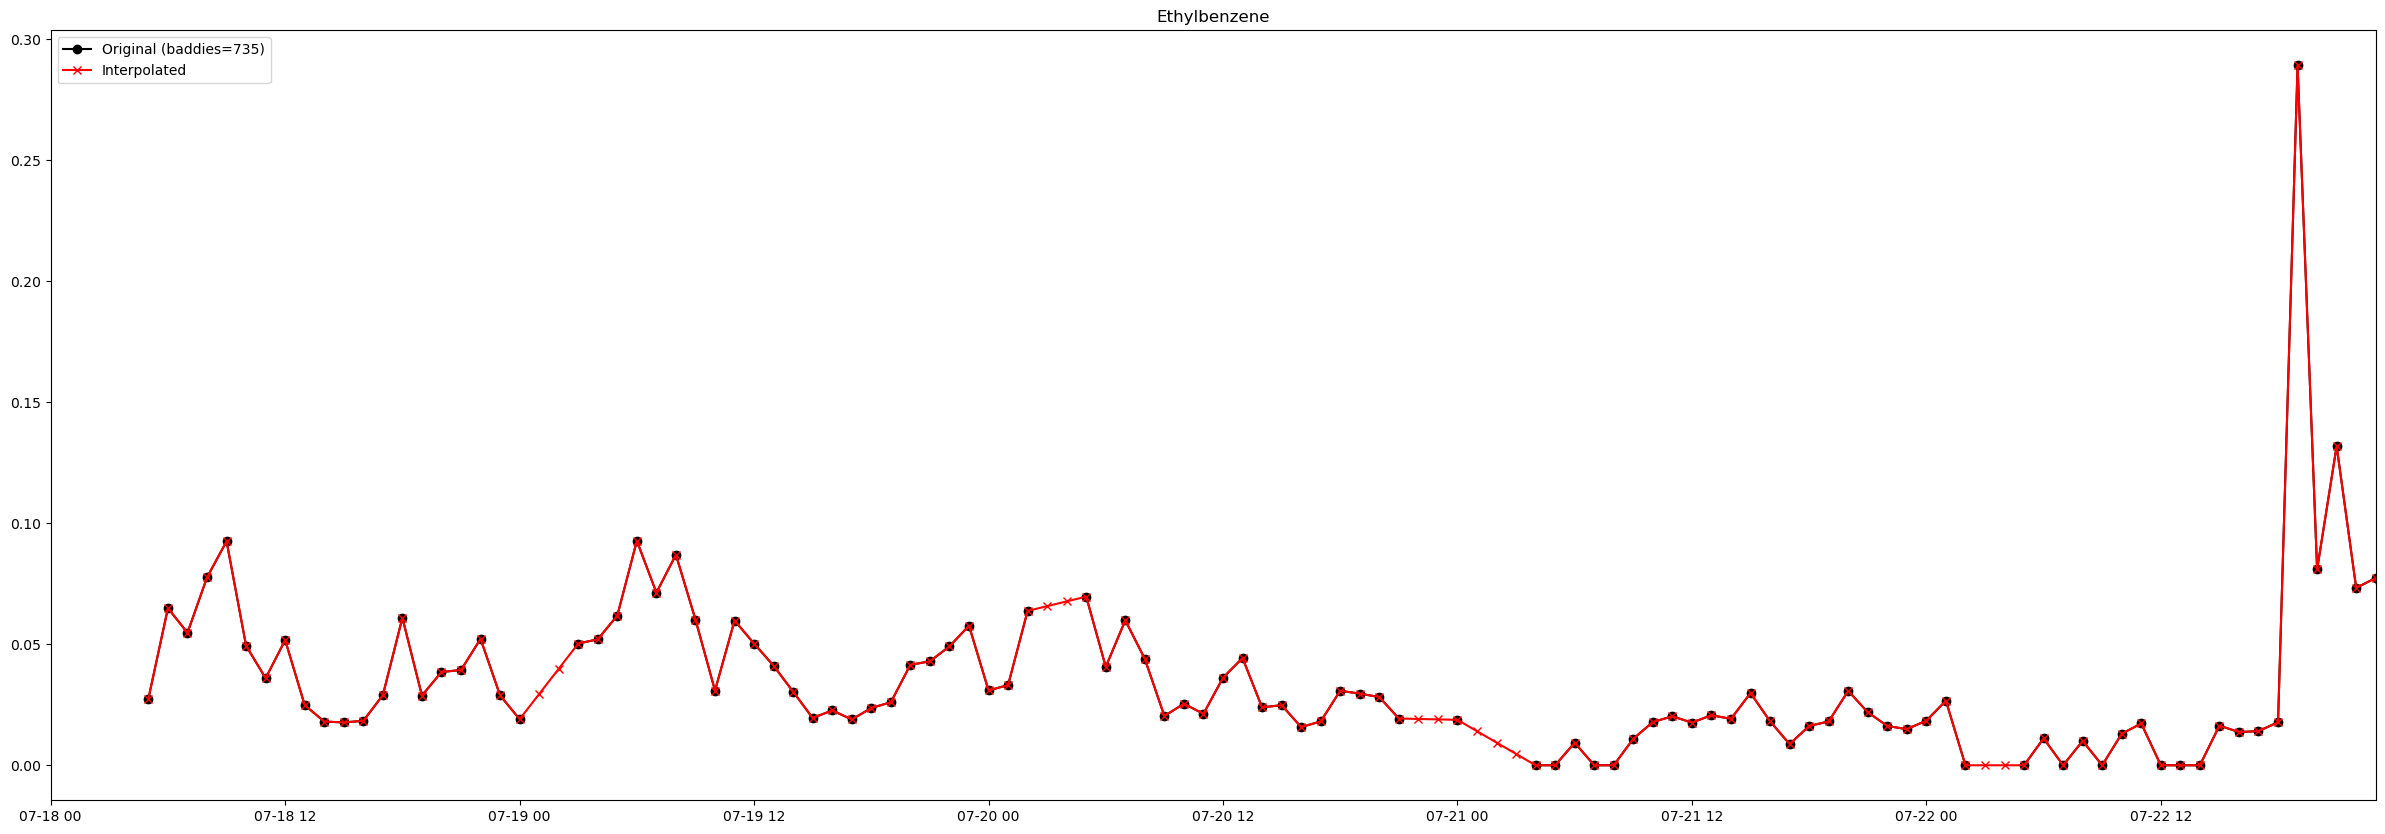

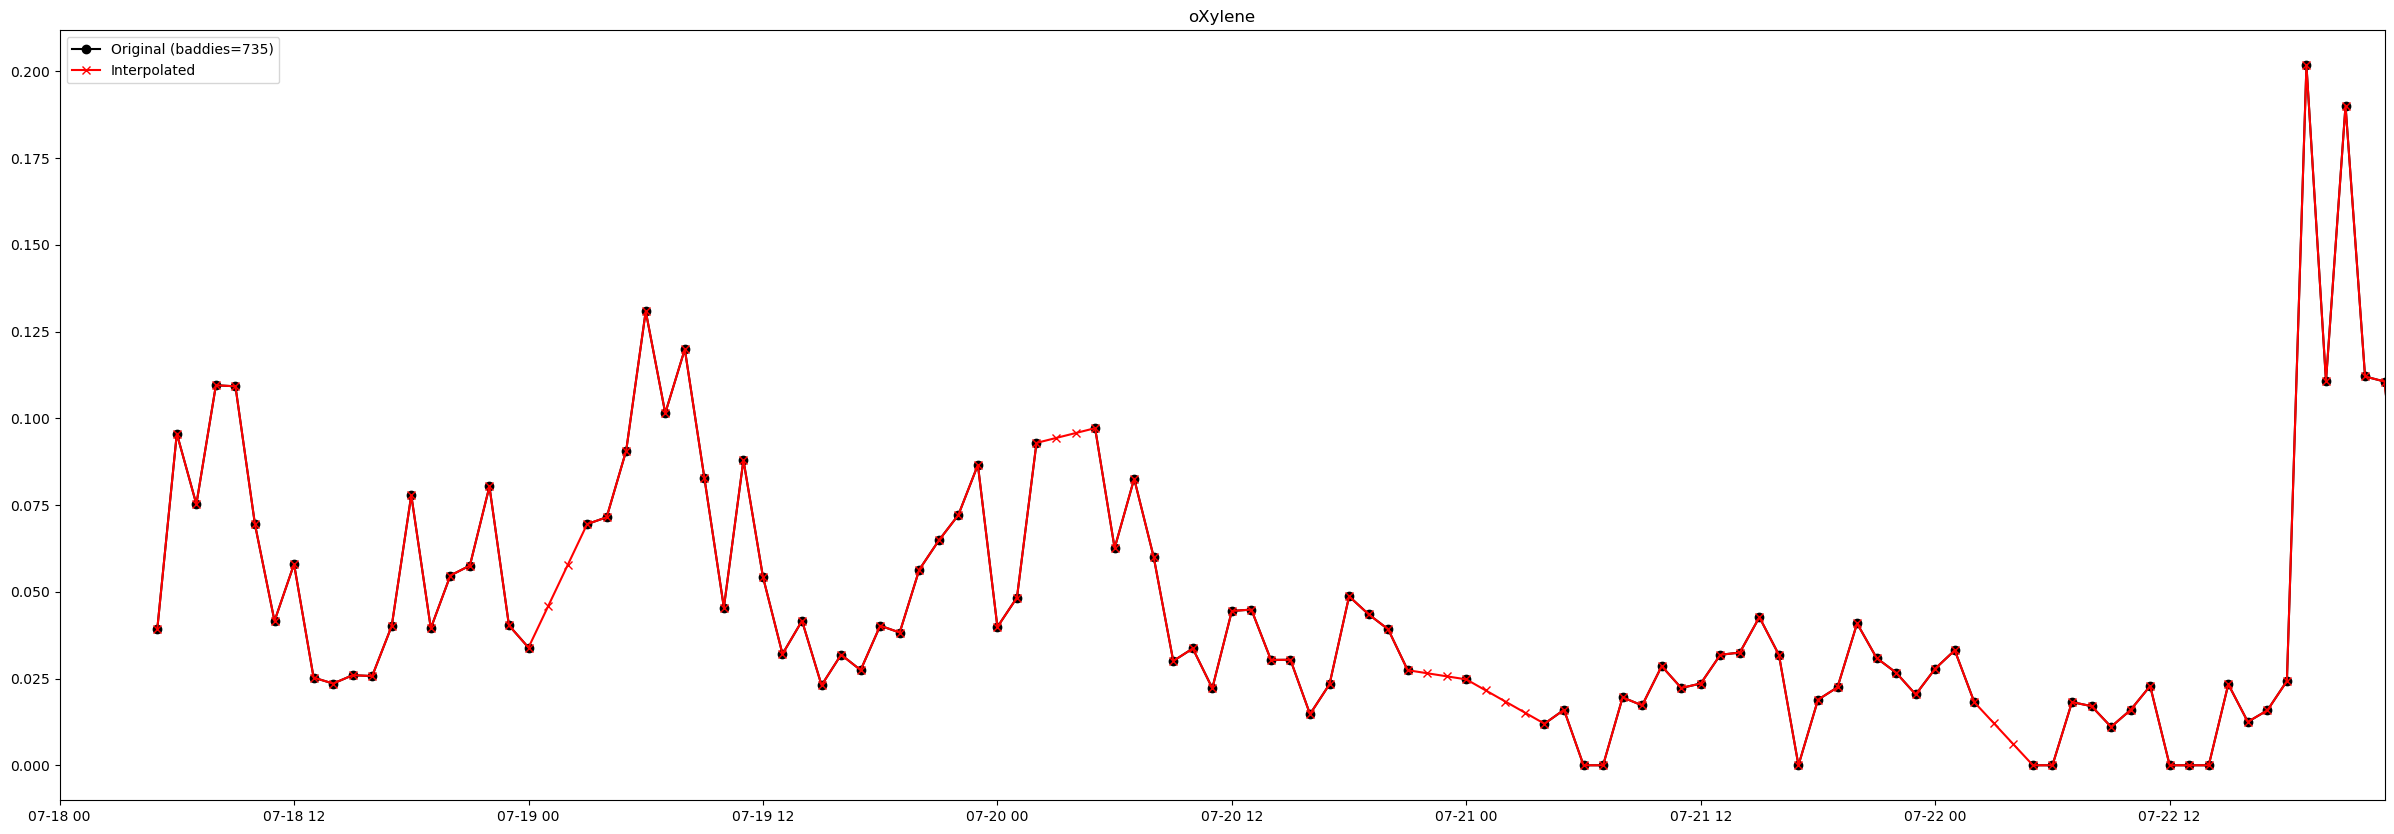

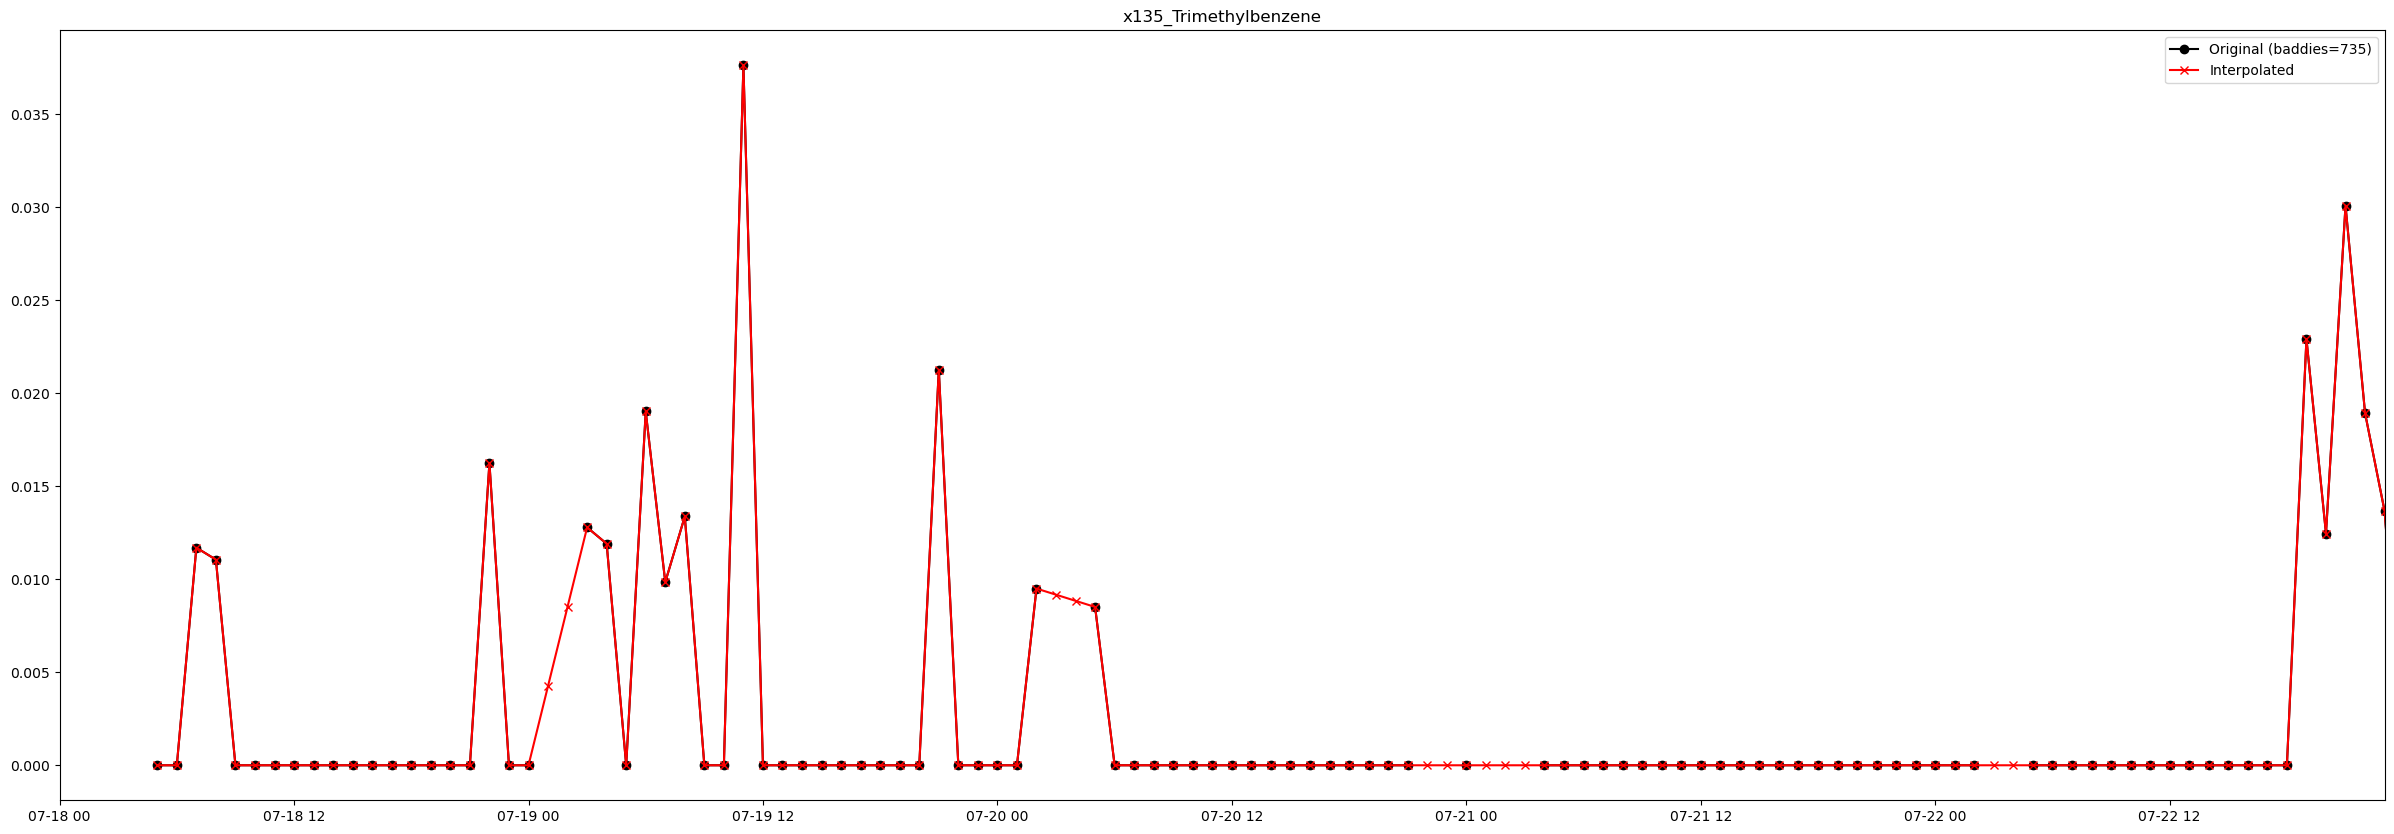

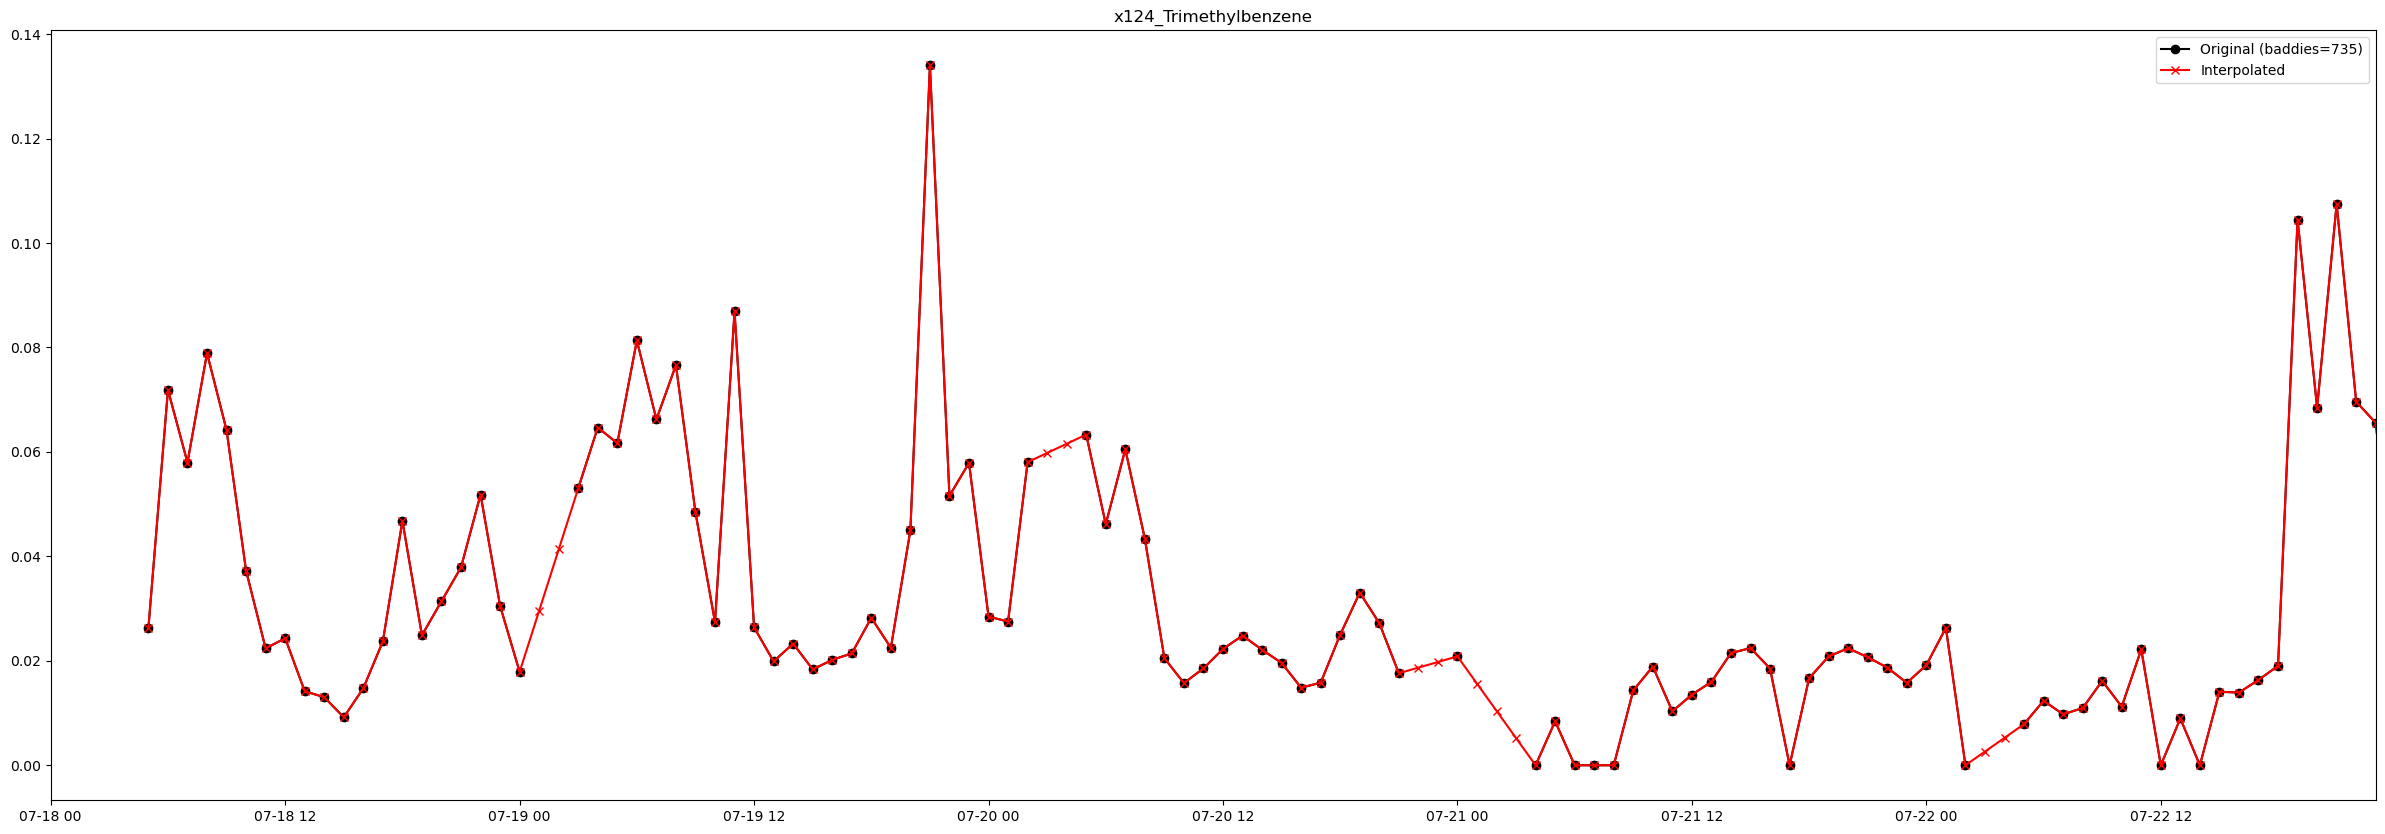

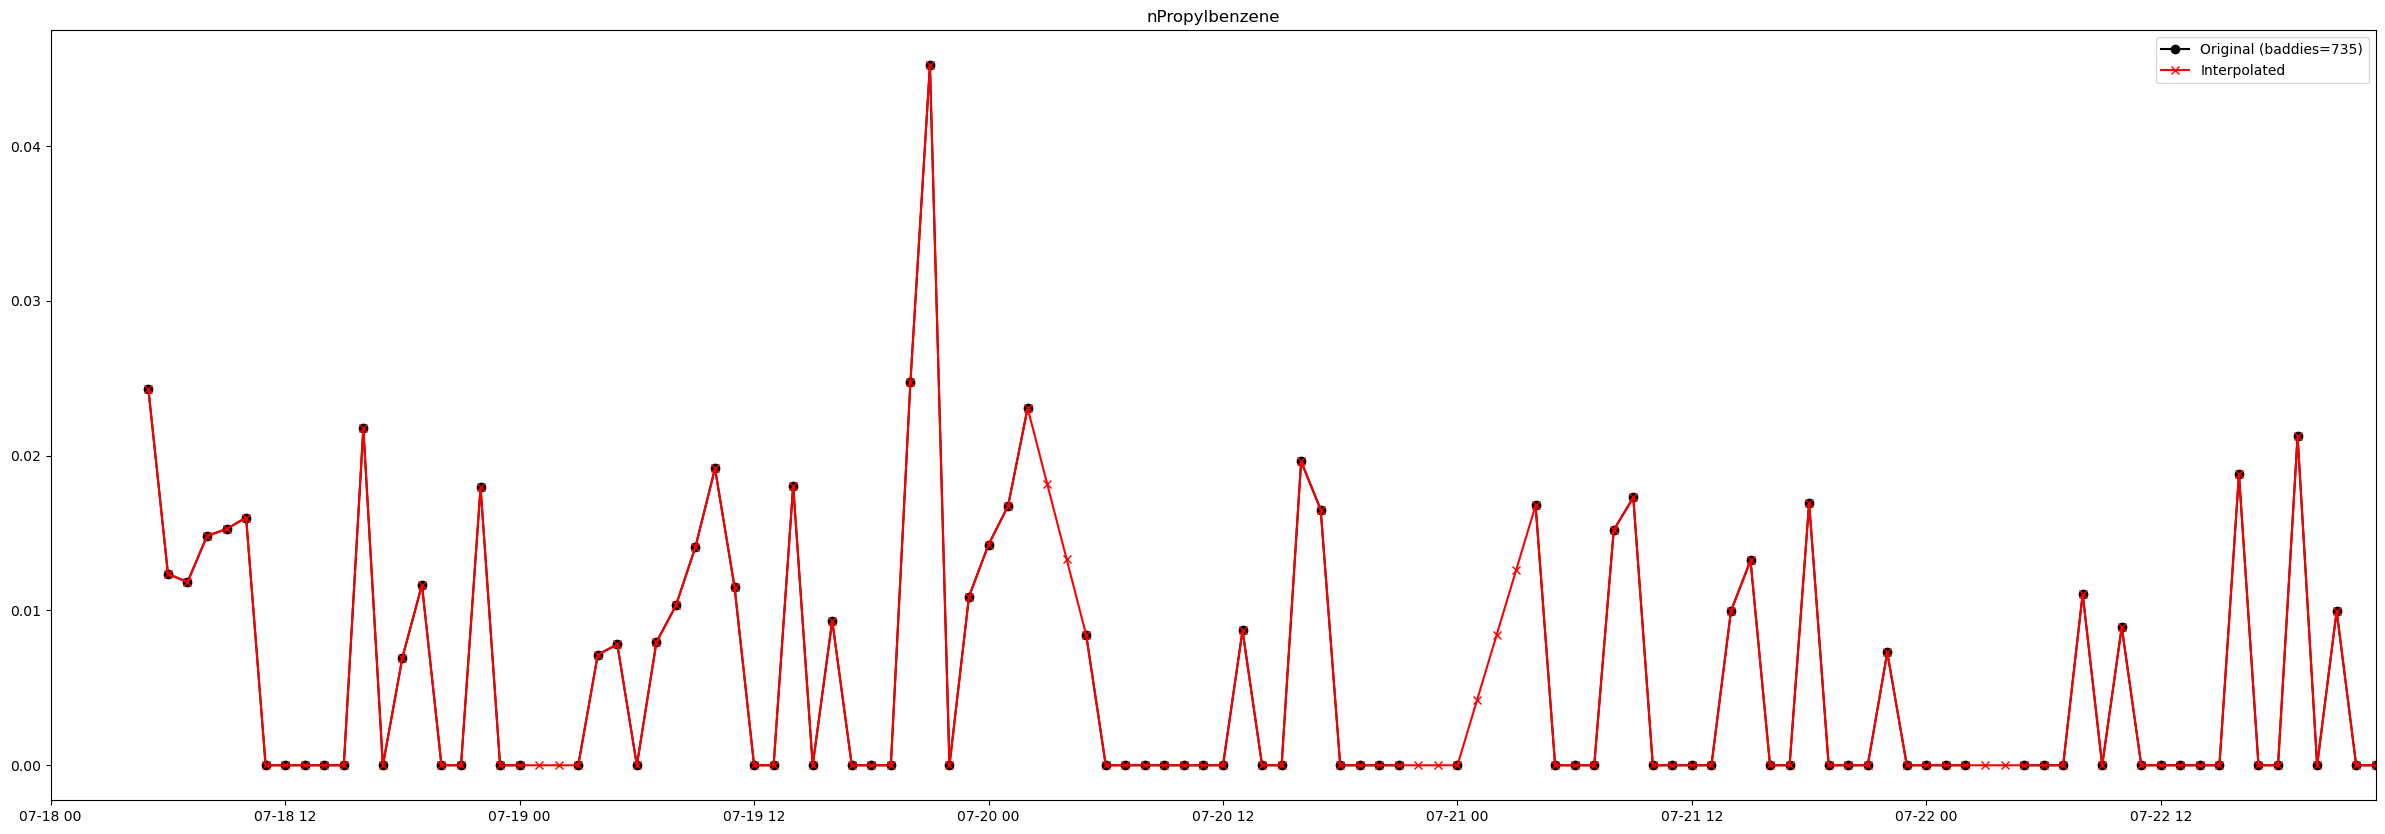

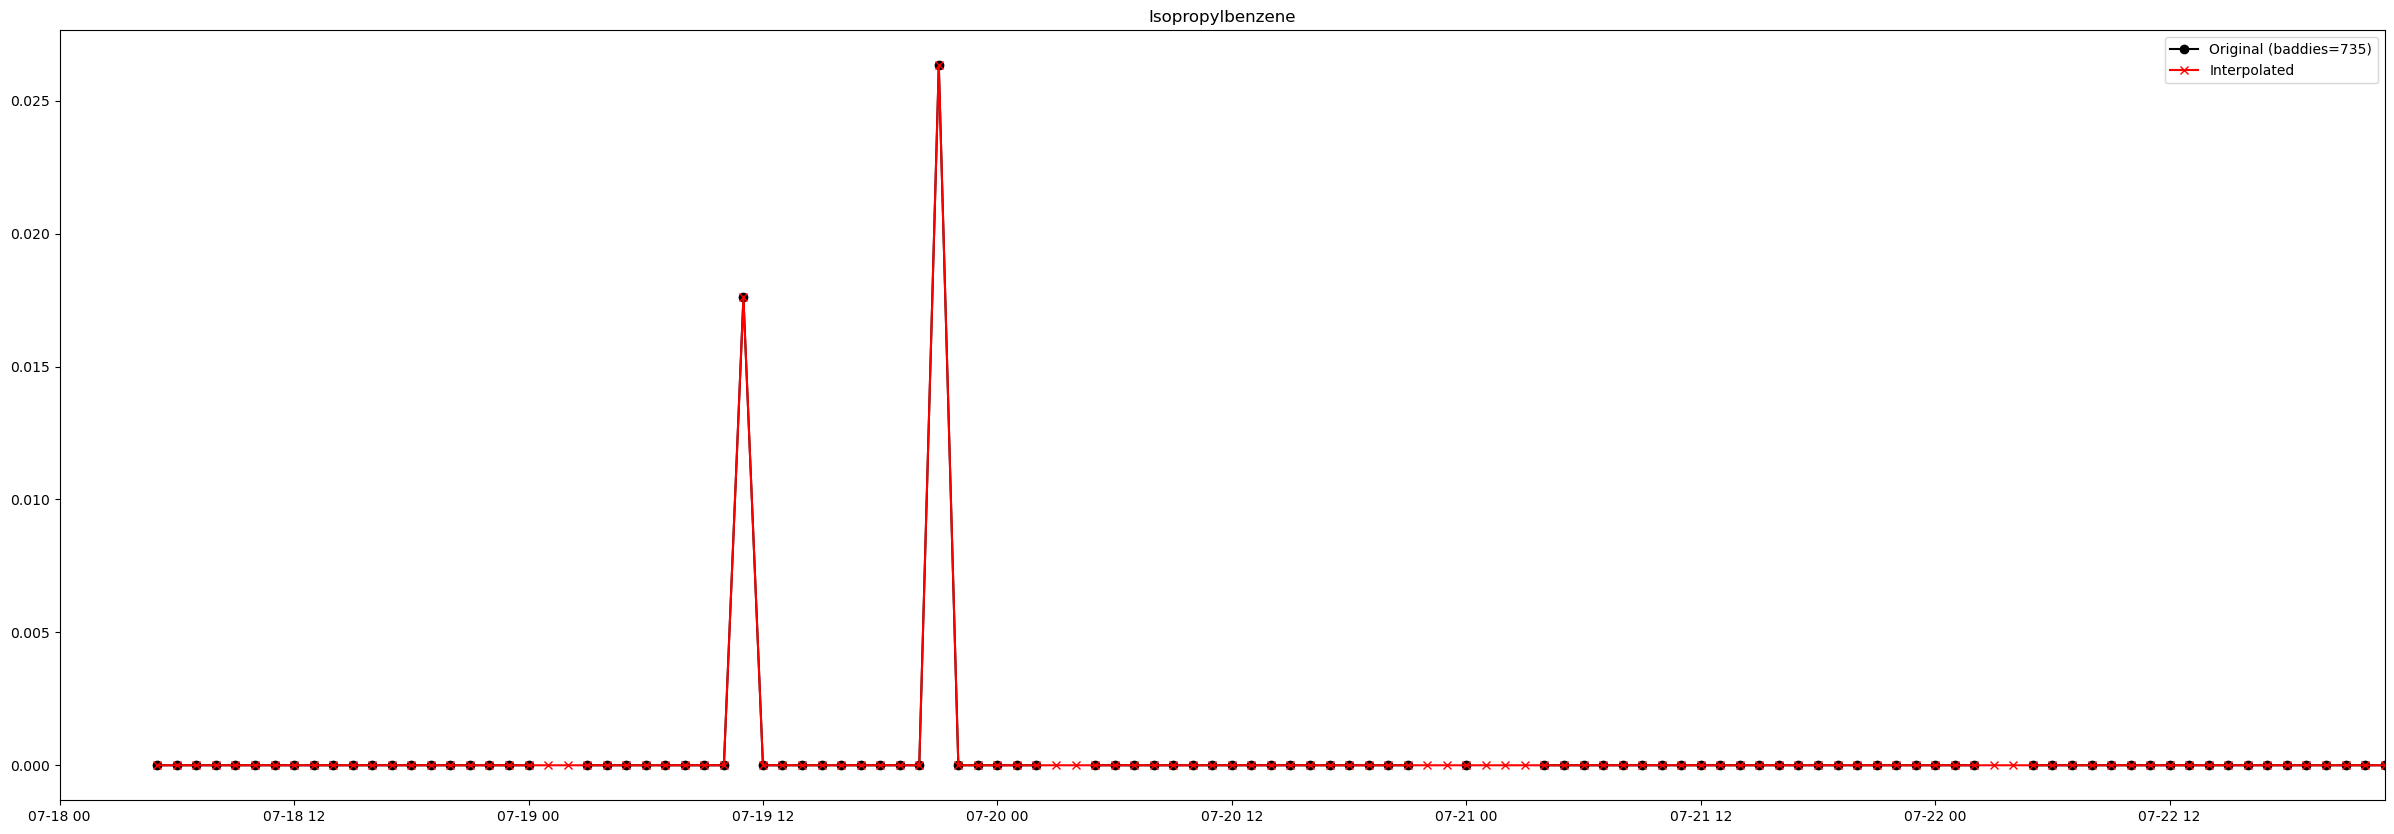

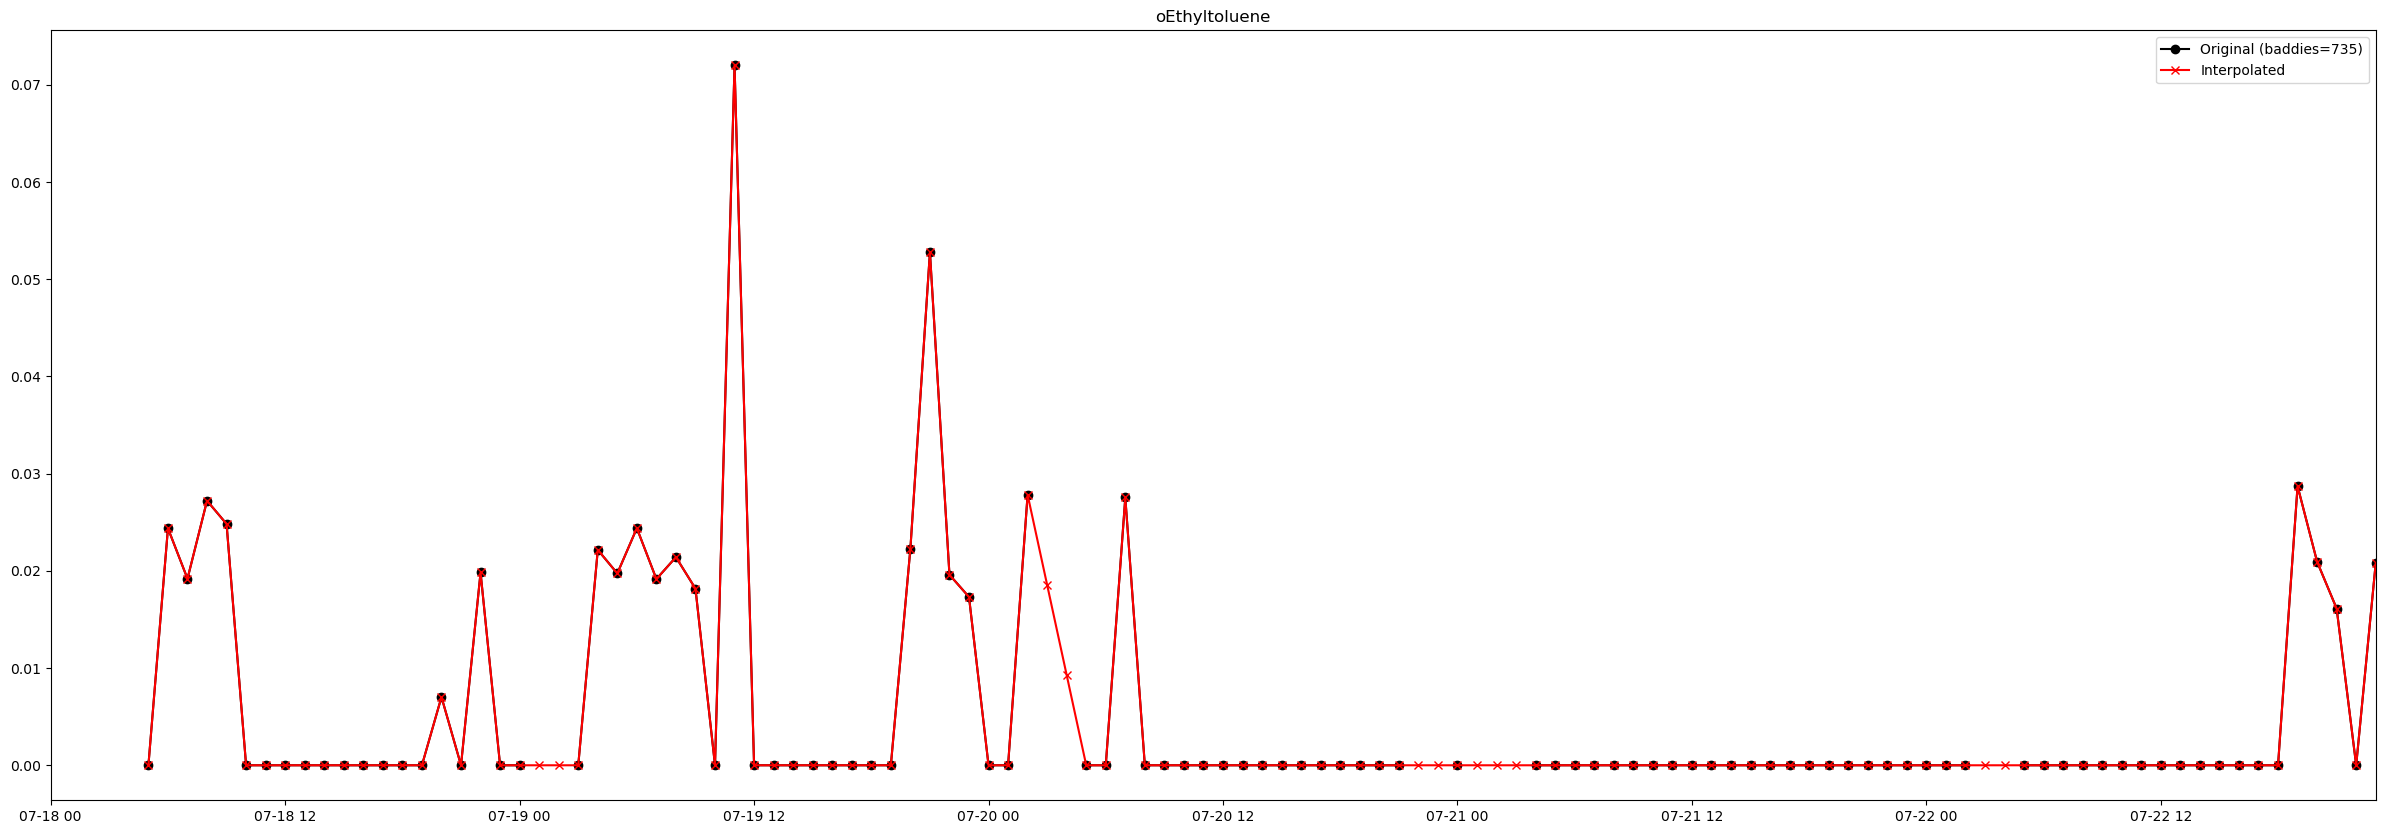

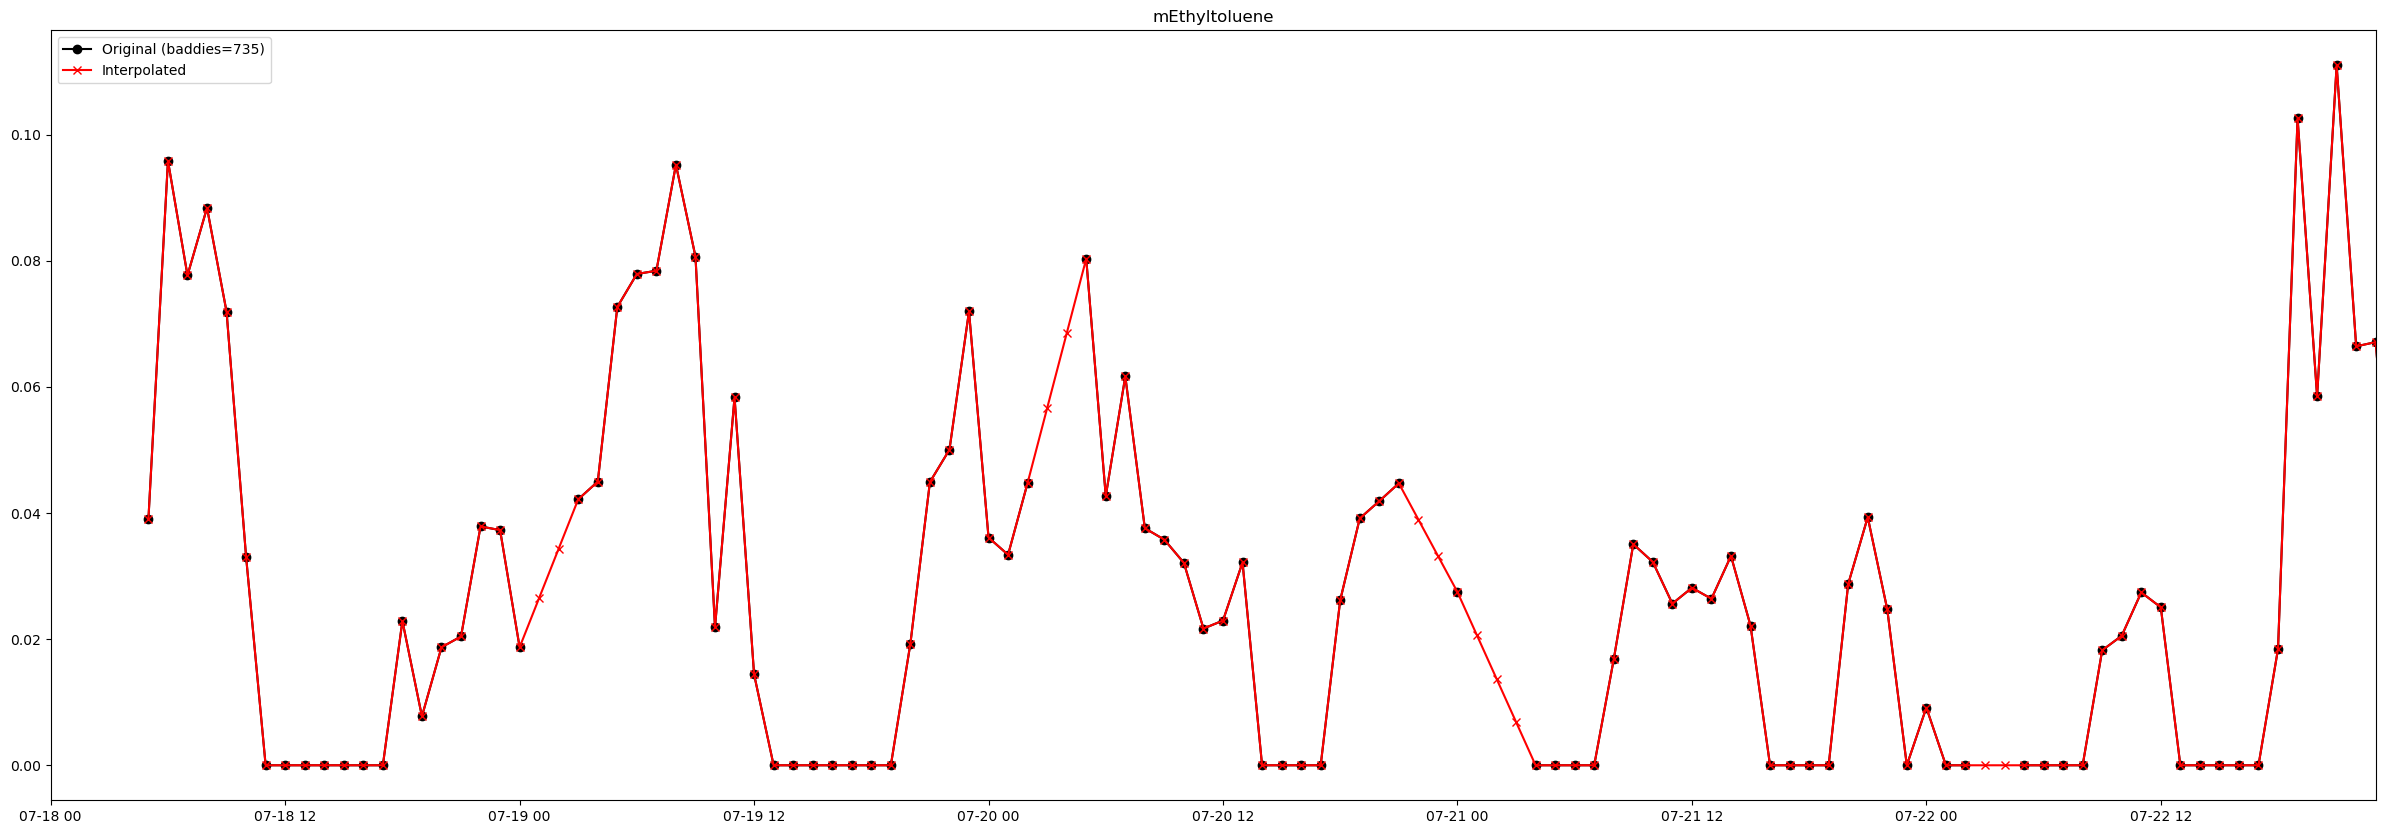

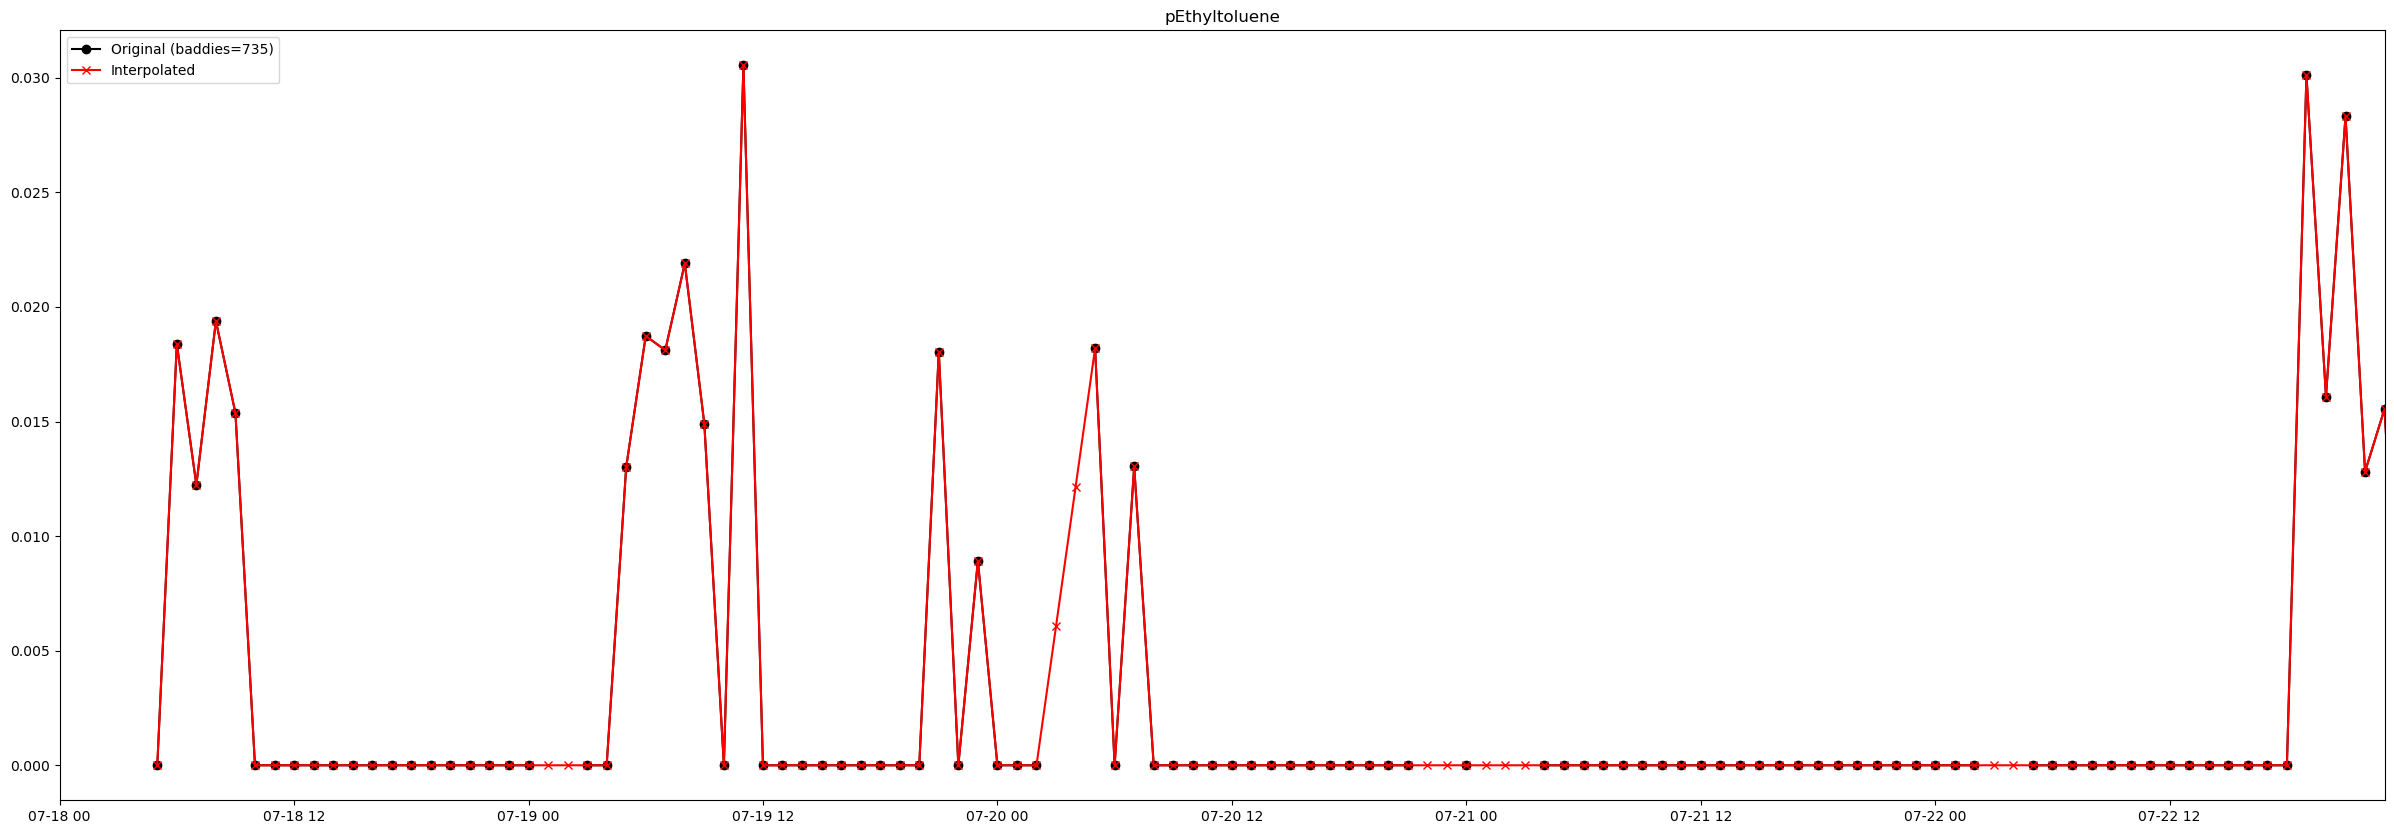

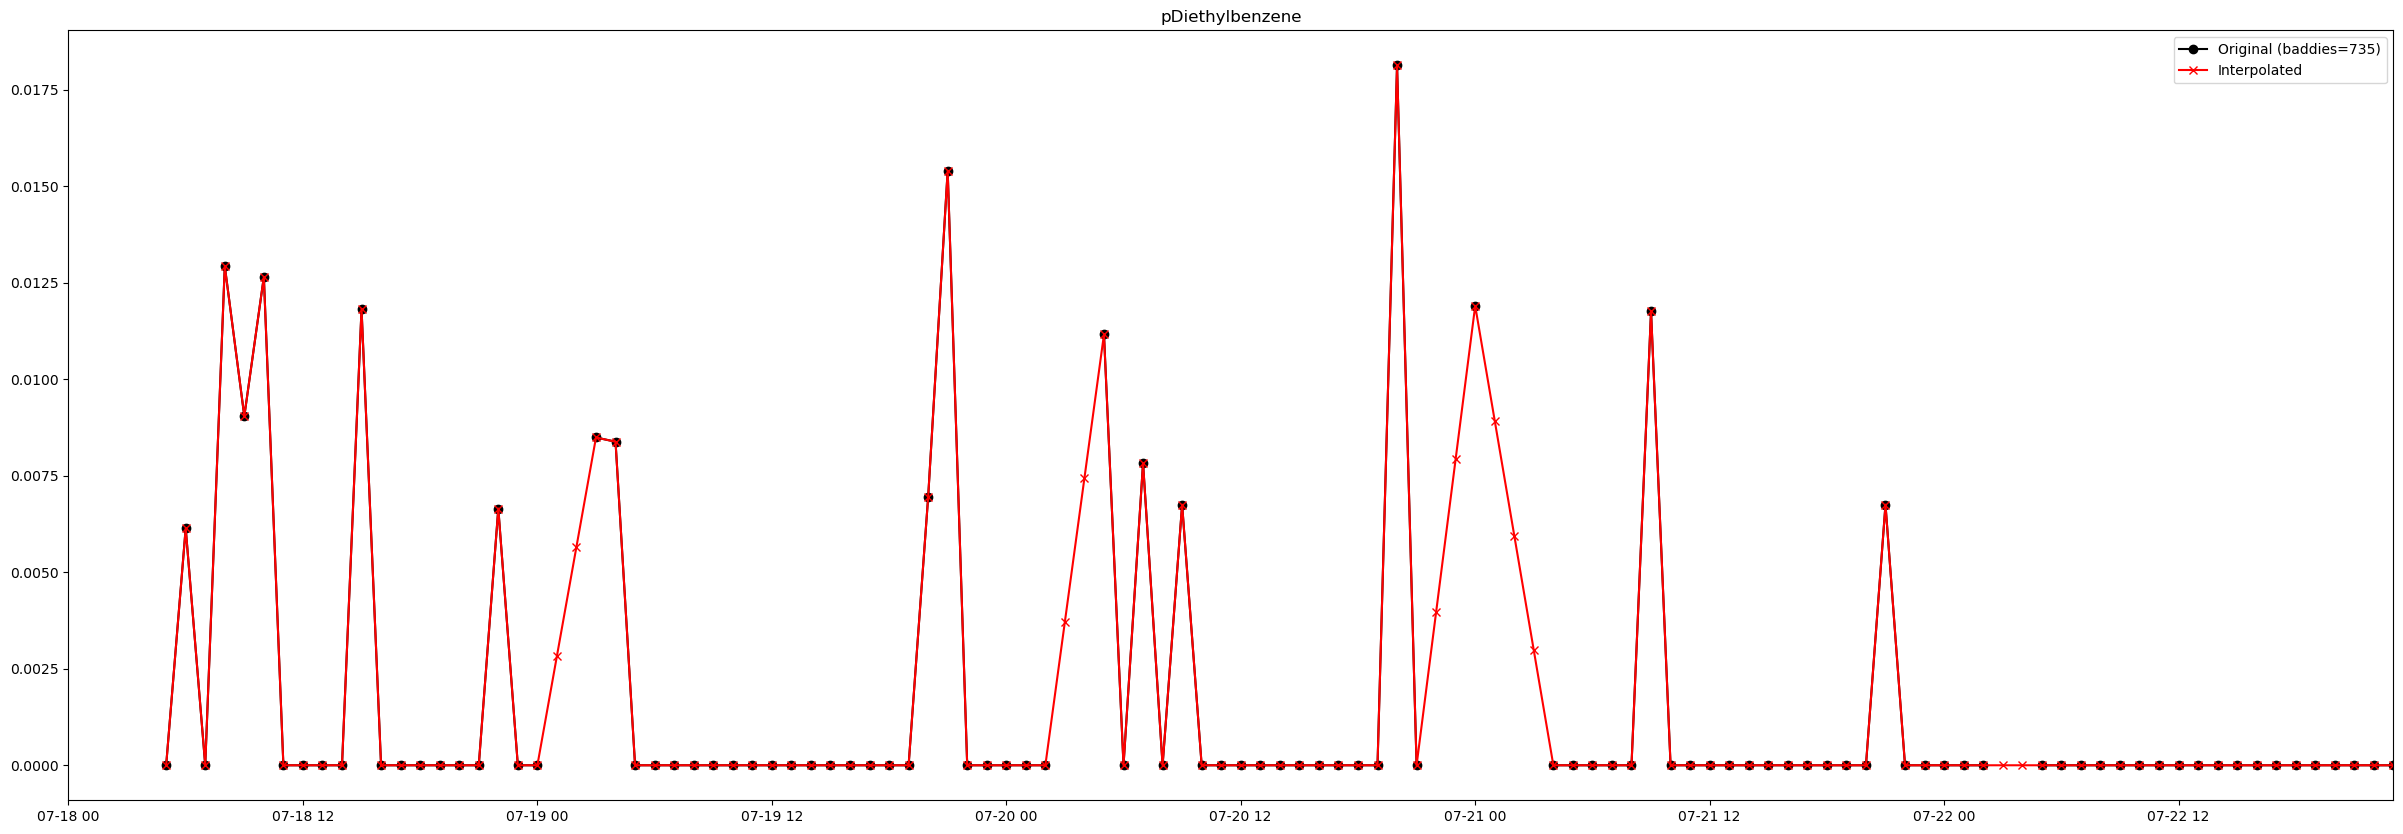

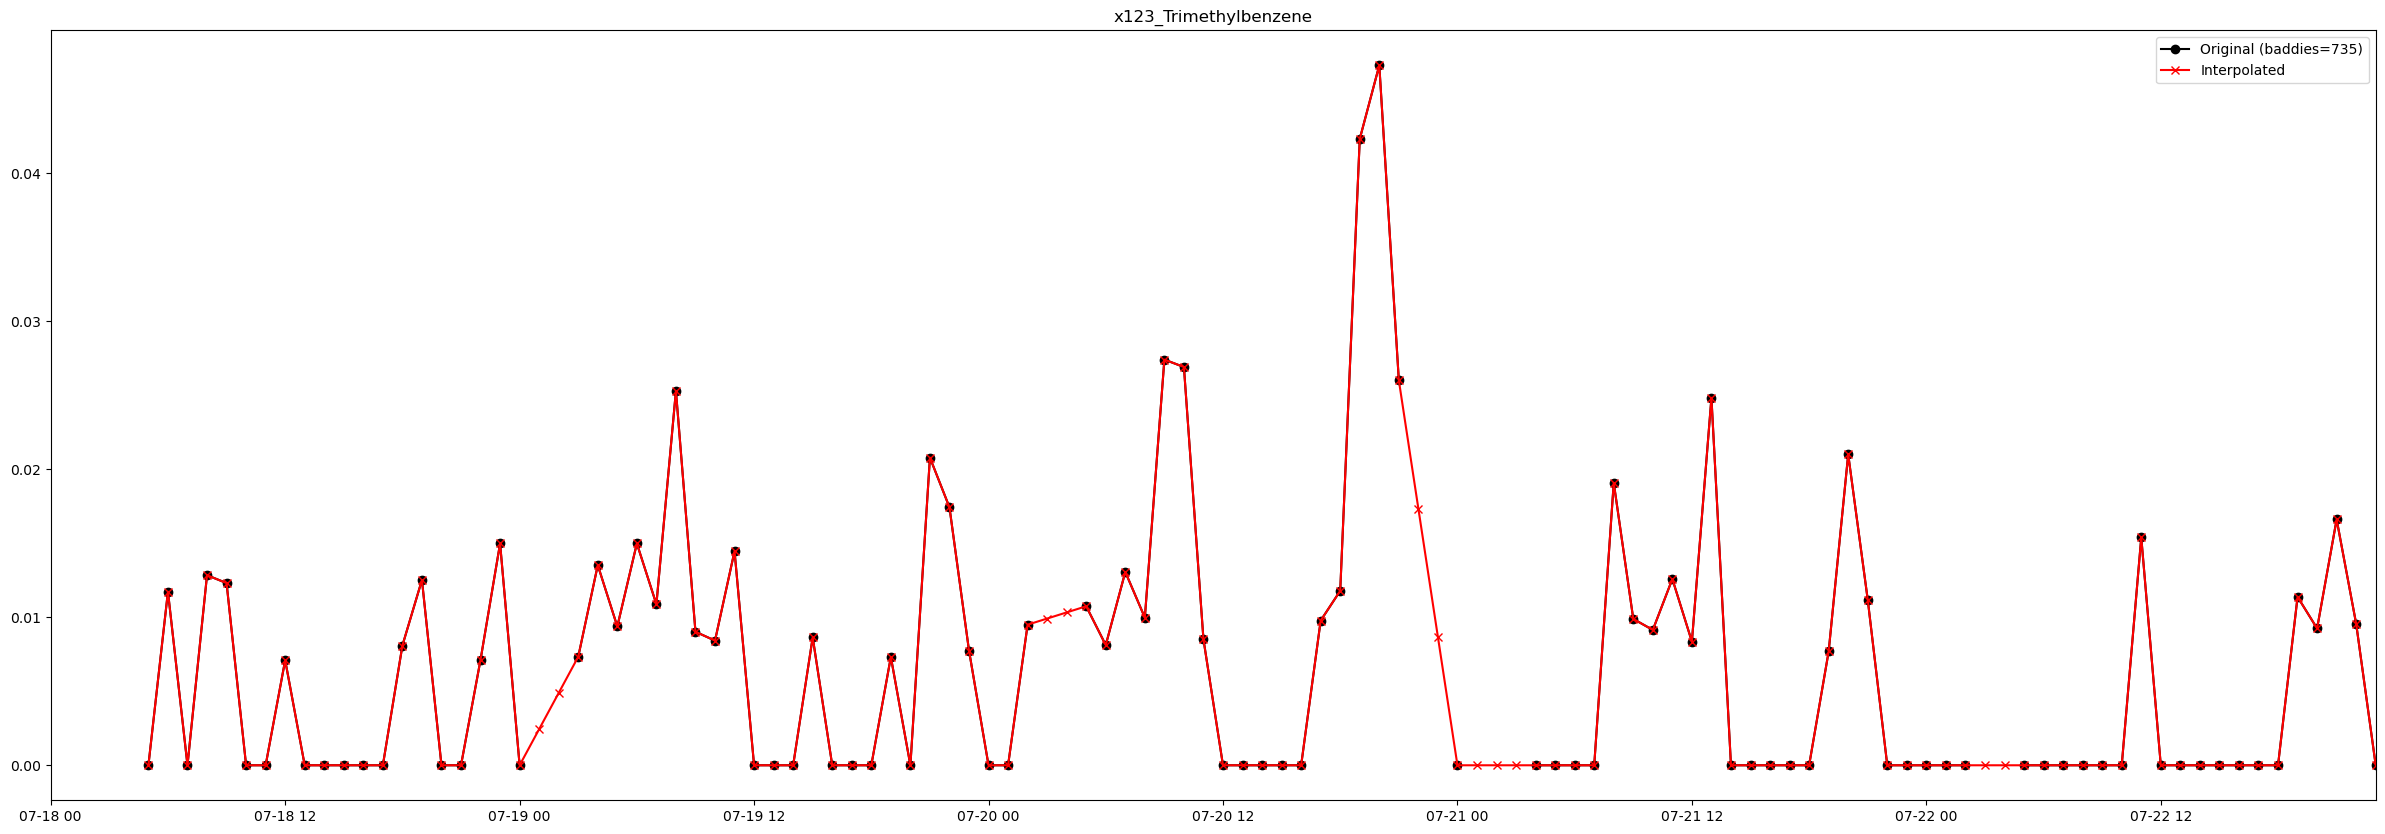

In [8]:
#Check interpolation plots to see if we can reasonably apply a linear interpolation to the VOC measurements for F0AM constraints
df_interp=df_udaq_vals.copy()
df_interp = df_interp.sort_index().loc['2024-07-15 00:00:00':'2024-08-18 23:00:00']

for i,col in enumerate(df_udaq_vals.columns.values):
    # Set any negative values to NaN so we can interp them... 
    df_interp[col] = df_interp[col].mask(df_interp[col] < 0, np.nan)
                               
    # Calc number of points that are negative or Nans: 
    n_baddies= len([item for item in df_udaq_vals[col] if item <0 or np.isnan(item)]) 
      
    if n_baddies > 0: 
        #apply the linear interpolation
        df_interp[col] = df_interp[col].interpolate(method='linear')
        
        #Plot it so we can take a look at it... 
        fig, ax = plt.subplots(figsize = (30,10))
       
        plt.plot(df_udaq_vals.index, df_udaq_vals[col], color='k', marker='o',label=f'Original (baddies={n_baddies})')
        plt.plot(df_interp.index, df_interp[col], color='r', marker='x', label='Interpolated')
        plt.legend()
        plt.xlim([pd.to_datetime('2024-07-18 00:00:00'), pd.to_datetime('2024-07-22 23:00:00')])
        plt.title(col)

In [7]:
def dataframe_to_nested_dict(df):
    nested_dict = {}
    for column in df.columns:
        nested_dict[column] = df[column][0:-1].to_numpy()
        
    # Add the index as a key-value pair
    nested_dict['time_local'] = df.index[0:-1].to_numpy()
    return nested_dict

ddict=dataframe_to_nested_dict(df_interp)

    # Sort alphabetically so not annoying in MATLAB...  
ddict= OrderedDict(sorted(ddict.items())) 

# Save the USOS data in an output .mat file: 
outpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/F0AM-4.3.0.1/Campaign_Data/matlab_merge/udaq/original/'
matfilename = '20240719_20240721_1hr_udaq_vocs.mat'
savemat(outpath+matfilename,{'UDAQ': ddict})
print('Saved MATLAB file to:' + outpath + matfilename)

Saved MATLAB file to:/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/F0AM-4.3.0.1/Campaign_Data/matlab_merge/udaq/original/20240719_20240721_1hr_udaq_vocs.mat


### NOTE: 
It seems like it will require a lot more work to get reasonable values for F0AM usage but for now, the earliest dates in the campaign show some reasonable days for using linear interpolation and being able to use the VOC measurements as constraints. Will focus on first few days of data.

In [59]:
bool_udaq = (df_udaq_vals > 0) & (df_udaq_vals.notna())
df_udaq_vocs_transposed=bool_udaq.T
print(df_udaq_vocs_transposed)

                       2024-07-15 00:00:00  2024-07-15 01:00:00  \
Ethane                               False                False   
Ethylene                             False                False   
Propane                              False                False   
Propylene                            False                False   
acetylene                            False                False   
nButane                              False                False   
Isobutane                            False                False   
trans2Butene                         False                False   
cis2Butene                           False                False   
buta13diene                          False                False   
nPentane                             False                False   
Isopentane                           False                False   
Pent1ene                             False                False   
trans2Pentene                        False                Fals

In [63]:
start_first = bool_udaq.index.min()
end_first = start_first + pd.Timedelta(days=17)
first_17days_df = bool_udaq.loc[start_first:end_first]
first_17days_df_transposed = first_17days_df.T

start_second = bool_udaq.index.min() + pd.Timedelta(days=17)
end_second = start_second + pd.Timedelta(days=17)
second_17days_df = bool_udaq.loc[start_second:end_second]
second_17days_df_transposed = second_17days_df.T

/tmp/ipykernel_3894320/2007964454.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_top.set_xticklabels(midnight_labels)


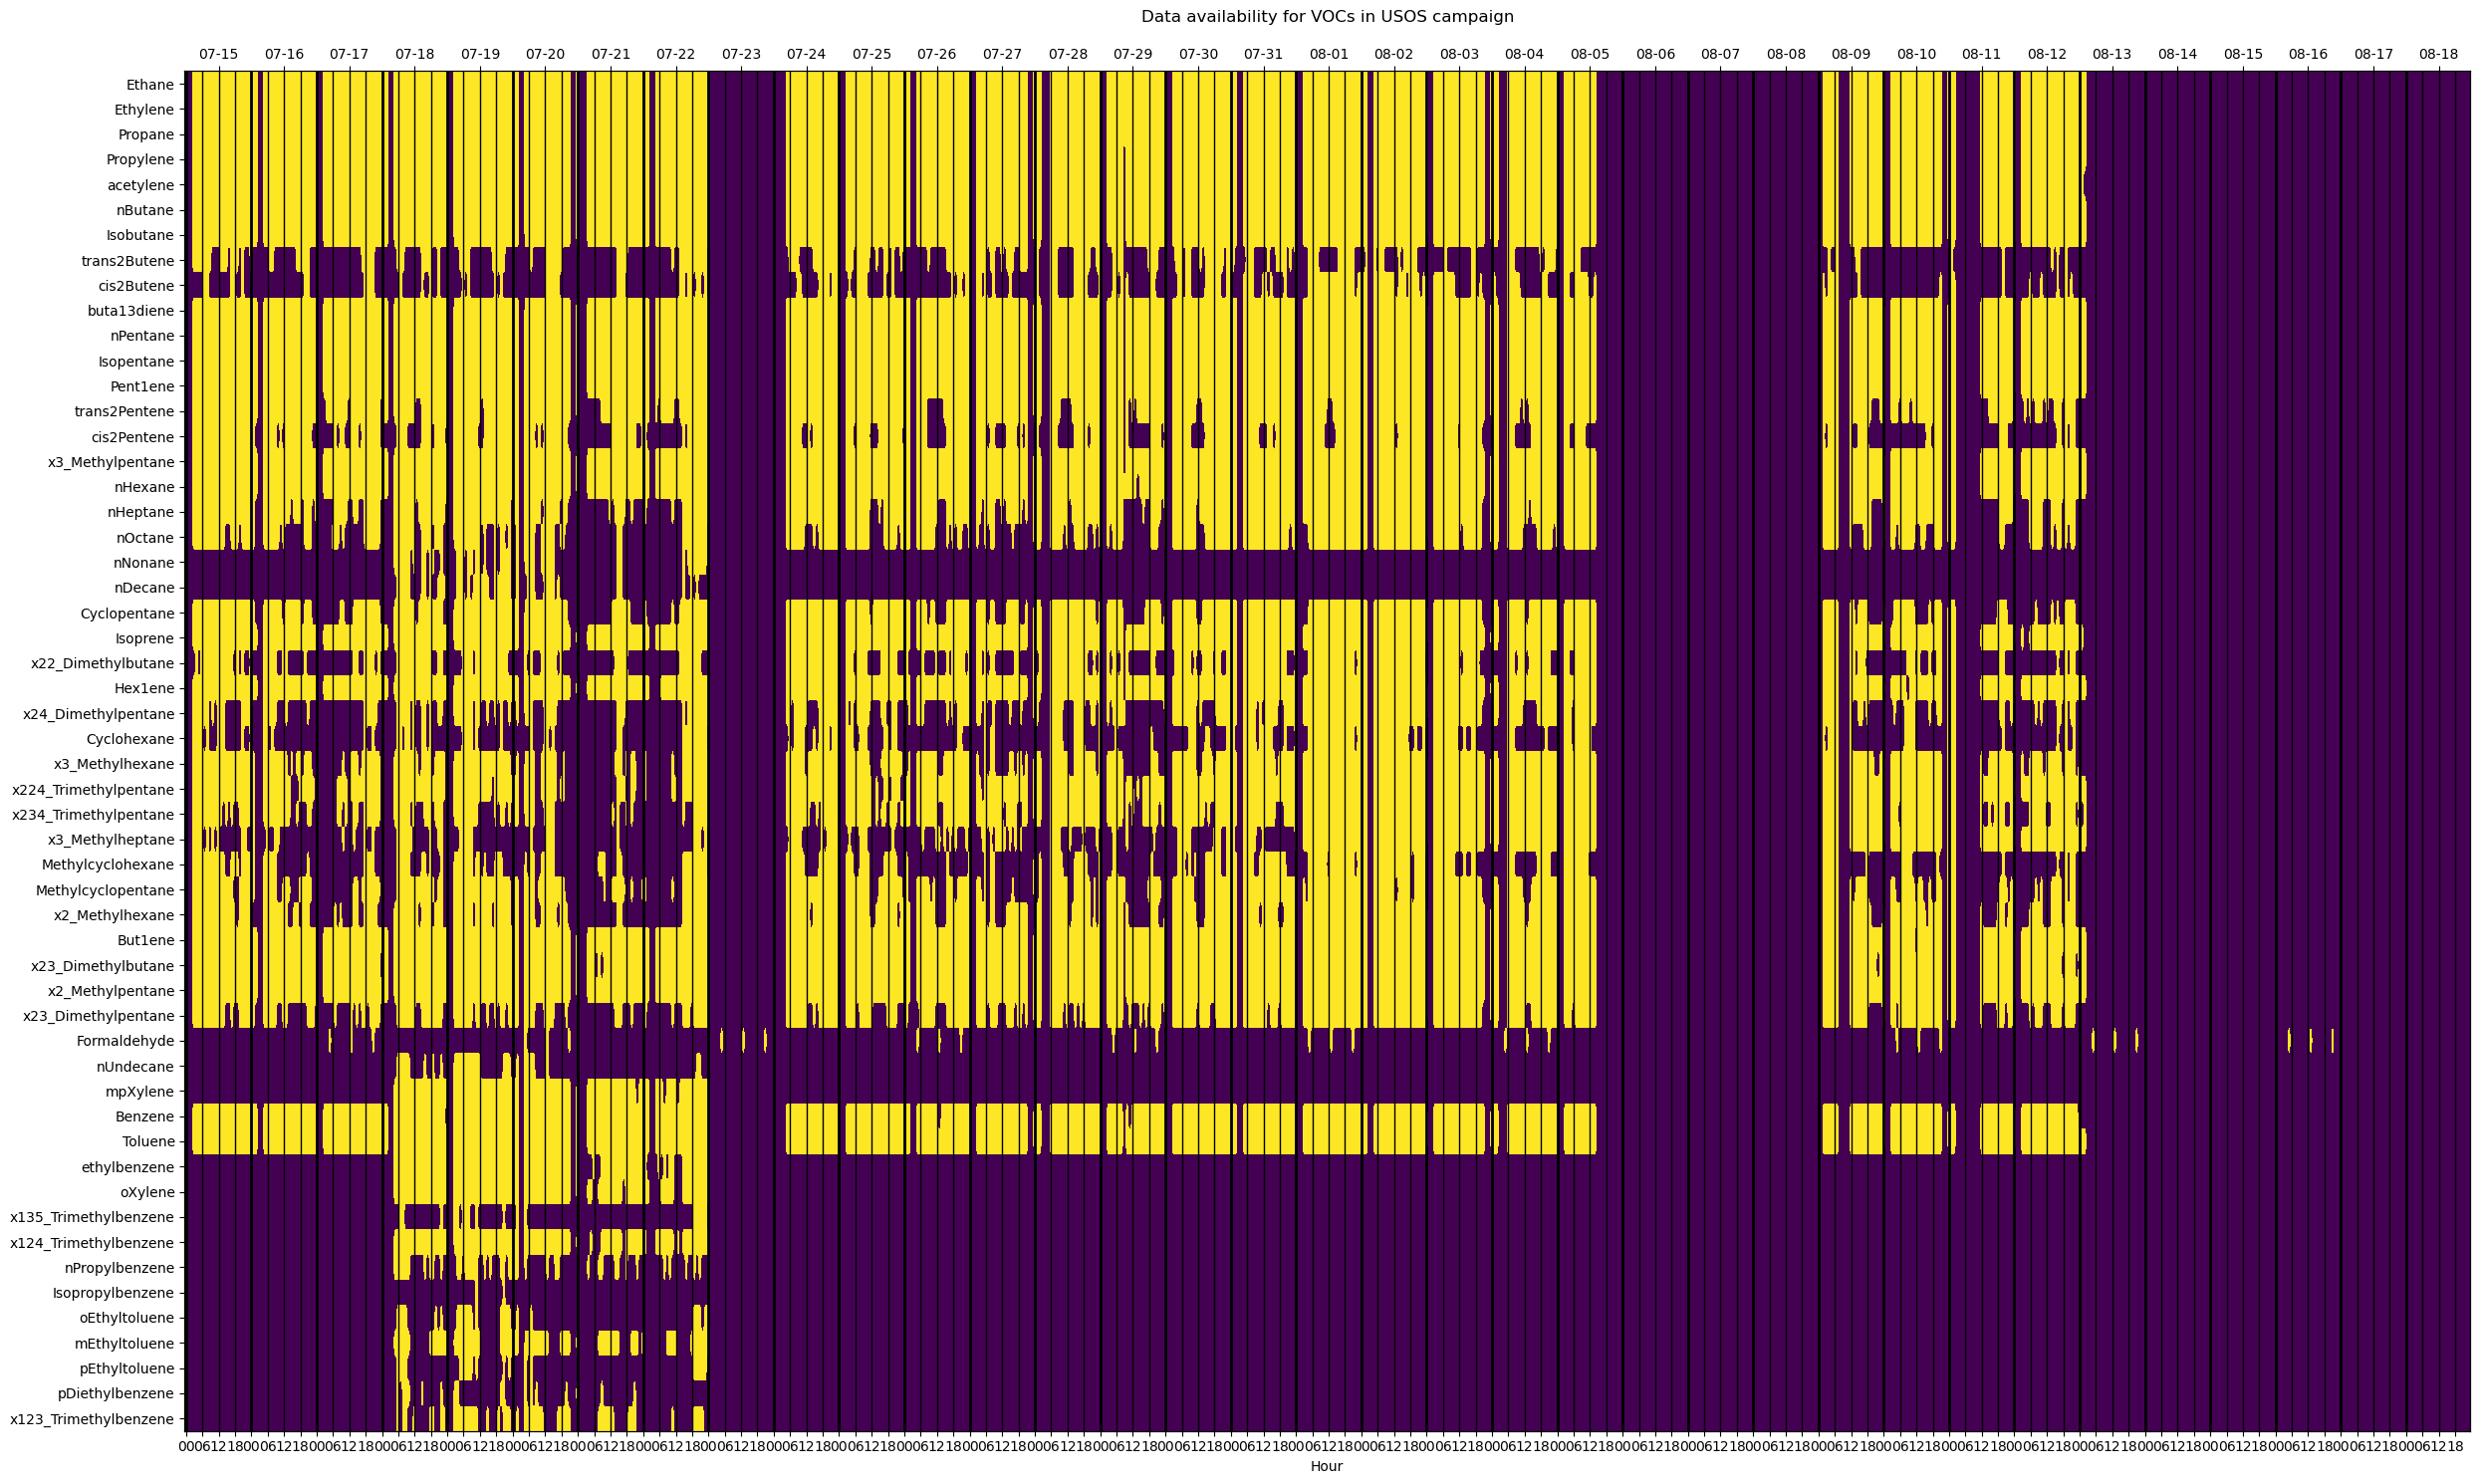

In [61]:
#alter viridis colormap to only have 2 color options
viridis = plt.cm.viridis
colors = [viridis(0.0), viridis(1.0)]
two_color_viridis = ListedColormap(colors)

# Create the heatmap using imshow
fig, ax = plt.subplots(figsize=(25, 15))
ax.imshow(df_udaq_vocs_transposed, aspect='auto', cmap=two_color_viridis)
# Set x-ticks and y-ticks
ax.set_xticks(ticks=range(0,len(df_udaq_vocs_transposed.columns),6), labels=df_udaq_vocs_transposed.columns.strftime('%H')[0::6])
ax.set_yticks(ticks=np.arange(len(df_udaq_vocs_transposed.index)), labels=df_udaq_vocs_transposed.index)
ax.set_xlabel('Hour')

for pos in range(0,len(df_udaq_vocs_transposed.columns),24):
    plt.axvline(pos, color = 'black', linewidth = 2)
for pos in range(0,len(df_udaq_vocs_transposed.columns),6):
    plt.axvline(pos, color = 'black', linewidth = 1)
#    plt.axvline(df_allvars_transposed.columns.strftime('%H%M')[12::48], color = 'black')           

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
midnight_labels = []
for date in range(12,len(df_udaq_vocs_transposed.columns),24):
    date_labels = df_udaq_vocs_transposed.columns.strftime('%m-%d')[date]
    midnight_labels.append(date_labels)

ax_top.set_xticklabels(midnight_labels)
ax_top.set_xticks(ticks=range(12,len(df_udaq_vocs_transposed.columns),24))

# Set labels and title
plt.ylabel('Measurement')
plt.title('Data availability for VOCs in USOS campaign\n')

# Show plot
plt.tight_layout()
plt.show()

#save_filepath_merger = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_merges/data_availability_plots/three_day_availability_'+ str(date_to_plot) + '.png'
#plt.savefig(fname = save_filepath_merger,format='png')
#print('Saved figure as:' + str(save_filepath_merger))

/tmp/ipykernel_3894320/3634545699.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_top.set_xticklabels(midnight_labels)


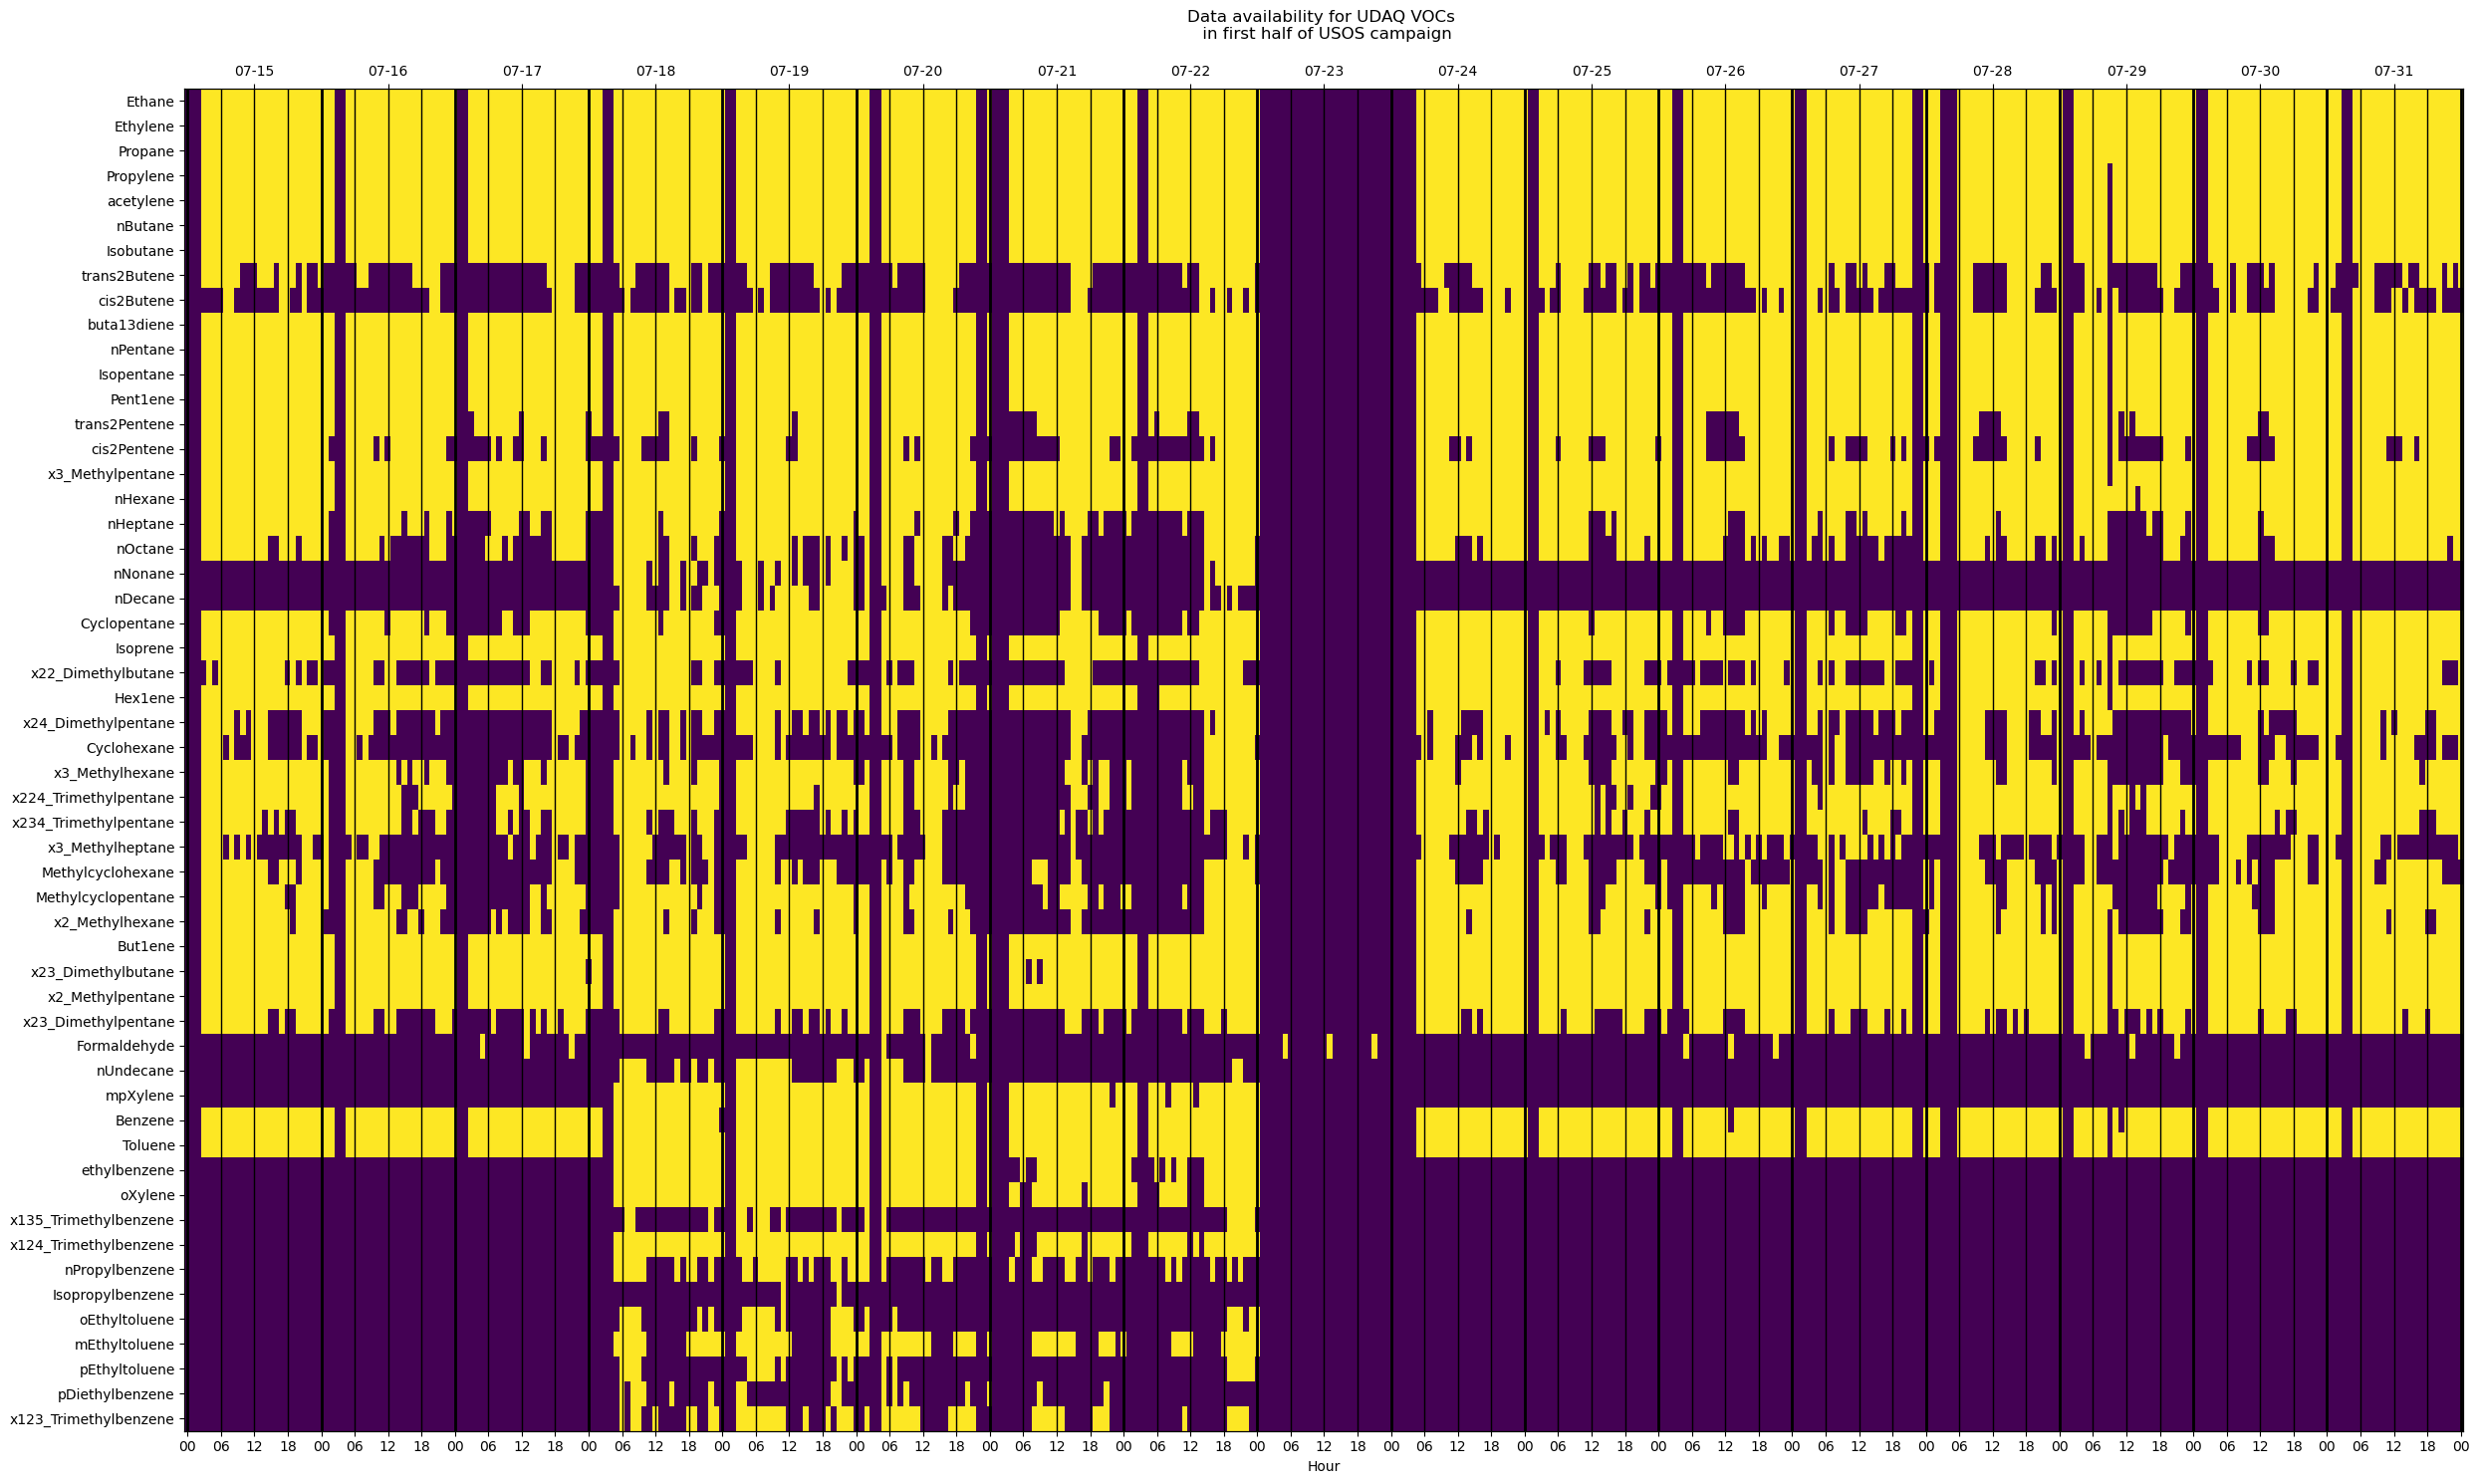

In [66]:
#alter viridis colormap to only have 2 color options
viridis = plt.cm.viridis
colors = [viridis(0.0), viridis(1.0)]
two_color_viridis = ListedColormap(colors)

# Create the heatmap using imshow
fig, ax = plt.subplots(figsize=(25, 15))
ax.imshow(first_17days_df_transposed, aspect='auto', cmap=two_color_viridis)
# Set x-ticks and y-ticks
ax.set_xticks(ticks=range(0,len(first_17days_df_transposed.columns),6), labels=first_17days_df_transposed.columns.strftime('%H')[0::6])
ax.set_yticks(ticks=np.arange(len(first_17days_df_transposed.index)), labels=first_17days_df_transposed.index)
ax.set_xlabel('Hour')

for pos in range(0,len(first_17days_df_transposed.columns),24):
    plt.axvline(pos, color = 'black', linewidth = 2)
for pos in range(0,len(first_17days_df_transposed.columns),6):
    plt.axvline(pos, color = 'black', linewidth = 1)
#    plt.axvline(df_allvars_transposed.columns.strftime('%H%M')[12::48], color = 'black')           

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
midnight_labels = []
for date in range(12,len(first_17days_df_transposed.columns),24):
    date_labels = first_17days_df_transposed.columns.strftime('%m-%d')[date]
    midnight_labels.append(date_labels)

ax_top.set_xticklabels(midnight_labels)
ax_top.set_xticks(ticks=range(12,len(first_17days_df_transposed.columns),24))

# Set labels and title
plt.ylabel('Measurement')
plt.title('Data availability for UDAQ VOCs \n in first half of USOS campaign\n')

# Show plot
plt.tight_layout()
plt.show()

#save_filepath_merger = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_merges/data_availability_plots/three_day_availability_'+ str(date_to_plot) + '.png'
#plt.savefig(fname = save_filepath_merger,format='png')
#print('Saved figure as:' + str(save_filepath_merger))

/tmp/ipykernel_3894320/682814994.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_top.set_xticklabels(midnight_labels)


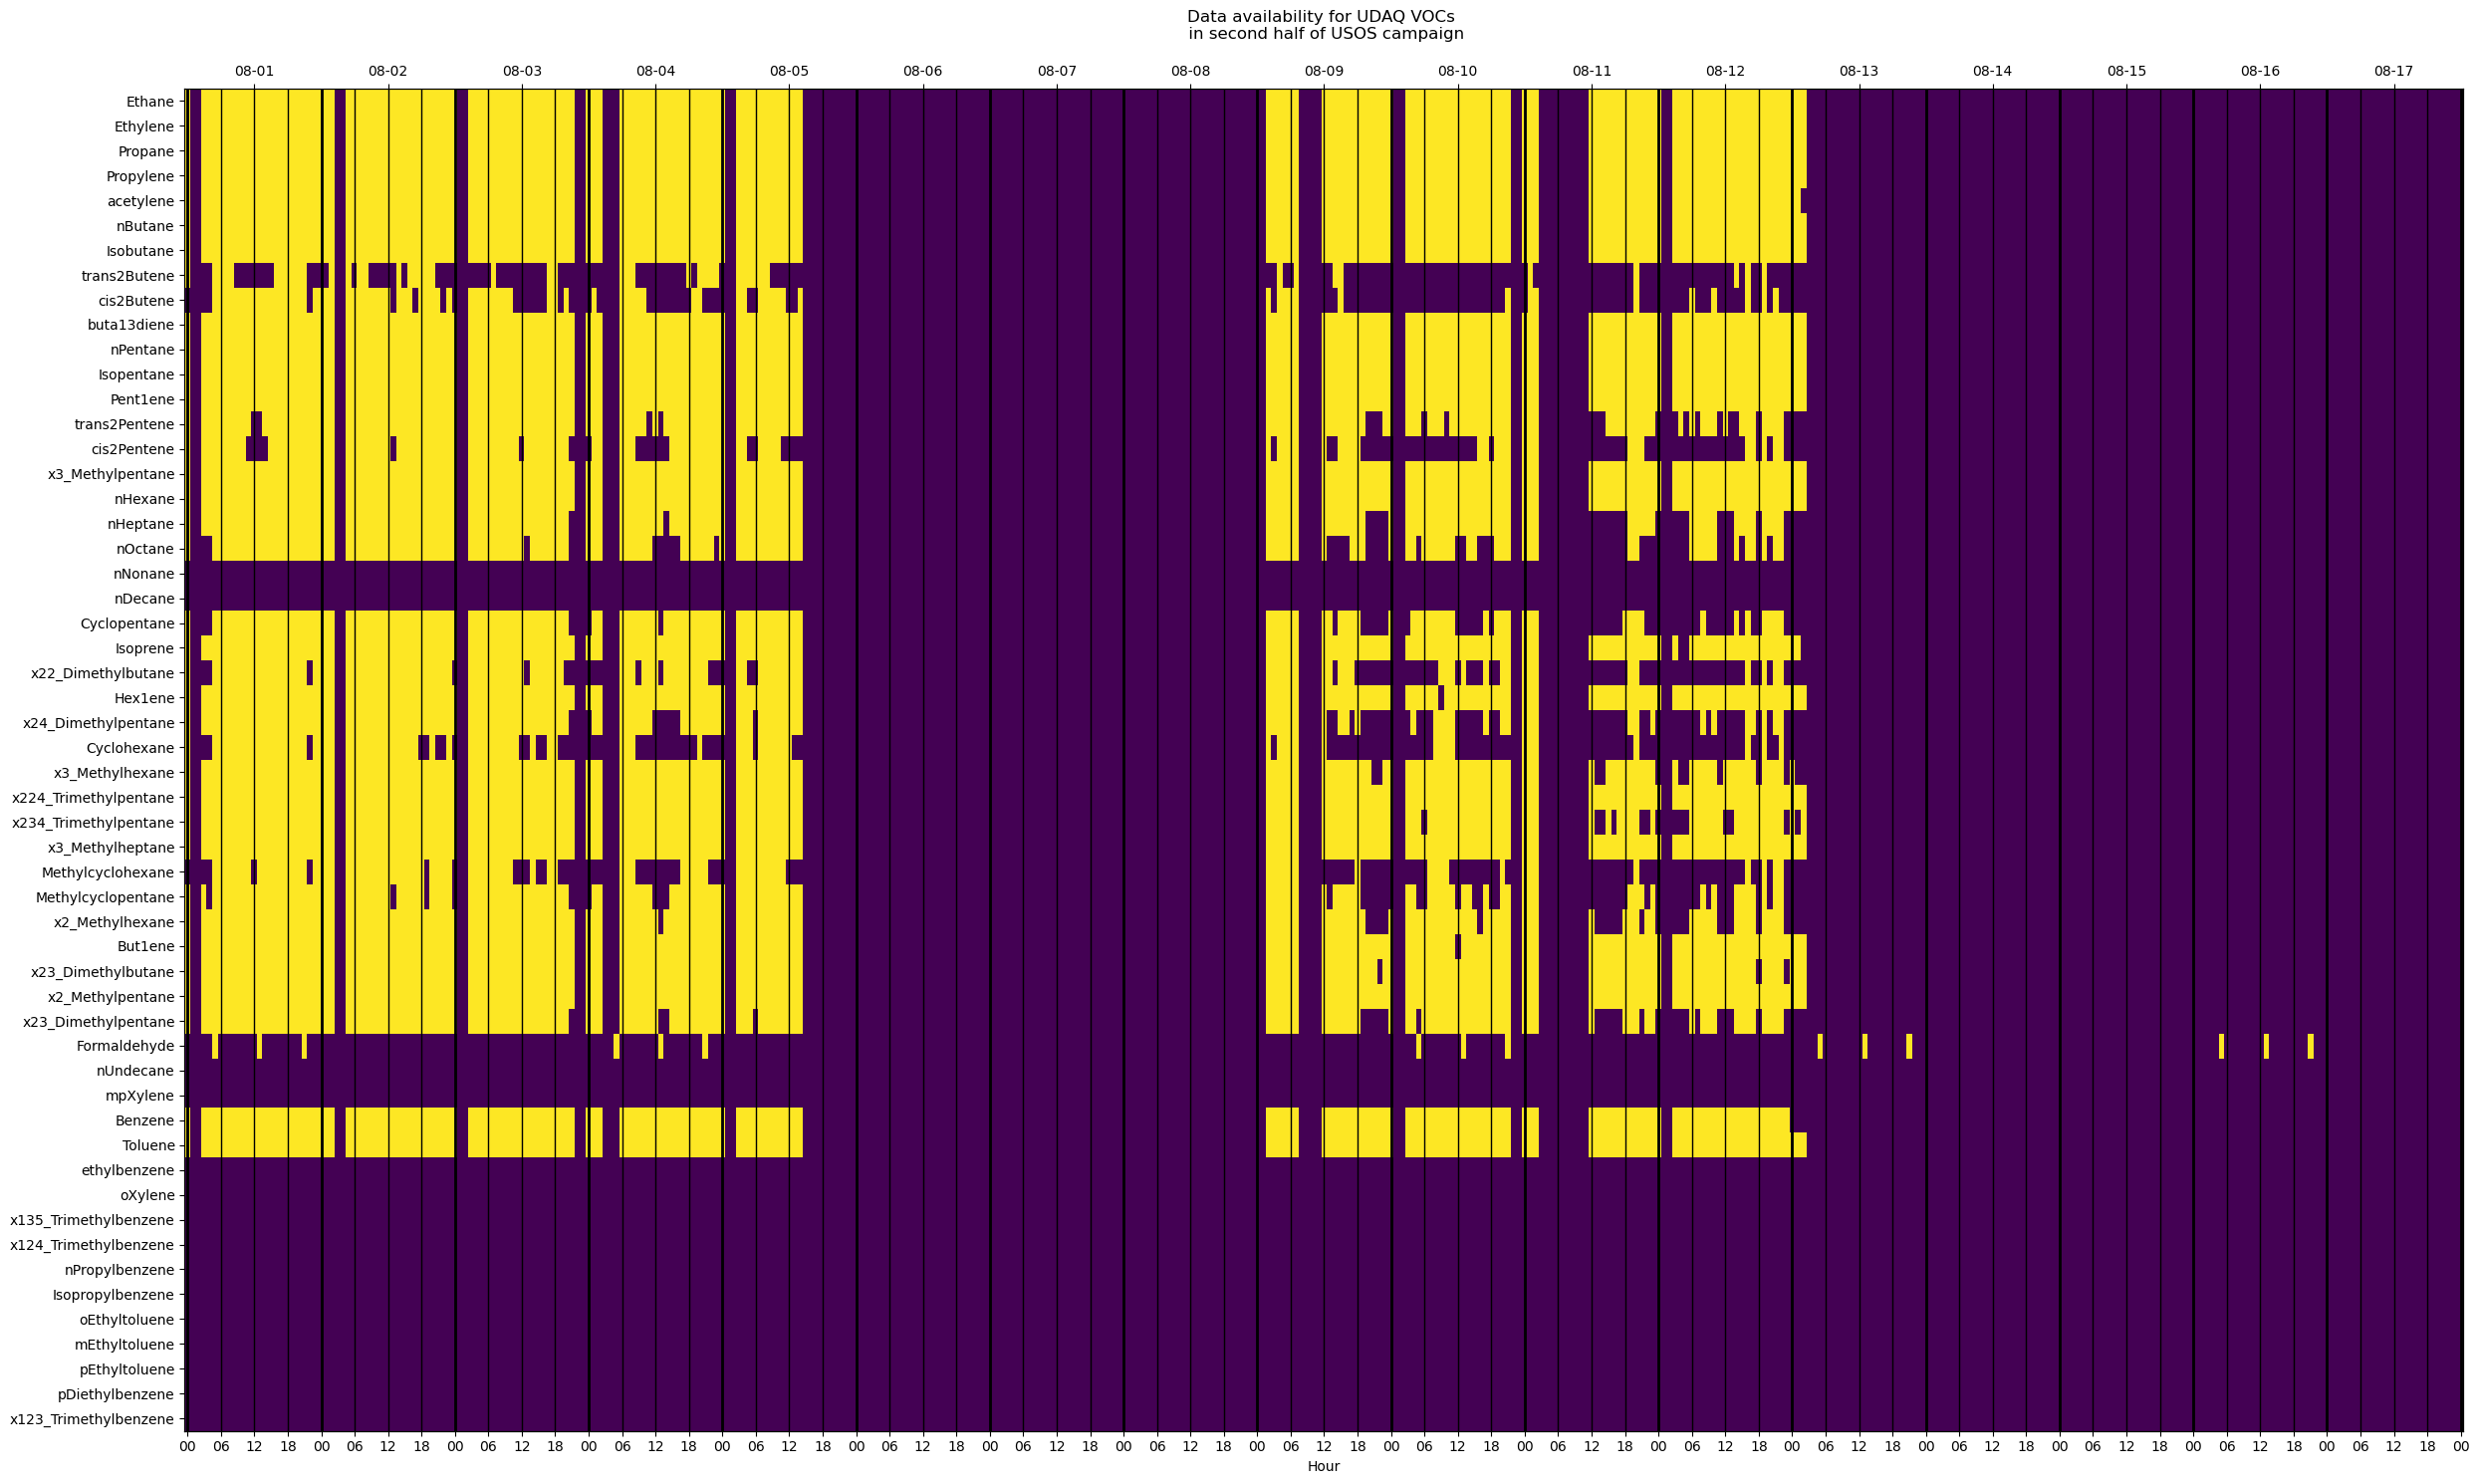

In [65]:
#alter viridis colormap to only have 2 color options
viridis = plt.cm.viridis
colors = [viridis(0.0), viridis(1.0)]
two_color_viridis = ListedColormap(colors)

# Create the heatmap using imshow
fig, ax = plt.subplots(figsize=(25, 15))
ax.imshow(second_17days_df_transposed, aspect='auto', cmap=two_color_viridis)
# Set x-ticks and y-ticks
ax.set_xticks(ticks=range(0,len(second_17days_df_transposed.columns),6), labels=second_17days_df_transposed.columns.strftime('%H')[0::6])
ax.set_yticks(ticks=np.arange(len(second_17days_df_transposed.index)), labels=second_17days_df_transposed.index)
ax.set_xlabel('Hour')

for pos in range(0,len(second_17days_df_transposed.columns),24):
    plt.axvline(pos, color = 'black', linewidth = 2)
for pos in range(0,len(second_17days_df_transposed.columns),6):
    plt.axvline(pos, color = 'black', linewidth = 1)
#    plt.axvline(df_allvars_transposed.columns.strftime('%H%M')[12::48], color = 'black')           

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
midnight_labels = []
for date in range(12,len(second_17days_df_transposed.columns),24):
    date_labels = second_17days_df_transposed.columns.strftime('%m-%d')[date]
    midnight_labels.append(date_labels)

ax_top.set_xticklabels(midnight_labels)
ax_top.set_xticks(ticks=range(12,len(second_17days_df_transposed.columns),24))

# Set labels and title
plt.ylabel('Measurement')
plt.title('Data availability for UDAQ VOCs \n in second half of USOS campaign\n')

# Show plot
plt.tight_layout()
plt.show()

#save_filepath_merger = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_merges/data_availability_plots/three_day_availability_'+ str(date_to_plot) + '.png'
#plt.savefig(fname = save_filepath_merger,format='png')
#print('Saved figure as:' + str(save_filepath_merger))

In [8]:
def dataframe_to_nested_dict(df):
    nested_dict = {}
    for column in df.columns:
        nested_dict[column] = df[column][0:-1].to_numpy()
        
    # Add the index as a key-value pair
    nested_dict['time_local'] = df.index[0:-1].to_numpy()
    return nested_dict

ddict=dataframe_to_nested_dict(df_interp)

    # Sort alphabetically so not annoying in MATLAB...  
ddict= OrderedDict(sorted(ddict.items())) 

# Save the USOS data in an output .mat file: 
outpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/F0AM-4.3.0.1/Campaign_Data/matlab_merge/udaq/original/'
matfilename = '20240719_20240721_1hr_udaq_vocs.mat'
savemat(outpath+matfilename,{'UDAQ': ddict})
print('Saved MATLAB file to:' + outpath + matfilename)

Saved MATLAB file to:/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/F0AM-4.3.0.1/Campaign_Data/matlab_merge/udaq/original/20240719_20240721_1hr_udaq_vocs.mat


In [10]:
#Read iWAS VOCs

all_days_filepath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/CampaignData_and_Merges/R0/CSL_MobileLab_Parked/merged/rev_1hr/all_CSL_MobileLab_Parked_rev1hr_iWASupdated.nc'
all_days_filepath_load = xr.open_dataset(all_days_filepath)
df_alldays = all_days_filepath_load.to_dataframe()
df_alldays.reset_index(inplace=True)
df_alldays.set_index('time_local', inplace=True, drop=False)

print(df_alldays.columns.values)

['time_UTC' 'O3_ppbv' 'File_Index' 'HONO_CIMS' 'PAN_CIMS' 'APAN_CIMS'
 'PPN_CIMS' 'HCOOH_CIMS' 'jNO2_meas' 'jBrCl' 'jBr2' 'jCCl4' 'jCH2Oa'
 'jCH2Ob' 'jClNO2' 'jClOa' 'jClOb' 'jCl2' 'jHNO2' 'jHNO3' 'jI2' 'jNO2'
 'jNO3a' 'jNO3b' 'jN2O5' 'jO3' 'AOD' 'Altitude_m' 'Course_deg' 'GndSpd_ms'
 'Heading_deg' 'Lat' 'Lon' 'Temp_K' 'RH_percent' 'Pressure_mb'
 'WindDir_deg' 'WindSpd_ms' 'CO2_Piccaro' 'CH4_Piccaro' 'CO_Piccaro'
 'H2O_Piccaro' 'Br2_CIMS' 'BrO_CIMS' 'Cl2_CIMS' 'ClNO2_CIMS' 'BrCl_CIMS'
 'NCl3_CIMS' 'N2O5_CIMS' 'NO_LIF' 'NO2_LIF' 'NOy_LIF' 'Methanol_PTR'
 'Acetonitrile_PTR' 'Acetaldehyde_PTR' 'Ethanol_PTR' 'Methanethiol_PTR'
 'Acrolein_PTR' 'Acetone_Propanal_PTR' 'DMS_PTR' 'Isoprene_PTR'
 'MVK_MACR_PTR' 'Benzene_PTR' 'Toluene_PTR' 'Styrene_PTR'
 'Benzaldehyde_PTR' 'C8Aromatics_PTR' 'C9Aromatics_PTR' 'Naphthalene_PTR'
 'Octanal_PTR' 'Monoterpenes_PTR' 'Nonanal_PTR' 'C7H4ClF3_PTR'
 'D5_siloxane_PTR' 'Acetone_WAS' 'Acrolein_WAS' 'Benzene_WAS' 'C2Cl4_WAS'
 'C2HCl3_WAS' 'CCl4_WAS' 'CF2Cl2_WAS

In [25]:
# Filter columns whose names contain '_WAS'
was_cols = df_alldays.filter(regex=r"_WAS")
print(was_cols)

                     Acetone_WAS  Acrolein_WAS  Benzene_WAS  C2Cl4_WAS  \
time_local                                                               
2024-07-14 18:00:00          NaN           NaN          NaN        NaN   
2024-07-14 19:00:00          NaN           NaN          NaN        NaN   
2024-07-14 20:00:00          NaN           NaN          NaN        NaN   
2024-07-14 21:00:00          NaN           NaN          NaN        NaN   
2024-07-14 22:00:00          NaN           NaN          NaN        NaN   
...                          ...           ...          ...        ...   
2024-08-18 13:00:00          NaN           NaN          NaN        NaN   
2024-08-18 14:00:00         1.76         0.108        0.039      0.004   
2024-08-18 15:00:00          NaN           NaN          NaN        NaN   
2024-08-18 16:00:00          NaN           NaN          NaN        NaN   
2024-08-18 17:00:00          NaN           NaN          NaN        NaN   

                     C2HCl3_WAS  CCl4